<div style="background: linear-gradient(135deg, #e9f2fb 0%, #f7fbff 100%); padding: 18px 20px; border: 1px solid #d5e3f0; border-radius: 10px; text-align: center;">
  <div style="font-size: 32px; font-weight: 700; color: #1f3b57; letter-spacing: 0.2px;">NX-414 Brain-like Computation and Intelligence</div>
</div>


<div style="text-align: center; font-size: 21px; font-weight: 600; color: #36536b; margin-top: 6px;">Project Notebook — Spring 2026</div>


<div style="text-align: center; color: #4f6478; font-size: 16px; margin-bottom: 10px;">Brain–Model Alignment Across Neural Recording Modalities</div>
<div style="text-align: center; color: #6b7280; font-size: 13px;">Prepared by: Abdulkadir Gokce</div>

---


# Group Information

Fill in this section at the top of your notebook and report.

- **Group member 1:** Majandra Garcia, 347470, majandra.garcia@epfl.ch  
- **Group member 2:** Clara Delandre, 340954, clara.delandre@epfl.ch  
- **Group member 3:** Louis Tschanz, 315774, louis.tschanz@eplf.ch  

---

# What You Must Submit

Submit the following files:

1. **One Jupyter notebook** containing your full analysis.
2. **Any supporting Python scripts** needed to run the notebook.
3. **Figures that are part of your notebook answers** should be embedded and rendered in notebook Markdown.
4. **One PDF report** of **up to 2 pages**, **excluding references**, with **no appendix**.
5. **One zip archive** named exactly as:

```text
nx414_{SCIPER1}_{SCIPER2}_{SCIPER3}.zip
```

If your group has fewer than three members, reduce the number of `_SCIPER` fields accordingly.

## Submission Rules

- **Clear all notebook outputs before submission.**
- If outputs are not cleared, we will clear them ourselves and grade the cleaned notebook.
- Submit only the code required to reproduce your results.
- **Do not submit model weights.**
- **Do not submit CSV files or other large derived result dumps.**
- Keep the archive lightweight and reproducible.
- For the **final notebook**, any figure you want to present as part of your scientific argument should be **embedded in Markdown with accompanying interpretation**, rather than left as a raw cell output with no explanation.

Failure to follow these instructions may reduce your final grade.

## Use of LLMs

You may use LLM-based tools to help you write code, debug, or improve explanations. However, you remain fully responsible for the **correctness**, **quality**, and **clarity** of everything you submit, including both the notebook and the report.

In particular:

- check that any generated code actually runs and does what you claim it does,
- verify that any scientific statement or interpretation is correct,
- make sure the final writing sounds like a clear academic report written for this course,
- avoid vague, overly polished, or context-free text,
- avoid fancy wording or unnecessarily complex sentences that do not add clarity.

If you use an LLM, revise the output so that your submission reads naturally, is specific to your actual results, and does not look like generic generated text.

Failure to do so may result in **a point deduction**.

## Expected scope

Because this project spans roughly **three weeks** and counts for **30% of the final course grade**, the expected output is closer to a **compact course project** than to a one-week homework notebook. Your submission should therefore read like a small empirical study: it should be clearly structured, contain short written interpretations throughout, compare alternatives systematically, and end with a coherent synthesis of your main findings.

A strong notebook will not only run end-to-end, but will also explain **why** each analysis is being performed, what each metric is meant to capture, and what the results imply about the strengths and limitations of the models and datasets.

At the same time, **some parts of the project are intentionally left a bit loose**. This is by design: beyond implementing the required core analyses, you are expected to make reasonable scientific choices, justify them clearly, and show some ingenuity in how you explore the data and compare models.

## Suggested 3-week pacing

Use the notebook structure below to organize your work over the three weeks.

- **Week 1:** complete **Section 0** and **Section 1**. Understand the datasets, verify stimulus matching, inspect the processed responses, and start the visualization and reliability analyses.
- **Week 2:** complete the required analyses in **Section 2**. In this section, you must complete both the representational and predictive parts of the project. Begin **Section 3** by brainstorming possible extensions and sketching out a plan for your chosen extension.
- **Week 3:** complete **Section 3**, polish the notebook, select the strongest figures, and write the 2-page report.


---

# 0. Introduction and Setup

## 0.1 Project goal

In this project, you will study how neural responses from different recording modalities align with features extracted from two vision models. More specifically, you will work in the standard **brain–model alignment** setting: a model processes an image, a candidate internal layer is selected, and that representation is compared to measured neural responses using representational and predictive metrics.

The notebook is organized around four sections:

- **Section 0:** introduction, setup, and understanding the provided resources.
- **Section 1:** dataset inspection, visualization, and noise ceiling estimation.
- **Section 2:** brain–model alignment through both representational metrics and predictive linear models.
- **Section 3:** an open-ended extension beyond the baseline pipeline.

## 0.2 Why task-optimized models?

Task-optimized neural networks are among the most useful current **in-silico models of sensory cortex**. The central idea is simple: instead of hand-designing a model to mimic every biological detail, we optimize a model to perform a meaningful visual task and then ask whether its internal representations resemble those found in the brain. This approach has been highly influential because models trained to solve vision tasks often develop representations that predict activity along the visual hierarchy surprisingly well.

These models are useful scientifically because they provide **testable computational hypotheses**. If a model layer predicts neural responses well, that does not mean the brain literally implements the same mechanism, but it does suggest that the layer may encode information in a similar format or at a similar level of abstraction. Brain–model alignment is therefore a way to ask not just whether a model is accurate on a task, but whether it organizes visual information in a brain-relevant way.

## 0.3 Why compare multiple modalities?

A single recording modality gives only a partial view of neural computation. In this project, you will work with **electrophysiology, EEG, and fMRI**, which differ in temporal resolution, spatial resolution, and what exactly is measured. Looking across modalities helps you see which conclusions are robust and which depend on the measurement scale.

## 0.4 Learning goals

By the end of this project, you should be able to:

- inspect and summarize neural datasets from multiple modalities,
- visualize neural signals and data quality,
- implement and compare **two noise ceiling estimators**,
- implement **RSA** and **unbiased linear CKA**,
- fit **linear encoding models** from model features to neural responses,
- compare alignment across **models, layers, ROIs, and metrics**,
- interpret what each alignment metric captures,
- design and evaluate one meaningful extension beyond the baseline pipeline.

A strong submission should therefore demonstrate both **technical correctness** and **scientific reasoning**: beyond obtaining scores, you should be able to explain why a dataset is noisy, why one layer may outperform another, and why representational and predictive metrics sometimes disagree.

## 0.5 Provided data

All main data are stored in `/shared/NX-414/data/`.

### Background: processed data derivatives

The files provided for this project are **not raw neural recordings**. They are already processed, analysis-ready derivatives produced with modality-appropriate pipelines. This is important scientifically: many of your results will depend not only on the model features, but also on preprocessing choices such as repetition averaging, denoising, response-window selection, voxel/channel filtering, and how reliability is estimated.

We performed the preprocessing for you because these pipelines often require substantial modality-specific expertise, time, and compute.

At a high level, the datasets used here were prepared as follows:

- **TVSD (macaque electrophysiology)** — normalized multi-unit responses from ventral-stream areas. Responses were z-scored within session, firing rates were averaged in an analysis window centered on each site’s response peak, low-reliability channels were excluded, and repeated test responses were averaged for evaluation.
- **THINGS-EEG2 (human EEG)** — source EEG responses resampled to **100 Hz**. Noise ceilings were computed per subject, channel, and time point, and repetitions were averaged within train and test splits.
- **NSD (human fMRI)** — **b3 single-trial beta estimates** in `func1pt8mm` space, derived using voxel-wise HRF fitting, GLMdenoise, and ridge regression. Analyses are restricted to ROI-defined visually responsive voxels, low-reliability voxels are filtered out, and responses are averaged across available repetitions.

You are **not** expected to re-run the full preprocessing pipelines. You **are** expected to understand what kinds of neural quantities you are analyzing, what has already been averaged or denoised, and how these choices affect interpretation.

### Main neural datasets

- **`tvsd.h5`** — macaque electrophysiology from **2 monkeys**, with **22,248 train** and **100 test** stimuli, covering **V1, V4, and IT**.
- **`things_eeg2.h5`** — human EEG from **10 subjects**, with **16,540 train** and **200 test** stimuli, with region groupings such as **occipital**, **parietal**, **temporal**, **frontal**, **central**, **occipital_parietal**, and **whole_brain**.
- **`nsd_func1pt8mm_individualROIs.h5`** — human fMRI from **8 subjects**, with roughly **9,000 train** and **1,000 test** stimuli per subject, across multiple visual ROIs.

### Additional files

- `things_eeg2-test_reps.h5`  
  EEG test responses **with repetitions and without averaging**.  
  Use this file to implement and compare **two noise ceiling estimators**.

- `nsd-subj01-ncsnr-{lh,rh}.mgh`  
  Surface-based NSD reliability values for `subj-01` on **fsaverage**.  
  Use these to visualize cortical reliability and convert **ncsnr** into **noise ceiling**.

### Neural response shapes

- **TVSD:** `(n_stimuli, n_units)`
- **EEG2:** `(n_stimuli, n_channels, n_timepoints)`
- **NSD:** `(n_stimuli, n_voxels)`

For EEG, the time axis contains **80 time points** sampled at **100 Hz**, covering **0.0 s to 0.8 s**.

### Noise ceilings

Noise ceilings are stored per target:

- per neuron for **TVSD**,
- per channel × time point for **EEG2**,
- per voxel for **NSD**.

They are stored as **percent reliability**.  
To convert them to the range `[0, 1]`, divide by `100`.

In this project, the provided noise ceilings are mainly intended for **predictive metrics** such as **Pearson correlation** and **explained variance**. They reflect the reliability of the neural responses and therefore define an upper bound on how well any model can predict those responses.

When you compute predictive metrics, you should apply a noise ceiling correction to account for this upper bound. The standard idea is simple: divide the raw predictive score by the corresponding noise ceiling value for that target.

The provided noise ceilings are defined for **explained variance**. If you want to apply the same logic to **Pearson correlation**, first convert the explained-variance ceiling into a correlation ceiling by taking the element-wise square root, and then divide the raw correlation by that quantity. For a more detailed discussion of noise ceiling correction, see van Bree et al. (2025).

You may therefore report both **raw** and **noise-ceiling-corrected** predictive scores where appropriate.


For example, if the provided ceiling is an explained-variance reliability estimate, you can compute a noise-corrected Pearson correlation as:

```python
r_nc = r / np.sqrt(ev_ceiling)
```

where `r` is the raw Pearson correlation and `ev_ceiling` is the explained-variance ceiling expressed on the range `[0, 1]`.

By contrast, **RSA** and **CKA** should typically be reported as **raw values** in this project. Noise ceilings for representational similarity metrics require a different methodology and are **not** provided here.


Do **not** apply this correction directly to **RSA** or **CKA**.

### Stimulus identifiers

- **TVSD / EEG2:** byte strings such as `b'aardvark/aardvark_01b.jpg'`
- **NSD:** integer stimulus IDs

## 0.6 Model features

All extracted features are stored in `/shared/NX-414/extracted_features/`.

The feature files contain **internal activations extracted from multiple candidate layers** while the models process the same images shown in the neural experiments. You can think of each layer as a representation matrix of shape roughly **stimuli × features**. These layer-wise representations are what you will compare to the brain using RSA, CKA, and encoding models.

Feature extractions across models were made tractable by projecting activations to **30,000 dimensions** using a random projection. The provided feature files follow that same idea. In practice, this means you can treat the feature vectors as compact surrogates for the original activations while still performing meaningful alignment analyses.

### Model A: `adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0`

- Architecture: **ResNet-152**
- Pretraining: ImageNet + adversarial fine-tuning
- Available feature files:
  - `things_stimuli.h5`
  - `nsd_stimuli.h5`

### Model B: `Qwen3-VL-2B-Instruct`

- Architecture: **vision-language transformer**
- Available feature files:
  - `things_stimuli.h5`
  - `nsd_stimuli.h5`

For both models, layers have been projected to **30,000 dimensions** using random projections.

### Feature extraction note

For this project, feature extraction has already been done for you. Your job is therefore not to run the vision models on raw images, but to understand **which layer** to use, how to match feature rows to neural stimuli, and what different layers reveal about representational hierarchy.

### Important note for NSD

For NSD, the feature files contain features for **all 73,000 images**, but each subject saw only a subset (~9,000).  
You must therefore select feature rows using the subject-specific NSD stimulus IDs.

## 0.7 Matching features to neural responses

You must match neural responses and features through the stimulus IDs.

### THINGS-based datasets: TVSD and EEG2

For these datasets, both neural IDs and feature IDs are byte strings. Matching should therefore be exact.

### NSD

For NSD, both sides use integer IDs. The feature file contains all 73,000 stimuli, while each subject has only a subset. Use the subject-specific NSD stimulus IDs to select the corresponding feature rows.

### Recommended procedure

```python
feat_ids = feature_file['ids'][:]
id_to_feat_idx = {id_: i for i, id_ in enumerate(feat_ids)}
feat_idx = np.array([id_to_feat_idx[x] for x in neural_ids])
```

To make HDF5 reads efficient:

1. build the index array,
2. sort indices before reading,
3. load only the required rows,
4. restore the original order.

## 0.8 General analysis rules

### Train/test discipline

Do **not** use the test split for model selection or hyperparameter tuning. Use a validation split or cross-validation within the training data.

### EEG targets

For EEG, you may either:

- flatten the targets to `(n_stimuli, n_channels * n_timepoints)`, or
- fit separate models per channel × time point.

Either choice is acceptable, but you must explain your decision clearly.

### Predictive metrics

Report the following predictive metrics where appropriate:

- `pearsonr`
- `pearsonr_nc`
- `explained_variance`
- `explained_variance_nc`

The provided EEG signals are not filtered like the other datasets. As a result, some low-reliability channels or time points can produce unstable predictive scores. When averaging predictive metrics over EEG targets, apply an on-the-fly filter such as **noise ceiling < 0.1**.

### Representational metrics

Also report:

- `RSA`
- `CKA`
- `encoding-RSA`
- `encoding-CKA`

Encoding RSA/CKA is a hybrid metric where you compute RSA or CKA between the predicted neural responses (from the linear encoding model) and the actual neural responses, instead of just comparing model activation directly. This can help you understand whether the linear encoding model captures the representational geometry of the neural data, beyond just predicting individual response values. You can refer to Conwell et al. (2024) for more details on this approach. 

Use only the test split for computing representational metrics.

Do **not** noise-correct RSA or CKA using the predictive-metric procedure.

## 0.9 Setup and data loading

Your notebook should begin with a short introduction, clear imports, utility functions, and a brief verification that the provided files are correctly organized and matched.

**Section 0 is required but not graded separately.** It is treated as setup for the rest of the project. Missing or incorrect setup may reduce scores in later sections if it affects correctness or reproducibility.

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Import the required packages.
- Define utility functions.
- Load metadata for all datasets.
- Inspect the structure of each `.h5` file.
- Load feature metadata for both models.
- Verify that feature IDs and neural stimulus IDs match.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **Dataset and feature overview:** one compact table or printed summary covering all neural datasets and both feature sets.
2. **Stimulus-matching verification:** explicit checks or assertions showing that stimulus matching works for THINGS-based datasets and for NSD.
3. **Short structural summary:** a short written note describing the main structural differences across datasets.

<div style="background:#eef8f4; border-left:4px solid #5b9a7a; padding:8px 12px; border-radius:6px; font-weight:700; color:#285943;">Questions you should answer</div>

- How many stimuli are available in each dataset?
- What is the shape of the neural response tensor in each dataset?
- Which datasets contain subjects, ROIs, repetitions, channels, or time points?
- What are the feature dimensionalities across layers?

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 0</strong><br>Summarize the structure of the three datasets and the two feature sets in 4–6 sentences. Clearly state which dataset is most complex structurally and why.</div>

In [3]:
# TODO: imports
# TODO: define paths
# TODO: inspect dataset structure
# TODO: verify stimulus matching

#### 0.9.1 Imports and paths

First, let's import the packages and the data.

In [1]:
# TODO: imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn import metrics
from scipy import stats
import nibabel as nib
from nilearn import plotting as nlplt
import h5py
import torch
from scipy.spatial import cKDTree
from nilearn import datasets, plotting, surface

In [2]:
# TODO: define paths
from pathlib import Path

data_dir = Path("/shared/NX-414/data")
features_dir = Path("/shared/NX-414/extracted_features")

for p in sorted(data_dir.rglob("*")):
    print(p)

# Neural data files
tvsd_path = data_dir / "tvsd.h5"
eeg2_path = data_dir / "things_eeg2.h5"
eeg2_reps_path = data_dir / "things_eeg2-test_reps.h5"
nsd_path = data_dir / "nsd_func1pt8mm_individualROIs.h5"

# Extra NSD reliability maps
nsd_ncsnr_lh_path = data_dir / "nsd-subj01-ncsnr-lh.mgh"
nsd_ncsnr_rh_path = data_dir / "nsd-subj01-ncsnr-rh.mgh"

# Figure export directories
fig_dir_section1 = Path("figures/section1")
fig_dir_section2 = Path("figures/section2")
fig_dir_section3 = Path("figures/section3")

for fig_dir in [fig_dir_section1, fig_dir_section2, fig_dir_section3]:
    fig_dir.mkdir(parents=True, exist_ok=True)

/shared/NX-414/data/nsd-subj01-ncsnr-lh.mgh
/shared/NX-414/data/nsd-subj01-ncsnr-rh.mgh
/shared/NX-414/data/nsd_func1pt8mm_individualROIs.h5
/shared/NX-414/data/things_eeg2-test_reps.h5
/shared/NX-414/data/things_eeg2.h5
/shared/NX-414/data/tvsd.h5


In [3]:
# Model feature files
model_specs = {
    "adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0": {
        "things": features_dir / "adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0" / "things_stimuli.h5",
        "nsd": features_dir / "adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0" / "nsd_stimuli.h5",
    },
    "Qwen3-VL-2B-Instruct": {
        "things": features_dir / "Qwen3-VL-2B-Instruct" / "things_stimuli.h5",
        "nsd": features_dir / "Qwen3-VL-2B-Instruct" / "nsd_stimuli.h5",
    },
}

#### 0.9.2 Utility functions
We can now define some utility functions, to load the datasets and create precise outputs. 

In [4]:
# UTILITY FUNCTIONS
def h5_leaf_datasets(h5file):
    rows = []
    def walk(name, obj):
        if isinstance(obj, h5py.Dataset):
            rows.append({
                "name": name,
                "shape": tuple(obj.shape),
                "dtype": str(obj.dtype),
                "ndim": obj.ndim,
            })
    h5file.visititems(walk)
    return pd.DataFrame(rows).sort_values("name").reset_index(drop=True)

def decode_if_bytes(x):
    if isinstance(x, (bytes, np.bytes_)):
        return x.decode("utf-8")
    return x

def collapse_subject(name):
    for k in [f"sub-{i:02d}" for i in range(1, 11)] + [f"subj{i:02d}" for i in range(1, 9)]:
        name = name.replace(k, "sub-XX").replace(k.replace("subj", "subj"), "subjXX")
    return name

def find_feature_layer_datasets(h5file, n_ids):
    """
    Returns datasets that look like layer features:
    - not 'ids'
    - 2D
    - first dimension matches number of stimulus IDs
    """
    rows = []
    def walk(name, obj):
        if isinstance(obj, h5py.Dataset):
            if name == "ids":
                return
            if obj.ndim == 2 and obj.shape[0] == n_ids:
                rows.append({
                    "layer_name": name,
                    "shape": tuple(obj.shape),
                    "feature_dim": int(obj.shape[1]),
                })
    h5file.visititems(walk)
    return pd.DataFrame(rows).sort_values("layer_name").reset_index(drop=True)

def summarize_feature_file(path, model_name, stimulus_set):
    with h5py.File(path, "r") as f:
        ids = f["ids"][:]
        n_ids = len(ids)
        layer_table = find_feature_layer_datasets(f, n_ids)
        if len(layer_table) == 0:
            raise ValueError(f"No layer datasets found in {path}")
        return {
            "model": model_name,
            "stimulus_set": stimulus_set,
            "n_stimuli": n_ids,
            "n_layers": len(layer_table),
            "feature_dims": sorted(layer_table["feature_dim"].unique().tolist()),
            "first_layers": layer_table["layer_name"].head(5).tolist(),
            "layer_table": layer_table,
            "ids": ids,
        }

def get_nsd_subject_summary(nsd_h5):
    rows = []
    for subj in nsd_h5["train/stimulus_ids"].keys():
        train_ids = nsd_h5[f"train/stimulus_ids/{subj}"][:]
        test_ids = nsd_h5[f"test/stimulus_ids/{subj}"][:]
        rows.append({
            "subject": subj,
            "n_train_stimuli": len(train_ids),
            "n_test_stimuli": len(test_ids),
        })
    return pd.DataFrame(rows).sort_values("subject").reset_index(drop=True)

def assert_all_in(feature_ids, neural_ids, label):
    feat_set = set(feature_ids.tolist())
    missing = [x for x in neural_ids if x not in feat_set]
    assert len(missing) == 0, f"{label}: missing {len(missing)} stimulus IDs in feature file"
    print(f"[OK] {label}: {len(neural_ids)} / {len(neural_ids)} stimulus IDs matched")

#### 0.9.3 Load and inspect metadata for all datasets

In [5]:
# Open files
tvsd_h5 = h5py.File(tvsd_path, "r")
eeg2_h5 = h5py.File(eeg2_path, "r")
eeg2_test_reps_h5 = h5py.File(eeg2_reps_path, "r")
nsd_rois_h5 = h5py.File(nsd_path, "r")

nsd_ncsnr_lh = nib.load(str(nsd_ncsnr_lh_path))
nsd_ncsnr_rh = nib.load(str(nsd_ncsnr_rh_path))

print("Neural files loaded successfully.")

Neural files loaded successfully.


```
Neural files loaded successfully.
```

Now, let's inspect the structure of the different datasets.

In [9]:
# TODO: inspect dataset structure
# Inspect .h5 structure
tvsd_struct = h5_leaf_datasets(tvsd_h5)
eeg2_struct = h5_leaf_datasets(eeg2_h5)
eeg2_reps_struct = h5_leaf_datasets(eeg2_test_reps_h5)
nsd_struct = h5_leaf_datasets(nsd_rois_h5)

print("TVSD:", list(tvsd_h5.keys()))
print("EEG2:", list(eeg2_h5.keys()))
print("EEG2_test_reps:", list(eeg2_test_reps_h5.keys()))
print("NSD:", list(nsd_rois_h5.keys()))

TVSD: ['noise_ceilings', 'test', 'train']
EEG2: ['noise_ceilings', 'noise_ceilings_train', 'test', 'train']
EEG2_test_reps: ['test']
NSD: ['noise_ceiling_full', 'noise_ceilings', 'roi_labels', 'roi_labels_nc', 'test', 'train']


```
TVSD: ['noise_ceilings', 'test', 'train']
EEG2: ['noise_ceilings', 'noise_ceilings_train', 'test', 'train']
EEG2_test_reps: ['test']
NSD: ['noise_ceiling_full', 'noise_ceilings', 'roi_labels', 'roi_labels_nc', 'test', 'train']
```

The printed keys show the main groups available in each dataset file.

TVSD contains training and test responses, as well as stored noise ceilings. EEG2 has a similar structure, but also includes training noise ceilings and a separate file containing repeated test responses, which is needed for estimating reliability. NSD contains train/test fMRI responses, noise-ceiling information, and ROI labels used for voxel-wise and parcel-wise analyses.

We can continue by creating the compact overview of the datasets, using the explanations provided in the introduction:

In [10]:
# Create a compact overview of the datasets
neural_overview = pd.DataFrame([
    {
        "dataset": "TVSD",
        "stimulus_space": "THINGS",
        "train_stimuli": len(tvsd_h5["train/stimulus_ids"][:]),
        "test_stimuli": len(tvsd_h5["test/stimulus_ids"][:]),
        "example_response_shape": tuple(tvsd_h5["train/neural_data/monkeyF/V1"].shape),
        "main_axes": "stimuli × units",
        "subjects": "2 monkeys",
        "targets": "V1, V4, IT",
        "channels_or_voxels": "units",
        "time_points": "no",
        "repetitions": "no explicit repetition axis",
    },
    {
        "dataset": "EEG2",
        "stimulus_space": "THINGS",
        "train_stimuli": len(eeg2_h5["train/stimulus_ids"][:]),
        "test_stimuli": len(eeg2_h5["test/stimulus_ids"][:]),
        "example_response_shape": tuple(eeg2_h5["train/neural_data/sub-01/whole_brain"].shape),
        "main_axes": "stimuli × channels × time",
        "subjects": f"{len(eeg2_h5['train/neural_data'].keys())} humans",
        "targets": "central, frontal, occipital, occipital_parietal, parietal, temporal, whole_brain",
        "channels_or_voxels": "EEG channels",
        "time_points": "80",
        "repetitions": "test repetitions available in separate file",
    },
    {
        "dataset": "NSD",
        "stimulus_space": "NSD",
        "train_stimuli": "subject-specific",
        "test_stimuli": "subject-specific",
        "example_response_shape": tuple(nsd_rois_h5["train/neural_data/subj01/early"].shape),
        "main_axes": "stimuli × voxels",
        "subjects": f"{len(nsd_rois_h5['train/neural_data'].keys())} humans",
        "targets": "many ROIs + voxelwise maps",
        "channels_or_voxels": "voxels",
        "time_points": "no",
        "repetitions": "no explicit repetition axis",
    },
])

display(neural_overview)

# Subject-specific NSD counts
nsd_subject_counts = get_nsd_subject_summary(nsd_rois_h5)

print("NSD subject counts:")
display(nsd_subject_counts)

,dataset,stimulus_space,train_stimuli,test_stimuli,example_response_shape,main_axes,subjects,targets,channels_or_voxels,time_points,repetitions
0,TVSD,THINGS,22248,100,"(22248, 462)",stimuli × units,2 monkeys,"V1, V4, IT",units,no,no explicit repetition axis
1,EEG2,THINGS,16540,200,"(16540, 63, 80)",stimuli × channels × time,10 humans,"central, frontal, occipital, occipital_parieta...",EEG channels,80,test repetitions available in separate file
2,NSD,NSD,subject-specific,subject-specific,"(9000, 3952)",stimuli × voxels,8 humans,many ROIs + voxelwise maps,voxels,no,no explicit repetition axis


NSD subject counts:


,subject,n_train_stimuli,n_test_stimuli
0,subj01,9000,1000
1,subj02,9000,1000
2,subj03,8481,930
3,subj04,8302,907
4,subj05,9000,1000
5,subj06,8481,930
6,subj07,9000,1000
7,subj08,8302,907


| dataset | stimulus_space | train_stimuli | test_stimuli | example_response_shape | main_axes | subjects | targets | channels_or_voxels | time_points | repetitions |
|---|---|---:|---:|---|---|---|---|---|---|---|
| TVSD | THINGS | 22248 | 100 | (22248, 462) | stimuli × units | 2 monkeys | V1, V4, IT | units | no | no explicit repetition axis |
| EEG2 | THINGS | 16540 | 200 | (16540, 63, 80) | stimuli × channels × time | 10 humans | central, frontal, occipital, occipital_parietal, parietal, temporal | EEG channels | 80 | test repetitions available in separate file |
| NSD | NSD | subject-specific | subject-specific | (9000, 3952) | stimuli × voxels | 8 humans | many ROIs + voxelwise maps | voxels | no | no explicit repetition axis |

```
NSD subject counts:
```

| subject | n_train_stimuli | n_test_stimuli |
|---|---:|---:|
| subj01 | 9000 | 1000 |
| subj02 | 9000 | 1000 |
| subj03 | 8481 | 930 |
| subj04 | 8302 | 907 |
| subj05 | 9000 | 1000 |
| subj06 | 8481 | 930 |
| subj07 | 9000 | 1000 |
| subj08 | 8302 | 907 |

The project uses three datasets with different response spaces and data structures. The table summarizes the main dimensions used in the notebook.

For NSD, the number of train and test stimuli depends on the subject.

These differences matter because the encoding models must be trained and evaluated separately for each dataset, and for NSD the stimulus split is subject-specific.

#### 0.9.4 Load and inspect feature metadata for both models
Let's continue by looking at the feature metadata of each model.

In [7]:
# Load feature metadata
# Create a compact overview of the features
feature_summaries = []
feature_tables = {}

for model_name, paths in model_specs.items():
    for stim_set, path in paths.items():
        summary = summarize_feature_file(path, model_name, stim_set)
        feature_summaries.append({
            "model": summary["model"],
            "stimulus_set": summary["stimulus_set"],
            "n_stimuli": summary["n_stimuli"],
            "n_layers": summary["n_layers"],
            "feature_dims": summary["feature_dims"],
            "example_layers": summary["first_layers"],
        })
        feature_tables[(model_name, stim_set)] = summary

feature_overview = pd.DataFrame(feature_summaries)
display(feature_overview)

,model,stimulus_set,n_stimuli,n_layers,feature_dims,example_layers
0,adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-...,things,26107,10,[30000],"[features/layer1-0, features/layer2-0, feature..."
1,adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-...,nsd,73000,10,[30000],"[features/layer1-0, features/layer2-0, feature..."
2,Qwen3-VL-2B-Instruct,things,26107,10,[30000],"[features/language_model-layers-11, features/l..."
3,Qwen3-VL-2B-Instruct,nsd,73000,10,[30000],"[features/language_model-layers-11, features/l..."


| model | stimulus_set | n_stimuli | n_layers | feature_dims | example_layers |
|---|---|---:|---:|---|---|
| adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-... | things | 26107 | 10 | [30000] | [features/layer1-0, features/layer2-0, feature...] |
| adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-... | nsd | 73000 | 10 | [30000] | [features/layer1-0, features/layer2-0, feature...] |
| Qwen3-VL-2B-Instruct | things | 26107 | 10 | [30000] | [features/language_model-layers-11, features/l...] |
| Qwen3-VL-2B-Instruct | nsd | 73000 | 10 | [30000] | [features/language_model-layers-11, features/l...] |

This table summarizes the model feature files used in the notebook. For each model, features are available for both stimulus spaces: THINGS, used for TVSD and EEG2, and NSD, used for the fMRI dataset. Each file contains features for 10 extracted layers, with 30,000-dimensional feature vectors per layer. These features are later used as predictors in the brain–model alignment analyses.

#### 0.9.5 Verify that feature IDs and neural stimulus IDs match.

We can now perform a stimulus-matching verification.

In [12]:
# TODO: verify stimulus matching
# Stimulus-matching verification: 

# THINGS-based datasets: exact byte-string matching
resnet_things_ids = feature_tables[("adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0", "things")]["ids"]
qwen_things_ids = feature_tables[("Qwen3-VL-2B-Instruct", "things")]["ids"]

tvsd_train_ids = tvsd_h5["train/stimulus_ids"][:]
tvsd_test_ids = tvsd_h5["test/stimulus_ids"][:]
eeg2_train_ids = eeg2_h5["train/stimulus_ids"][:]
eeg2_test_ids = eeg2_h5["test/stimulus_ids"][:]

# Perform the assertions showing that stimulus matching works 
# for THINGS-based datasets and for NSD.
assert_all_in(resnet_things_ids, tvsd_train_ids, "ResNet THINGS vs TVSD train")
assert_all_in(resnet_things_ids, tvsd_test_ids, "ResNet THINGS vs TVSD test")
assert_all_in(resnet_things_ids, eeg2_train_ids, "ResNet THINGS vs EEG2 train")
assert_all_in(resnet_things_ids, eeg2_test_ids, "ResNet THINGS vs EEG2 test")

assert_all_in(qwen_things_ids, tvsd_train_ids, "Qwen THINGS vs TVSD train")
assert_all_in(qwen_things_ids, tvsd_test_ids, "Qwen THINGS vs TVSD test")
assert_all_in(qwen_things_ids, eeg2_train_ids, "Qwen THINGS vs EEG2 train")
assert_all_in(qwen_things_ids, eeg2_test_ids, "Qwen THINGS vs EEG2 test")

# NSD: subject-specific subset matching against full 73k feature file
resnet_nsd_ids = feature_tables[("adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0", "nsd")]["ids"]
qwen_nsd_ids = feature_tables[("Qwen3-VL-2B-Instruct", "nsd")]["ids"]

for subj in nsd_rois_h5["train/stimulus_ids"].keys():
    nsd_train_ids = nsd_rois_h5[f"train/stimulus_ids/{subj}"][:]
    nsd_test_ids = nsd_rois_h5[f"test/stimulus_ids/{subj}"][:]

    assert_all_in(resnet_nsd_ids, nsd_train_ids, f"ResNet NSD vs {subj} train")
    assert_all_in(resnet_nsd_ids, nsd_test_ids, f"ResNet NSD vs {subj} test")
    assert_all_in(qwen_nsd_ids, nsd_train_ids, f"Qwen NSD vs {subj} train")
    assert_all_in(qwen_nsd_ids, nsd_test_ids, f"Qwen NSD vs {subj} test")

print("\nAll stimulus-matching checks passed.")

[OK] ResNet THINGS vs TVSD train: 22248 / 22248 stimulus IDs matched
[OK] ResNet THINGS vs TVSD test: 100 / 100 stimulus IDs matched
[OK] ResNet THINGS vs EEG2 train: 16540 / 16540 stimulus IDs matched
[OK] ResNet THINGS vs EEG2 test: 200 / 200 stimulus IDs matched
[OK] Qwen THINGS vs TVSD train: 22248 / 22248 stimulus IDs matched
[OK] Qwen THINGS vs TVSD test: 100 / 100 stimulus IDs matched
[OK] Qwen THINGS vs EEG2 train: 16540 / 16540 stimulus IDs matched
[OK] Qwen THINGS vs EEG2 test: 200 / 200 stimulus IDs matched
[OK] ResNet NSD vs subj01 train: 9000 / 9000 stimulus IDs matched
[OK] ResNet NSD vs subj01 test: 1000 / 1000 stimulus IDs matched
[OK] Qwen NSD vs subj01 train: 9000 / 9000 stimulus IDs matched
[OK] Qwen NSD vs subj01 test: 1000 / 1000 stimulus IDs matched
[OK] ResNet NSD vs subj02 train: 9000 / 9000 stimulus IDs matched
[OK] ResNet NSD vs subj02 test: 1000 / 1000 stimulus IDs matched
[OK] Qwen NSD vs subj02 train: 9000 / 9000 stimulus IDs matched
[OK] Qwen NSD vs subj02

```
[OK] ResNet THINGS vs TVSD train: 22248 / 22248 stimulus IDs matched
[OK] ResNet THINGS vs TVSD test: 100 / 100 stimulus IDs matched
[OK] ResNet THINGS vs EEG2 train: 16540 / 16540 stimulus IDs matched
[OK] ResNet THINGS vs EEG2 test: 200 / 200 stimulus IDs matched
[OK] Qwen THINGS vs TVSD train: 22248 / 22248 stimulus IDs matched
[OK] Qwen THINGS vs TVSD test: 100 / 100 stimulus IDs matched
[OK] Qwen THINGS vs EEG2 train: 16540 / 16540 stimulus IDs matched
[OK] Qwen THINGS vs EEG2 test: 200 / 200 stimulus IDs matched
[OK] ResNet NSD vs subj01 train: 9000 / 9000 stimulus IDs matched
[OK] ResNet NSD vs subj01 test: 1000 / 1000 stimulus IDs matched
[OK] Qwen NSD vs subj01 train: 9000 / 9000 stimulus IDs matched
[OK] Qwen NSD vs subj01 test: 1000 / 1000 stimulus IDs matched
[OK] ResNet NSD vs subj02 train: 9000 / 9000 stimulus IDs matched
[OK] ResNet NSD vs subj02 test: 1000 / 1000 stimulus IDs matched
[OK] Qwen NSD vs subj02 train: 9000 / 9000 stimulus IDs matched
[OK] Qwen NSD vs subj02 test: 1000 / 1000 stimulus IDs matched
[OK] ResNet NSD vs subj03 train: 8481 / 8481 stimulus IDs matched
[OK] ResNet NSD vs subj03 test: 930 / 930 stimulus IDs matched
[OK] Qwen NSD vs subj03 train: 8481 / 8481 stimulus IDs matched
[OK] Qwen NSD vs subj03 test: 930 / 930 stimulus IDs matched
[OK] ResNet NSD vs subj04 train: 8302 / 8302 stimulus IDs matched
[OK] ResNet NSD vs subj04 test: 907 / 907 stimulus IDs matched
[OK] Qwen NSD vs subj04 train: 8302 / 8302 stimulus IDs matched
[OK] Qwen NSD vs subj04 test: 907 / 907 stimulus IDs matched
[OK] ResNet NSD vs subj05 train: 9000 / 9000 stimulus IDs matched
[OK] ResNet NSD vs subj05 test: 1000 / 1000 stimulus IDs matched
[OK] Qwen NSD vs subj05 train: 9000 / 9000 stimulus IDs matched
[OK] Qwen NSD vs subj05 test: 1000 / 1000 stimulus IDs matched
[OK] ResNet NSD vs subj06 train: 8481 / 8481 stimulus IDs matched
[OK] ResNet NSD vs subj06 test: 930 / 930 stimulus IDs matched
[OK] Qwen NSD vs subj06 train: 8481 / 8481 stimulus IDs matched
[OK] Qwen NSD vs subj06 test: 930 / 930 stimulus IDs matched
[OK] ResNet NSD vs subj07 train: 9000 / 9000 stimulus IDs matched
[OK] ResNet NSD vs subj07 test: 1000 / 1000 stimulus IDs matched
[OK] Qwen NSD vs subj07 train: 9000 / 9000 stimulus IDs matched
[OK] Qwen NSD vs subj07 test: 1000 / 1000 stimulus IDs matched
[OK] ResNet NSD vs subj08 train: 8302 / 8302 stimulus IDs matched
[OK] ResNet NSD vs subj08 test: 907 / 907 stimulus IDs matched
[OK] Qwen NSD vs subj08 train: 8302 / 8302 stimulus IDs matched
[OK] Qwen NSD vs subj08 test: 907 / 907 stimulus IDs matched

All stimulus-matching checks passed.
```

#### 0.9.6 Answers to questions

<div style="background:#eef8f4; border-left:4px solid #5b9a7a; padding:8px 12px; border-radius:6px; font-weight:700; color:#285943;">How many stimuli are available in each dataset?</div>

- TVSD contains 22 248 training stimuli and 100 test stimuli.  
- EEG2 contains 16 540 training stimuli and 200 test stimuli.  

NSD is subject-specific: 
- Subjects 1, 2, 5, and 7 each have 9 000 training stimuli and 1 000 test stimuli.
- Subjects 3 and 6 each have 8 481 training stimuli and 930 test stimuli.
- Subjects 4 and 8 each have 8 302 training stimuli and 907 test stimuli.

For the feature files, the THINGS feature sets contain 26,107 stimuli, whereas the NSD feature sets contain 73 000 stimuli.

<div style="background:#eef8f4; border-left:4px solid #5b9a7a; padding:8px 12px; border-radius:6px; font-weight:700; color:#285943;">What is the shape of the neural response tensor in each dataset?</div>

- In TVSD, the neural responses are organized as stimuli × units; for example, one response matrix has shape (22 248, 462).
- In EEG2, the responses are organized as stimuli × channels × time, with an example shape of (16 540, 63, 80).
- In NSD, the responses are organized as stimuli × voxels within each subject and ROI, with an example shape of (9 000, 3 952) for one subject-ROI pair.

Thus, the three datasets differ in that TVSD is unit-based, EEG2 is time-resolved channel-based, and NSD is voxel-based.


<div style="background:#eef8f4; border-left:4px solid #5b9a7a; padding:8px 12px; border-radius:6px; font-weight:700; color:#285943;">Which datasets contain subjects, ROIs, repetitions, channels, or time points?</div>

- TVSD contains subjects in the form of two monkeys and includes multiple ROIs (visual regions) like V1, V4 and IT, but it does not include an explicit time axis or repetition axis. It doesn't include channel.
- EEG2 contains 10 human subjects, ROIs per subjects, EEG channels (EEG channels number are associated with the specific region of interest that is measured), and 80 time points; it also includes test repetitions in the separate file things_eeg2-test_reps.h5.
- NSD contains 8 human subjects and many ROIs, with voxelwise responses for each subject-ROI combination, but it does not include an explicit time axis, repetition axis or channel axis in the main response tensors.


Therefore, EEG2 is the only dataset with an explicit temporal dimension, while NSD is the one with the richest ROI-based structure.

<div style="background:#eef8f4; border-left:4px solid #5b9a7a; padding:8px 12px; border-radius:6px; font-weight:700; color:#285943;">What are the feature dimensionalities across layers?</div>

For both models and for both stimulus sets, the extracted features are stored layer by layer as stimulus × feature matrices.  
Each feature file contains 10 layers, and in all cases the reported feature dimensionality across layers is 30 000.  
So although the layer names differ between the ResNet-based model and the Qwen model, the final stored feature dimensionality is the same across all layers in the provided files.


<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 0</strong><br>Summarize the structure of the three datasets and the two feature sets in 4–6 sentences. Clearly state which dataset is most complex structurally and why.</div>

- TVSD is the simplest dataset structurally: it contains stimulus-by-unit response matrices for two monkeys across three visual regions (V1, V4, and IT), without an explicit time or repetition axis.
  
- EEG2 is more structured because it contains human EEG responses organized as stimuli × channels × time for 10 subjects, and an additional file provides repeated test trials.

- NSD is the most complex dataset because it is organized by subject and ROI, contains voxelwise responses with subject-specific train and test stimulus sets, and also includes additional objects such as ROI labels and noise-ceiling maps.

- The two feature sets have the same overall format for both models: each layer is stored as a stimulus × feature matrix together with stimulus IDs. All feature files contain 10 layers, and all extracted layers are represented in a common 30,000-dimensional feature space.

---

# 1. Inspection, Visualization, and Noise Ceiling Estimates

This section is about understanding the data before doing model comparison. By the end of it, you should have a clear sense of how each modality is organized, which signals appear reliable, and how the provided reliability estimates relate to your own computations.

## 1.1 Inspect the datasets

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Inspect the content and axis meaning of TVSD, EEG2, and NSD.
- Identify where subject IDs, ROI labels, time axes, stimulus IDs, and noise ceilings are stored.
- State clearly what each axis means for each response array.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **TVSD structure table**
2. **EEG2 structure table**
3. **NSD structure table**

Each table must list the array name, array shape, and the meaning of each axis.

In [13]:
# TODO: inspect TVSD
# TODO: inspect EEG2
# TODO: inspect NSD
# TODO: summarize axis meaning

### 1.1.1 Define utility functions
These functions will help us inspect understand the datasets.

In [14]:
# UTILITY FUNCTIONS
# Inspect the datasets
    
def tvsd_axis_meaning(name):
    if name == "train/stimulus_ids":
        return "axis 0 = training stimulus ID"
    if name == "test/stimulus_ids":
        return "axis 0 = test stimulus ID"
    if name.startswith("train/neural_data/"):
        return "axis 0 = training stimulus, axis 1 = neural unit"
    if name.startswith("test/neural_data/"):
        return "axis 0 = test stimulus, axis 1 = neural unit"
    if name.startswith("noise_ceilings/"):
        return "axis 0 = neural unit"
    return ""

def eeg2_axis_meaning(name):
    if name == "train/stimulus_ids": #stimulus_ids
        return "axis 0 = training stimulus ID"
    if name == "test/stimulus_ids":
        return "axis 0 = test stimulus ID"
    if name.startswith("train/neural_data/"): #train response
        return "axis 0 = training stimulus, axis 1 = EEG channel, axis 2 = time"
    if name.startswith("test/neural_data/"): #test responses
        return "axis 0 = test stimulus, axis 1 = EEG channel, axis 2 = time"
    if name.startswith("noise_ceilings/"): #noise ceiling
        return "axis 0 = EEG channel, axis 1 = time"
    if name.startswith("noise_ceilings_train/"): #train noise ceiling
        return "axis 0 = EEG channel, axis 1 = time"
    return ""

def eeg2_reps_axis_meaning(name):
    if name == "test/stimulus_ids":
        return "axis 0 = test stimulus ID"
    if name.startswith("test/neural_data/"):
        return "axis 0 = test stimulus, axis 1 = EEG channel, axis 2 = time, axis 3 = repetition"
    return ""

def nsd_axis_meaning(name):
    if name.startswith("train/stimulus_ids/"):
        return "axis 0 = training stimulus ID"
    if name.startswith("test/stimulus_ids/"):
        return "axis 0 = test stimulus ID"
    if name.startswith("train/neural_data/"):
        return "axis 0 = training stimulus, axis 1 = voxel"
    if name.startswith("test/neural_data/"):
        return "axis 0 = test stimulus, axis 1 = voxel"
    if name.startswith("roi_labels/"):
        return "axis 0 = voxel label"
    if name.startswith("roi_labels_nc/"):
        return "axis 0 = voxel label in the noise-ceiling subset"
    if name.startswith("noise_ceilings/"):
        return "axis 0 = voxel in ROI"
    if name.startswith("noise_ceiling_full/"):
        return "axis 0 = volume x, axis 1 = volume y, axis 2 = volume z"
    return ""

### 1.1.2 TVSD structure 

In [15]:
# TVSD  
#show_keys(tvsd_h5, "noise_ceilings/monkeyF")
#show_keys(tvsd_h5, "noise_ceilings/monkeyN")

#show_keys(tvsd_h5, "test/neural_data")
#show_keys(tvsd_h5, "train/neural_data")


tvsd_table = h5_leaf_datasets(tvsd_h5)
tvsd_table["axis_meaning"] = tvsd_table["name"].apply(tvsd_axis_meaning)
tvsd_table = tvsd_table[["name", "shape", "axis_meaning"]]
tvsd_table

,name,shape,axis_meaning
0,noise_ceilings/monkeyF/IT,"(241,)",axis 0 = neural unit
1,noise_ceilings/monkeyF/V1,"(462,)",axis 0 = neural unit
2,noise_ceilings/monkeyF/V4,"(139,)",axis 0 = neural unit
3,noise_ceilings/monkeyN/IT,"(178,)",axis 0 = neural unit
4,noise_ceilings/monkeyN/V1,"(437,)",axis 0 = neural unit
5,noise_ceilings/monkeyN/V4,"(247,)",axis 0 = neural unit
6,test/neural_data/monkeyF/IT,"(100, 241)","axis 0 = test stimulus, axis 1 = neural unit"
7,test/neural_data/monkeyF/V1,"(100, 462)","axis 0 = test stimulus, axis 1 = neural unit"
8,test/neural_data/monkeyF/V4,"(100, 139)","axis 0 = test stimulus, axis 1 = neural unit"
9,test/neural_data/monkeyN/IT,"(100, 178)","axis 0 = test stimulus, axis 1 = neural unit"


| name | shape | axis_meaning |
|---|---|---|
| noise_ceilings/monkeyF/IT | (241,) | axis 0 = neural unit |
| noise_ceilings/monkeyF/V1 | (462,) | axis 0 = neural unit |
| noise_ceilings/monkeyF/V4 | (139,) | axis 0 = neural unit |
| noise_ceilings/monkeyN/IT | (178,) | axis 0 = neural unit |
| noise_ceilings/monkeyN/V1 | (437,) | axis 0 = neural unit |
| noise_ceilings/monkeyN/V4 | (247,) | axis 0 = neural unit |
| test/neural_data/monkeyF/IT | (100, 241) | axis 0 = test stimulus, axis 1 = neural unit |
| test/neural_data/monkeyF/V1 | (100, 462) | axis 0 = test stimulus, axis 1 = neural unit |
| test/neural_data/monkeyF/V4 | (100, 139) | axis 0 = test stimulus, axis 1 = neural unit |
| test/neural_data/monkeyN/IT | (100, 178) | axis 0 = test stimulus, axis 1 = neural unit |
| test/neural_data/monkeyN/V1 | (100, 437) | axis 0 = test stimulus, axis 1 = neural unit |
| test/neural_data/monkeyN/V4 | (100, 247) | axis 0 = test stimulus, axis 1 = neural unit |
| test/stimulus_ids | (100,) | axis 0 = test stimulus ID |
| train/neural_data/monkeyF/IT | (22248, 241) | axis 0 = training stimulus, axis 1 = neural unit |
| train/neural_data/monkeyF/V1 | (22248, 462) | axis 0 = training stimulus, axis 1 = neural unit |
| train/neural_data/monkeyF/V4 | (22248, 139) | axis 0 = training stimulus, axis 1 = neural unit |
| train/neural_data/monkeyN/IT | (22248, 178) | axis 0 = training stimulus, axis 1 = neural unit |
| train/neural_data/monkeyN/V1 | (22248, 437) | axis 0 = training stimulus, axis 1 = neural unit |
| train/neural_data/monkeyN/V4 | (22248, 247) | axis 0 = training stimulus, axis 1 = neural unit |
| train/stimulus_ids | (22248,) | axis 0 = training stimulus ID |

The table details the internal structure of the TVSD dataset. Neural responses are organized by monkey (`monkeyF`, `monkeyN`) and visual area (`V1`, `V4`, `IT`). For train and test response arrays, axis 0 indexes stimuli and axis 1 indexes recorded neural units. Noise ceilings are stored separately for each monkey and visual area, with one value per neural unit.

### 1.1.3 EEG structure 

In [16]:
# EEG
#show_keys(eeg2_h5, "noise_ceilings/sub-01")
#show_keys(eeg2_h5, "noise_ceilings_train/sub-01")
#show_keys(eeg2_h5, "test/neural_data/sub-01")

eeg2_table = h5_leaf_datasets(eeg2_h5)
eeg2_table["name"] = eeg2_table["name"].apply(collapse_subject)
eeg2_table["axis_meaning"] = eeg2_table["name"].apply(eeg2_axis_meaning)
eeg2_table = eeg2_table.drop_duplicates().sort_values("name").reset_index(drop=True)
# add a source column
eeg2_table["source"] = "things_eeg2.h5"

eeg2_table = eeg2_table[["name", "shape", "axis_meaning", "source"]]

# EEG repetitions
#show_keys(eeg2_test_reps_h5, "test/neural_data")

eeg2_reps_table = h5_leaf_datasets(eeg2_test_reps_h5)
eeg2_reps_table["name"] = eeg2_reps_table["name"].apply(collapse_subject)
eeg2_reps_table["axis_meaning"] = eeg2_reps_table["name"].apply(eeg2_reps_axis_meaning)
eeg2_reps_table = eeg2_reps_table.drop_duplicates().sort_values("name").reset_index(drop=True)
eeg2_reps_table["source"] = "things_eeg2-test_reps.h5"
eeg2_reps_table = eeg2_reps_table[["name", "shape", "axis_meaning", "source"]]

# fusion with table eeg2
eeg2_full_table = pd.concat([eeg2_table, eeg2_reps_table], ignore_index=True)
eeg2_full_table

,name,shape,axis_meaning,source
0,noise_ceilings/sub-XX/central,"(14, 80)","axis 0 = EEG channel, axis 1 = time",things_eeg2.h5
1,noise_ceilings/sub-XX/frontal,"(21, 80)","axis 0 = EEG channel, axis 1 = time",things_eeg2.h5
2,noise_ceilings/sub-XX/occipital,"(3, 80)","axis 0 = EEG channel, axis 1 = time",things_eeg2.h5
3,noise_ceilings/sub-XX/occipital_parietal,"(17, 80)","axis 0 = EEG channel, axis 1 = time",things_eeg2.h5
4,noise_ceilings/sub-XX/parietal,"(14, 80)","axis 0 = EEG channel, axis 1 = time",things_eeg2.h5
5,noise_ceilings/sub-XX/temporal,"(6, 80)","axis 0 = EEG channel, axis 1 = time",things_eeg2.h5
6,noise_ceilings/sub-XX/whole_brain,"(63, 80)","axis 0 = EEG channel, axis 1 = time",things_eeg2.h5
7,noise_ceilings_train/sub-XX/central,"(14, 80)","axis 0 = EEG channel, axis 1 = time",things_eeg2.h5
8,noise_ceilings_train/sub-XX/frontal,"(21, 80)","axis 0 = EEG channel, axis 1 = time",things_eeg2.h5
9,noise_ceilings_train/sub-XX/occipital,"(3, 80)","axis 0 = EEG channel, axis 1 = time",things_eeg2.h5



| name | shape | axis_meaning | source |
|---|---|---|---|
| noise_ceilings/sub-XX/central | (14, 80) | axis 0 = EEG channel, axis 1 = time | things_eeg2.h5 |
| noise_ceilings/sub-XX/frontal | (21, 80) | axis 0 = EEG channel, axis 1 = time | things_eeg2.h5 |
| noise_ceilings/sub-XX/occipital | (3, 80) | axis 0 = EEG channel, axis 1 = time | things_eeg2.h5 |
| noise_ceilings/sub-XX/occipital_parietal | (17, 80) | axis 0 = EEG channel, axis 1 = time | things_eeg2.h5 |
| noise_ceilings/sub-XX/parietal | (14, 80) | axis 0 = EEG channel, axis 1 = time | things_eeg2.h5 |
| noise_ceilings/sub-XX/temporal | (6, 80) | axis 0 = EEG channel, axis 1 = time | things_eeg2.h5 |
| noise_ceilings/sub-XX/whole_brain | (63, 80) | axis 0 = EEG channel, axis 1 = time | things_eeg2.h5 |
| noise_ceilings_train/sub-XX/central | (14, 80) | axis 0 = EEG channel, axis 1 = time | things_eeg2.h5 |
| noise_ceilings_train/sub-XX/frontal | (21, 80) | axis 0 = EEG channel, axis 1 = time | things_eeg2.h5 |
| noise_ceilings_train/sub-XX/occipital | (3, 80) | axis 0 = EEG channel, axis 1 = time | things_eeg2.h5 |
| noise_ceilings_train/sub-XX/occipital_parietal | (17, 80) | axis 0 = EEG channel, axis 1 = time | things_eeg2.h5 |
| noise_ceilings_train/sub-XX/parietal | (14, 80) | axis 0 = EEG channel, axis 1 = time | things_eeg2.h5 |
| noise_ceilings_train/sub-XX/temporal | (6, 80) | axis 0 = EEG channel, axis 1 = time | things_eeg2.h5 |
| noise_ceilings_train/sub-XX/whole_brain | (63, 80) | axis 0 = EEG channel, axis 1 = time | things_eeg2.h5 |
| test/neural_data/sub-XX/central | (200, 14, 80) | axis 0 = test stimulus, axis 1 = EEG channel, axis 2 = time | things_eeg2.h5 |
| test/neural_data/sub-XX/frontal | (200, 21, 80) | axis 0 = test stimulus, axis 1 = EEG channel, axis 2 = time | things_eeg2.h5 |
| test/neural_data/sub-XX/occipital | (200, 3, 80) | axis 0 = test stimulus, axis 1 = EEG channel, axis 2 = time | things_eeg2.h5 |
| test/neural_data/sub-XX/occipital_parietal | (200, 17, 80) | axis 0 = test stimulus, axis 1 = EEG channel, axis 2 = time | things_eeg2.h5 |
| test/neural_data/sub-XX/parietal | (200, 14, 80) | axis 0 = test stimulus, axis 1 = EEG channel, axis 2 = time | things_eeg2.h5 |
| test/neural_data/sub-XX/temporal | (200, 6, 80) | axis 0 = test stimulus, axis 1 = EEG channel, axis 2 = time | things_eeg2.h5 |
| test/neural_data/sub-XX/whole_brain | (200, 63, 80) | axis 0 = test stimulus, axis 1 = EEG channel, axis 2 = time | things_eeg2.h5 |
| test/stimulus_ids | (200,) | axis 0 = test stimulus ID | things_eeg2.h5 |
| train/neural_data/sub-XX/central | (16540, 14, 80) | axis 0 = training stimulus, axis 1 = EEG channel, axis 2 = time | things_eeg2.h5 |
| train/neural_data/sub-XX/frontal | (16540, 21, 80) | axis 0 = training stimulus, axis 1 = EEG channel, axis 2 = time | things_eeg2.h5 |
| train/neural_data/sub-XX/occipital | (16540, 3, 80) | axis 0 = training stimulus, axis 1 = EEG channel, axis 2 = time | things_eeg2.h5 |
| train/neural_data/sub-XX/occipital_parietal | (16540, 17, 80) | axis 0 = training stimulus, axis 1 = EEG channel, axis 2 = time | things_eeg2.h5 |
| train/neural_data/sub-XX/parietal | (16540, 14, 80) | axis 0 = training stimulus, axis 1 = EEG channel, axis 2 = time | things_eeg2.h5 |
| train/neural_data/sub-XX/temporal | (16540, 6, 80) | axis 0 = training stimulus, axis 1 = EEG channel, axis 2 = time | things_eeg2.h5 |
| train/neural_data/sub-XX/whole_brain | (16540, 63, 80) | axis 0 = training stimulus, axis 1 = EEG channel, axis 2 = time | things_eeg2.h5 |
| train/stimulus_ids | (16540,) | axis 0 = training stimulus ID | things_eeg2.h5 |
| test/neural_data/sub-XX/central | (200, 14, 80, 80) | axis 0 = test stimulus, axis 1 = EEG channel, axis 2 = time, axis 3 = repetition | things_eeg2-test_reps.h5 |
| test/neural_data/sub-XX/frontal | (200, 21, 80, 80) | axis 0 = test stimulus, axis 1 = EEG channel, axis 2 = time, axis 3 = repetition | things_eeg2-test_reps.h5 |
| test/neural_data/sub-XX/occipital | (200, 3, 80, 80) | axis 0 = test stimulus, axis 1 = EEG channel, axis 2 = time, axis 3 = repetition | things_eeg2-test_reps.h5 |
| test/neural_data/sub-XX/occipital_parietal | (200, 17, 80, 80) | axis 0 = test stimulus, axis 1 = EEG channel, axis 2 = time, axis 3 = repetition | things_eeg2-test_reps.h5 |
| test/neural_data/sub-XX/parietal | (200, 14, 80, 80) | axis 0 = test stimulus, axis 1 = EEG channel, axis 2 = time, axis 3 = repetition | things_eeg2-test_reps.h5 |
| test/neural_data/sub-XX/temporal | (200, 6, 80, 80) | axis 0 = test stimulus, axis 1 = EEG channel, axis 2 = time, axis 3 = repetition | things_eeg2-test_reps.h5 |
| test/neural_data/sub-XX/whole_brain | (200, 63, 80, 80) | axis 0 = test stimulus, axis 1 = EEG channel, axis 2 = time, axis 3 = repetition | things_eeg2-test_reps.h5 |
| test/stimulus_ids | (200,) | axis 0 = test stimulus ID | things_eeg2-test_reps.h5 |

The EEG2 dataset is organized by subject (`sub-01` to `sub-10`) and by channel group (`central`, `frontal`, `occipital`, `occipital_parietal`, `parietal`, `temporal`, and `whole_brain`). In the main EEG2 file, train and test responses are stored as stimulus × EEG channel × time. Stimulus IDs are stored in `train/stimulus_ids` and `test/stimulus_ids`. Noise ceilings are stored in `noise_ceilings` and `noise_ceilings_train`, with one value per channel and time point.

The separate file `things_eeg2-test_reps.h5` stores repeated responses to the 200 test stimuli. That repeated EEG test responses are organized as stimulus × channel × time × repetition.

### 1.1.3 NSD structure 

In [17]:
# NSD # NSD: ['noise_ceiling_full', 'noise_ceilings', 'roi_labels', 'roi_labels_nc', 'test', 'train']

#show_keys(nsd_rois_h5, "noise_ceiling_full")
#show_keys(nsd_rois_h5, "noise_ceilings")
#show_keys(nsd_rois_h5, "roi_labels")
#show_keys(nsd_rois_h5, "roi_labels_nc")
#show_keys(nsd_rois_h5, "test")
#show_keys(nsd_rois_h5, "test/neural_data")
#show_keys(nsd_rois_h5, "train")

nsd_table = h5_leaf_datasets(nsd_rois_h5)
nsd_table["name"] = nsd_table["name"].apply(collapse_subject)

# collapse subject XX
nsd_table["axis_meaning"] = nsd_table["name"].apply(nsd_axis_meaning)

nsd_table = nsd_table.drop_duplicates().sort_values("name").reset_index(drop=True)
nsd_table = nsd_table[["name", "shape", "axis_meaning"]]
nsd_table


,name,shape,axis_meaning
0,noise_ceiling_full/sub-XX,"(81, 104, 83)","axis 0 = volume x, axis 1 = volume y, axis 2 =..."
1,noise_ceiling_full/sub-XX,"(82, 106, 84)","axis 0 = volume x, axis 1 = volume y, axis 2 =..."
2,noise_ceiling_full/sub-XX,"(81, 106, 82)","axis 0 = volume x, axis 1 = volume y, axis 2 =..."
3,noise_ceiling_full/sub-XX,"(85, 99, 80)","axis 0 = volume x, axis 1 = volume y, axis 2 =..."
4,noise_ceiling_full/sub-XX,"(79, 97, 78)","axis 0 = volume x, axis 1 = volume y, axis 2 =..."
...,...,...,...
1126,train/neural_data/sub-XX/whole_brain,"(9000, 36776)","axis 0 = training stimulus, axis 1 = voxel"
1127,train/neural_data/sub-XX/whole_brain,"(8481, 40468)","axis 0 = training stimulus, axis 1 = voxel"
1128,train/stimulus_ids/sub-XX,"(9000,)",axis 0 = training stimulus ID
1129,train/stimulus_ids/sub-XX,"(8481,)",axis 0 = training stimulus ID


The raw NSD HDF5 inspection table contains 1131 leaf arrays because the file stores separate arrays for multiple subjects and ROIs. To make the structure readable, we group arrays with the same role by replacing subject IDs with `sub-XX` and ROI names with `<ROI>`.

In [18]:
def generalize_nsd_name(name):
    parts = name.split("/")

    # Replace subject IDs by a generic subject label.
    parts = ["sub-XX" if p.startswith("subj") or p.startswith("sub-") else p for p in parts]

    # Group ROI-specific arrays:
    # noise_ceilings/sub-XX/ROI
    # roi_labels/sub-XX/ROI
    # roi_labels_nc/sub-XX/ROI
    if len(parts) >= 3 and parts[0] in ["noise_ceilings", "roi_labels", "roi_labels_nc"]:
        parts[2] = "<ROI>"

    # Group train/test neural response arrays:
    # train/neural_data/sub-XX/ROI
    # test/neural_data/sub-XX/ROI
    if len(parts) >= 4 and parts[0] in ["train", "test"] and parts[1] == "neural_data":
        parts[3] = "<ROI or whole_brain>"

    return "/".join(parts)


def summarize_shapes(shapes):
    unique_shapes = sorted(set(map(str, shapes)))

    if len(unique_shapes) == 1:
        return unique_shapes[0]

    if len(unique_shapes) <= 4:
        return "; ".join(unique_shapes)

    return f"varies, examples: {', '.join(unique_shapes[:3])}, ..."


# Build full NSD leaf table first.
nsd_table = h5_leaf_datasets(nsd_rois_h5)
nsd_table["name"] = nsd_table["name"].apply(collapse_subject)
nsd_table["axis_meaning"] = nsd_table["name"].apply(nsd_axis_meaning)

# Create grouped structural names.
nsd_table["array_name"] = nsd_table["name"].apply(generalize_nsd_name)

# Group by generalized array name and axis meaning.
nsd_grouped_table = (
    nsd_table
    .groupby(["array_name", "axis_meaning"], as_index=False)
    .agg(
        example_shape=("shape", summarize_shapes),
        n_matching_arrays=("shape", "size"),
    )
    .sort_values("array_name")
    .reset_index(drop=True)
)

nsd_grouped_table = nsd_grouped_table[
    ["array_name", "example_shape", "axis_meaning", "n_matching_arrays"]
]

display(nsd_grouped_table)

def dataframe_to_markdown(df):
    columns = list(df.columns)

    header = "| " + " | ".join(columns) + " |"
    separator = "| " + " | ".join(["---"] * len(columns)) + " |"

    rows = []
    for _, row in df.iterrows():
        values = []
        for col in columns:
            value = str(row[col])
            value = value.replace("|", "\\|")
            values.append(value)
        rows.append("| " + " | ".join(values) + " |")

    return "\n".join([header, separator] + rows)


print(dataframe_to_markdown(nsd_grouped_table))

,array_name,example_shape,axis_meaning,n_matching_arrays
0,noise_ceiling_full/sub-XX,"varies, examples: (78, 95, 81), (79, 97, 78), ...","axis 0 = volume x, axis 1 = volume y, axis 2 =...",8
1,noise_ceilings/sub-XX/<ROI>,"varies, examples: (0,), (1020,), (1021,), ...",axis 0 = voxel in ROI,224
2,roi_labels/sub-XX/<ROI>,"varies, examples: (78, 95, 81), (79, 97, 78), ...",axis 0 = voxel label,224
3,roi_labels_nc/sub-XX/<ROI>,"varies, examples: (78, 95, 81), (79, 97, 78), ...",axis 0 = voxel label in the noise-ceiling subset,224
4,test/neural_data/sub-XX/<ROI or whole_brain>,"varies, examples: (1000, 0), (1000, 1020), (10...","axis 0 = test stimulus, axis 1 = voxel",224
5,test/stimulus_ids/sub-XX,"(1000,); (907,); (930,)",axis 0 = test stimulus ID,8
6,train/neural_data/sub-XX/<ROI or whole_brain>,"varies, examples: (8302, 112), (8302, 12), (83...","axis 0 = training stimulus, axis 1 = voxel",224
7,train/stimulus_ids/sub-XX,"(8302,); (8481,); (9000,)",axis 0 = training stimulus ID,8


| array_name | example_shape | axis_meaning | n_matching_arrays |
| --- | --- | --- | --- |
| noise_ceiling_full/sub-XX | varies, examples: (78, 95, 81), (79, 97, 78), (80, 103, 78), ... | axis 0 = volume x, axis 1 = volume y, axis 2 = volume z | 8 |
| noise_ceilings/sub-XX/<ROI> | varies, examples: (0,), (1020,), (1021,), ... | axis 0 = voxel in ROI | 224 |
| roi_labels/sub-XX/<ROI> | varies, examples: (78, 95, 81), (79, 97, 78), (80, 103, 78), ... | axis 0 = voxel label | 224 |
| roi_labels_nc/sub-XX/<ROI> | varies, examples: (78, 95, 81), (79, 97, 78), (80, 103, 78), ... | axis 0 = voxel label in the noise-ceiling subset | 224 |
| test/neural_data/sub-XX/<ROI or whole_brain> | varies, examples: (1000, 0), (1000, 1020), (1000, 1084), ... | axis 0 = test stimulus, axis 1 = voxel | 224 |
| test/stimulus_ids/sub-XX | (1000,); (907,); (930,) | axis 0 = test stimulus ID | 8 |
| train/neural_data/sub-XX/<ROI or whole_brain> | varies, examples: (8302, 112), (8302, 12), (8302, 13610), ... | 

| array_name | example_shape | axis_meaning | n_matching_arrays |
| --- | --- | --- | --- |
| noise_ceiling_full/sub-XX | varies, examples: (78, 95, 81), (79, 97, 78), (80, 103, 78), ... | axis 0 = volume x, axis 1 = volume y, axis 2 = volume z | 8 |
| noise_ceilings/sub-XX/<ROI> | varies, examples: (0,), (1020,), (1021,), ... | axis 0 = voxel in ROI | 224 |
| roi_labels/sub-XX/<ROI> | varies, examples: (78, 95, 81), (79, 97, 78), (80, 103, 78), ... | axis 0 = voxel label | 224 |
| roi_labels_nc/sub-XX/<ROI> | varies, examples: (78, 95, 81), (79, 97, 78), (80, 103, 78), ... | axis 0 = voxel label in the noise-ceiling subset | 224 |
| test/neural_data/sub-XX/<ROI or whole_brain> | varies, examples: (1000, 0), (1000, 1020), (1000, 1084), ... | axis 0 = test stimulus, axis 1 = voxel | 224 |
| test/stimulus_ids/sub-XX | (1000,); (907,); (930,) | axis 0 = test stimulus ID | 8 |
| train/neural_data/sub-XX/<ROI or whole_brain> | varies, examples: (8302, 112), (8302, 12), (8302, 13610), ... | axis 0 = training stimulus, axis 1 = voxel | 224 |
| train/stimulus_ids/sub-XX | (8302,); (8481,); (9000,) | axis 0 = training stimulus ID | 8 |

The NSD dataset is organized by subject (`subj01` to `subj08`) and by ROI. Train and test response arrays contain one row per stimulus and one column per voxel. Stimulus IDs are stored separately under `train/stimulus_ids/sub-XX` and `test/stimulus_ids/sub-XX`.

ROI labels are stored under `roi_labels`, while `roi_labels_nc` corresponds to voxel-label arrays for the noise-ceiling subset. Noise ceilings are stored either as ROI-wise voxel vectors under `noise_ceilings` or as subject-specific 3D volume maps under `noise_ceiling_full`.

### 1.1.4 Question answer

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.1</strong><br>Explain the main differences between the three modalities in terms of what is being measured and how the data are organized.</div>

The three modalities differ both in the neural signal they measure and in the organization of their response arrays.

| Dataset | Modality / signal measured | Subjects | Main targets | Main response shape | Main axes | Time-resolved? | Noise ceiling organization |
|---|---|---:|---|---|---|---|---|
| TVSD | Macaque electrophysiology | 2 monkeys | V1, V4, IT | `(n_stimuli, n_units)` | stimulus × neural unit | No | one value per neural unit |
| EEG2 | Human EEG | 10 humans | EEG sensor groups | `(n_stimuli, n_channels, n_timepoints)` | stimulus × channel × time | Yes | channel × time |
| EEG2 test repetitions | Human EEG repeated test trials | 10 humans | EEG sensor groups | `(n_test_stimuli, n_channels, n_timepoints, n_repetitions)` | stimulus × channel × time × repetition | Yes | used to estimate reliability |
| NSD | Human fMRI | 8 humans | ROIs / whole-brain voxels | `(n_stimuli, n_voxels)` | stimulus × voxel | No, not in the provided response arrays | one value per voxel / ROI-specific voxel vector |

TVSD contains static electrophysiology responses organized by monkey and visual area, with one row per stimulus and one column per recorded neural unit. EEG2 is time-resolved: each stimulus is associated with a multichannel temporal response over 80 time points. The repeated EEG2 test file adds a repetition axis, and we verified that it is organized as **stimulus × channel × time × repetition**. NSD contains fMRI responses organized by subject and ROI, with static stimulus-by-voxel response matrices rather than temporal sequences.

Stimulus IDs are stored separately in the `train/stimulus_ids` and `test/stimulus_ids` groups. Subject identifiers appear in the file hierarchy as monkey names for TVSD, `sub-XX` for EEG2, and `subjXX` for NSD. ROI or target labels are represented by visual areas in TVSD, channel groups in EEG2, and ROI/voxel-label groups in NSD.

---

## 1.2 Visualize EEG signals

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Plot example EEG responses for several stimuli and channels.
- Plot average responses over time for at least one subject and one ROI.
- Visualize the provided EEG noise ceilings over channels and time.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **One plot of example EEG time courses** for several stimuli and channels.
2. **One heatmap over channels × time** for at least one subject and one ROI.
3. **One summary plot of the provided EEG noise ceilings**.
4. **One short written interpretation** in Answer box 1.2.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.2</strong><br>Which time windows and channel groups appear most informative? Are the responses dominated by noise, or do you observe clear evoked structure?</div>

In [19]:
# TODO: load one EEG subject / ROI
# TODO: plot example traces
# TODO: plot channel x time heatmap
# TODO: visualize provided EEG noise ceilings

### 1.2.1 Load EEG

In [20]:
# TODO: load one EEG subject / ROI

# Select one subject and one EEG channel group
eeg_subject = "sub-01"
eeg_roi = "whole_brain"

X_train = eeg2_h5[f"train/neural_data/{eeg_subject}/{eeg_roi}"][:]   
X_test = eeg2_h5[f"test/neural_data/{eeg_subject}/{eeg_roi}"][:]     
nc_test = eeg2_h5[f"noise_ceilings/{eeg_subject}/{eeg_roi}"][:]      
nc_train = eeg2_h5[f"noise_ceilings_train/{eeg_subject}/{eeg_roi}"][:]

print("Train EEG shape:", X_train.shape)
print("Test EEG shape:", X_test.shape)
print("Noise ceiling (test) shape:", nc_test.shape)
print("Noise ceiling (train) shape:", nc_train.shape)

n_stimuli, n_channels, n_time = X_train.shape
time_s = np.arange(n_time) / 100  # 100 Hz sampling rate

Train EEG shape: (16540, 63, 80)
Test EEG shape: (200, 63, 80)
Noise ceiling (test) shape: (63, 80)
Noise ceiling (train) shape: (63, 80)


```
Train EEG shape: (16540, 63, 80)
Test EEG shape: (200, 63, 80)
Noise ceiling (test) shape: (63, 80)
Noise ceiling (train) shape: (63, 80)
```

### 1.2.2 Plot timecourses

We can now visualize EEG for several stimuli and channels.

In [21]:
# TODO: plot example trace

# Example EEG time courses for several stimuli and channels
example_stimuli = [0, 1, 2, 3]
example_channels = [0, 10, 20, 30]

fig, axes = plt.subplots(len(example_channels), 1, figsize=(10, 8), sharex=True)

for i, ch in enumerate(example_channels):
    ax = axes[i]
    for stim in example_stimuli:
        ax.plot(time_s, X_train[stim, ch, :], label=f"stim {stim}", alpha=0.9)

    ax.set_ylabel(f"ch {ch}")
    ax.axhline(0, linestyle="--", linewidth=0.8)
    
    if i == 0:
        ax.set_title(f"Example EEG time courses ({eeg_subject}, {eeg_roi})")

axes[-1].set_xlabel("Time (s)")
axes[0].legend(ncol=4, fontsize=9)

plt.tight_layout()

fig.savefig(
    fig_dir_section1 / "fig_1_2_example_eeg_timecourses.png",
    dpi=300,
    bbox_inches="tight",
)

plt.close(fig)

![Example EEG time courses](figures/section1/fig_1_2_example_eeg_timecourses.png)


This plot shows that individual EEG responses vary substantially across stimuli and channels, but they are not purely flat noise: several traces show structured deflections after stimulus onset. The clearest stimulus-dependent differences appear in later time windows, roughly after 0.2–0.3 s, although single-trial responses remain noisy and channel-dependent.

### 1.2.3 Plot heatmaps

We can now visualize EEG signal over channels across time.

In [22]:
# TODO: plot channel x time heatmap
# Average response heatmap over channels × time
mean_response = X_train.mean(axis=0)   # average over stimuli -> channels × time

fig, ax = plt.subplots(figsize=(10, 5))

im = ax.imshow(
    mean_response,
    aspect="auto",
    origin="lower",
    extent=[time_s[0], time_s[-1], 0, n_channels - 1],
)

fig.colorbar(im, ax=ax, label="Mean EEG response")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Channel")
ax.set_title(f"Average EEG response over stimuli ({eeg_subject}, {eeg_roi})")

plt.tight_layout()

fig.savefig(
    fig_dir_section1 / "fig_1_2_channel_time_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)

plt.close(fig)

![Channel × time EEG heatmap](figures/section1/fig_1_2_channel_time_heatmap.png)

The stimulus-averaged EEG heatmap shows clear channel-dependent temporal structure rather than a flat random pattern. However, because the response is averaged over all training stimuli, this plot mainly reflects global evoked activity and channel-specific biases; it does not by itself show which channels are most informative for stimulus decoding or model alignment.


### 1.2.4 Plot noise ceilings

We can now visualize EEG noise ceilings.

In [23]:
# TODO: visualize provided EEG noise ceilings
# Summary plot of provided EEG noise ceilings
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

im0 = axes[0].imshow(
    nc_train,
    aspect="auto",
    origin="lower",
    extent=[time_s[0], time_s[-1], 0, n_channels - 1],
)
axes[0].set_title(f"Noise ceilings (train)\n{eeg_subject}, {eeg_roi}")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Channel")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label="Noise ceiling (%)")

im1 = axes[1].imshow(
    nc_test,
    aspect="auto",
    origin="lower",
    extent=[time_s[0], time_s[-1], 0, n_channels - 1],
)
axes[1].set_title(f"Noise ceilings (test)\n{eeg_subject}, {eeg_roi}")
axes[1].set_xlabel("Time (s)")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label="Noise ceiling (%)")

plt.tight_layout()

fig.savefig(
    fig_dir_section1 / "fig_1_2_eeg_noise_ceilings.png",
    dpi=300,
    bbox_inches="tight",
)

plt.close(fig)

![EEG noise ceilings](figures/section1/fig_1_2_eeg_noise_ceilings.png)

The provided EEG noise ceilings are highly structured across channels and time, with the strongest reliability mainly around ~0.1–0.4 s in subsets of channels around the lower-middle and upper-middle channel ranges. The test noise ceilings are much higher than the train noise ceilings, likely because the test set has repeated responses available, so later analyses should focus especially on high-reliability channel-time regions rather than treating all channels and times as equally informative.

### 1.2.5 Question answer

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.2</strong><br>Which time windows and channel groups appear most informative? Are the responses dominated by noise, or do you observe clear evoked structure?</div>

From the example EEG time courses, the signals are clearly not flat and vary across stimuli, channels, and time. This suggests that the responses are not dominated by pure noise, although individual stimulus traces remain quite variable and channel-dependent.

The average heatmap shows clear spatio-temporal organization: some channel bands show stronger responses than others, and the response pattern changes over time rather than remaining uniform.

The noise-ceiling maps further show that reliability is highly uneven across the channel × time grid. The most reliable and therefore most informative regions appear mainly around **0.1–0.4 s**, especially in subsets of channels around **8–18** and **40–55**, with weaker but still visible structure at later times.

Overall, we observe clear evoked EEG structure rather than pure noise, but the informative signal is concentrated in specific channel-time regions: mainly the early-to-mid post-stimulus window around **0.1–0.4 s**, particularly in the lower-middle and upper-middle channel groups, rather than being uniformly distributed across all channels and time points.

---

## 1.3 Estimate EEG noise ceilings using two methods

In practice, there are multiple ways to estimate noise ceilings, depending on the available data and the specific research question. When you have repeated measurements of the same stimulus, you can estimate reliability from the consistency of those repetitions. When repeated measurements are not available, reliability can instead be estimated across subjects, which often yields a more conservative ceiling.

In this part, you will implement two different estimators using the `things_eeg2-test_reps.h5` file, which contains the unaveraged test responses with repetitions.

You must implement **two different estimators** using `things_eeg2-test_reps.h5`. You can refer to the cited paper in each method's docstring for details.


### Required estimators

1. **Variance-based estimator**  
2. **Split-half reliability estimator**

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Implement both estimators.
- Compute both estimators for EEG2.
- Compare them to the provided EEG noise ceilings stored in `things_eeg2.h5`.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **Working implementation of the variance-based estimator**
2. **Working implementation of the split-half estimator**
3. **One plot of mean noise ceiling over time**
4. **One plot of mean noise ceiling over channels**
5. **At least one channel × time heatmap for each estimator**
6. **At least one histogram comparing the value distributions**
7. **One direct visual comparison to the stored EEG noise ceilings**

### Starter functions

In [24]:
# TODO: load repeated EEG test responses
# TODO: compute variance-based estimator
# TODO: compute split-half estimator
# TODO: visualize and compare both estimators

### 1.3.1 Implementation of the two estimators
Let's begin by implementing the two estimators.

In [25]:
def compute_ceiling_variancebased(responses: np.ndarray, nan_policy: str = 'omit') -> np.ndarray:
    """
    Noise ceiling per unit using the method described in the NSD paper
    (Allen et al., 2021 / 2022 style variance-based estimator).

    Steps:
      1) z-score across stimuli (axis=1) for each (unit, rep) -> total var ≈ 1
      2) estimate noise variance across repetitions (axis=2), then average across stimuli
      3) signal variance = 1 - noise_var
      4) reliability (percent) for finite repeats:
             nc = 100 * (snr / (snr + 1 / n_reps))

    Parameters
    ----------
    responses : np.ndarray
        Shape (n_units, n_stimuli, n_reps) or
        (n_channels, n_timepoints, n_stimuli, n_reps).
    nan_policy : {'propagate', 'raise', 'omit'}, default='omit'
        Passed to the z-scoring logic when handling NaNs.

    Returns
    -------
    np.ndarray
        Per-unit noise ceilings in percent with shape (n_units,) or
        (n_channels, n_timepoints), depending on your implementation.
    """
    x = np.asarray(responses, dtype=np.float64)
    n_reps = x.shape[-1]

    mean_fn = np.nanmean if nan_policy == "omit" else np.mean
    std_fn = np.nanstd if nan_policy == "omit" else np.std
    var_fn = np.nanvar if nan_policy == "omit" else np.var

    # 1) z-score across stimuli for each target and repetition
    mean = mean_fn(x, axis=-2, keepdims=True)
    std = std_fn(x, axis=-2, ddof=1, keepdims=True)
    
    if nan_policy == "raise" and np.isnan(std).any():
        raise ValueError("NaNs produced during standardization")

    std = np.where(std == 0, np.nan, std)
    z = (x - mean) / std

    # 2) estimate noise variance across repetitions, then average across stimuli
    noise_var_per_stim = var_fn(z, axis=-1, ddof=1)    # (..., n_stimuli)
    noise_var = mean_fn(noise_var_per_stim, axis=-1)   # (...)

    # 3) signal variance
    signal_var = 1.0 - noise_var
    signal_var = np.maximum(signal_var, 0.0)

    # 4) finite-repeat reliability in percent
    eps = 1e-12
    snr = signal_var / np.maximum(noise_var, eps)
    nc = snr / (snr + 1.0 / n_reps)   # on [0, 1] in the intended interpretation
    nc = np.clip(nc, 0.0, 1.0)

    return 100.0 * nc


def compute_ceiling_splithalf(
    responses: np.ndarray,
    folds: int = 10,
    seed: int = 0,
    spearman_brown: bool = True,
    equalize_halves: bool = True,
    clip_folds: bool = False
) -> np.ndarray:
    """
    Split-half reliability per unit (voxel / channel / channel*timepoint).
    You can refer to van Bree et al. (2025) for mathematical details.
    
    Steps:
      1) For each fold, randomly split repetitions into two halves.
      2) Average responses within each half and compute Pearson correlation across stimuli.
      3) Optionally apply Spearman-Brown correction to each fold's correlation.
      4) Average across folds to get a final reliability estimate.

    Parameters
    ----------
    responses : np.ndarray
        Shape (n_units, n_stimuli, n_reps) or
        (n_channels, n_timepoints, n_stimuli, n_reps).
        The last axis corresponds to repetitions / trials.
    folds : int, default=10
        Number of random split-halves to sample.
    seed : int, default=0
        Base RNG seed; each fold may use seed + fold_idx.
    spearman_brown : bool, default=True
        Apply Spearman-Brown correction:
            r_sb = 2r / (1 + r)
    equalize_halves : bool, default=True
        If True, use equal-sized halves and drop one trial if n_reps is odd.
        If False, the second half may be larger by one trial.
    clip_folds : bool, default=False
        If True, clip reliability values after correction.

    Returns
    -------
    np.ndarray
        Array of shape (n_units) or (n_channels, n_timepoints).
    """
    x = np.asarray(responses, dtype=np.float64)
    unit_shape = x.shape[:-2]
    n_stim = x.shape[-2]
    n_reps = x.shape[-1]
    x_flat = x.reshape(-1, n_stim, n_reps)
    fold_values = []

    # 1) For each fold, randomly split repetitions into two halves.
    for fold in range(folds):
        rng = np.random.default_rng(seed + fold)
        perm = rng.permutation(n_reps)

        if equalize_halves:
            k = n_reps // 2
            idx1 = perm[:k]
            idx2 = perm[k:2 * k]

        else:
            k = n_reps // 2
            idx1 = perm[:k]
            idx2 = perm[k:]

        if len(idx1) == 0 or len(idx2) == 0:
            raise ValueError("Not enough repetitions to form two halves")

        # 2) Average responses within each half and compute Pearson correlation across stimuli.
        a = np.nanmean(x_flat[:, :, idx1], axis=-1)   # (n_targets, n_stimuli)
        b = np.nanmean(x_flat[:, :, idx2], axis=-1)

        a = a - np.nanmean(a, axis=1, keepdims=True)
        b = b - np.nanmean(b, axis=1, keepdims=True)

        num = np.nansum(a * b, axis=1)
        den = np.sqrt(np.nansum(a * a, axis=1) * np.nansum(b * b, axis=1))
        r = np.divide(num, den, out=np.full_like(num, np.nan), where=den > 0)

        # 3) Optionally apply Spearman-Brown correction to each fold's correlation.
        if spearman_brown:
            r = np.divide(
                2 * r,
                1 + r,
                out=np.full_like(r, np.nan),
                where=np.abs(1 + r) > 1e-12,
            )

        if clip_folds:
            r = np.clip(r, 0.0, 1.0)

        fold_values.append(r)

    # 4) Average across folds to get a final reliability estimate.
    rel = np.nanmean(np.stack(fold_values, axis=0), axis=0)
    rel = np.clip(rel, 0.0, 1.0)
    rel = rel.reshape(unit_shape)

    return 100.0 * rel

### 1.3.2 Load the repeated EEG test responses

In [26]:
# TODO: load repeated EEG test responses
eeg_subject = "sub-01"
eeg_roi = "whole_brain"

stored_nc = eeg2_h5[f"noise_ceilings/{eeg_subject}/{eeg_roi}"][:]            # (channels, time)
stored_nc_train = eeg2_h5[f"noise_ceilings_train/{eeg_subject}/{eeg_roi}"][:] # optional
reps_raw = eeg2_test_reps_h5[f"test/neural_data/{eeg_subject}/{eeg_roi}"][:]

# Load repeated EEG test responses
eeg_reps_raw = eeg2_test_reps_h5[f"test/neural_data/{eeg_subject}/{eeg_roi}"][:]

# Confirm raw axis order
print("Raw repeated EEG shape:", eeg_reps_raw.shape)
print("Expected raw order: stimulus × channel × time × repetition")

# Reorder to match estimator convention: channel × time × stimulus × repetition
eeg_reps = np.transpose(eeg_reps_raw, (1, 2, 0, 3))

print("Reordered shape for estimators:", eeg_reps.shape)
print("Expected estimator input: channel × time × stimulus × repetition")

Raw repeated EEG shape: (200, 63, 80, 80)
Expected raw order: stimulus × channel × time × repetition
Reordered shape for estimators: (63, 80, 200, 80)
Expected estimator input: channel × time × stimulus × repetition


```
Raw repeated EEG shape: (200, 63, 80, 80)
Expected raw order: stimulus × channel × time × repetition
Reordered shape for estimators: (63, 80, 200, 80)
Expected estimator input: channel × time × stimulus × repetition
```


### 1.3.3 Apply the estimators

In [27]:
# TODO: compute variance-based estimator
# TODO: compute split-half estimator
nc_var = compute_ceiling_variancebased(eeg_reps)
nc_split = compute_ceiling_splithalf(eeg_reps, folds=10, seed=0)

print("Variance-based NC shape:", nc_var.shape)
print("Split-half NC shape:", nc_split.shape)

print("Variance-based NC range:", np.nanmin(nc_var), np.nanmax(nc_var))
print("Split-half NC range:", np.nanmin(nc_split), np.nanmax(nc_split))
print("Stored test NC range:", np.nanmin(nc_test), np.nanmax(nc_test))

Variance-based NC shape: (63, 80)
Split-half NC shape: (63, 80)
Variance-based NC range: 13.230022010594404 87.43366208738796
Split-half NC range: 0.0 86.43155603891086
Stored test NC range: 0.0 86.70739348314447


```
Variance-based NC shape: (63, 80)
Split-half NC shape: (63, 80)
Variance-based NC range: 13.230022010594404 87.43366208738796
Split-half NC range: 0.0 86.43155603891086
Stored test NC range: 0.0 86.70739348314447
```


### 1.3.4 Visualization of both estimations

In [28]:
# TODO: visualize and compare both estimators
# Stored provided EEG noise ceiling
stored_nc = nc_test

# 1) Mean noise ceiling over time
mean_time_var = np.nanmean(nc_var, axis=0)
mean_time_split = np.nanmean(nc_split, axis=0)
mean_time_stored = np.nanmean(stored_nc, axis=0)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(time_s, mean_time_var, label="Variance-based")
ax.plot(time_s, mean_time_split, label="Split-half")
ax.plot(time_s, mean_time_stored, label="Stored EEG noise ceiling")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Mean noise ceiling (%)")
ax.set_title(f"Mean EEG noise ceiling over time ({eeg_subject}, {eeg_roi})")
ax.legend()
plt.tight_layout()

fig.savefig(
    fig_dir_section1 / "fig_1_3_mean_noise_ceiling_over_time.png",
    dpi=300,
    bbox_inches="tight",
)
plt.close(fig)

In [29]:
# 2) Mean noise ceiling over channels
mean_chan_var = np.mean(nc_var, axis=1)
mean_chan_split = np.mean(nc_split, axis=1)
mean_chan_stored = np.mean(stored_nc, axis=1)

plt.figure(figsize=(10, 4))
plt.plot(mean_chan_var, label="Variance-based")
plt.plot(mean_chan_split, label="Split-half")
plt.plot(mean_chan_stored, label="Stored EEG noise ceiling")
plt.xlabel("Channel")
plt.ylabel("Mean noise ceiling (%)")
plt.title(f"Mean EEG noise ceiling over channels ({eeg_subject}, {eeg_roi})")
plt.legend()
plt.tight_layout()

plt.savefig("figures/section1/fig_3_2.png", dpi=300, bbox_inches="tight")
plt.close()

In [30]:
# 3) Heatmaps
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

im0 = axes[0].imshow(
    nc_var,
    aspect="auto",
    origin="lower",
    extent=[time_s[0], time_s[-1], 0, nc_var.shape[0]]
)
axes[0].set_title("Variance-based")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Channel")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(
    nc_split,
    aspect="auto",
    origin="lower",
    extent=[time_s[0], time_s[-1], 0, nc_split.shape[0]]
)
axes[1].set_title("Split-half")
axes[1].set_xlabel("Time (s)")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(
    stored_nc,
    aspect="auto",
    origin="lower",
    extent=[time_s[0], time_s[-1], 0, stored_nc.shape[0]]
)
axes[2].set_title("Stored EEG noise ceiling")
axes[2].set_xlabel("Time (s)")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.suptitle(f"EEG noise ceiling comparison ({eeg_subject}, {eeg_roi})")
plt.tight_layout()

plt.savefig("figures/section1/fig_3_3.png", dpi=300, bbox_inches="tight")
plt.close()

In [31]:
# 4) Histogram of values
plt.figure(figsize=(8, 5))
plt.hist(nc_var.ravel(), bins=50, alpha=0.5, label="Variance-based")
plt.hist(nc_split.ravel(), bins=50, alpha=0.5, label="Split-half")
plt.hist(stored_nc.ravel(), bins=50, alpha=0.5, label="Stored EEG noise ceiling")
plt.xlabel("Noise ceiling (%)")
plt.ylabel("Count")
plt.title(f"Distribution comparison ({eeg_subject}, {eeg_roi})")
plt.legend()
plt.tight_layout()

plt.savefig("figures/section1/fig_3_4.png", dpi=300, bbox_inches="tight")
plt.close()

In [32]:
# 5) Difference maps
diff_absmax = np.nanmax(np.abs([
    np.nanmin(nc_var - stored_nc),
    np.nanmax(nc_var - stored_nc),
    np.nanmin(nc_split - stored_nc),
    np.nanmax(nc_split - stored_nc),
]))

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

im0 = axes[0].imshow(
    nc_var - stored_nc,
    aspect="auto",
    origin="lower",
    extent=[time_s[0], time_s[-1], 0, nc_var.shape[0] - 1],
    vmin=-diff_absmax,
    vmax=diff_absmax,
)
axes[0].set_title("Variance-based - stored")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Channel")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label="Difference (%)")

im1 = axes[1].imshow(
    nc_split - stored_nc,
    aspect="auto",
    origin="lower",
    extent=[time_s[0], time_s[-1], 0, nc_split.shape[0] - 1],
    vmin=-diff_absmax,
    vmax=diff_absmax,
)
axes[1].set_title("Split-half - stored")
axes[1].set_xlabel("Time (s)")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label="Difference (%)")

fig.suptitle(f"Difference maps ({eeg_subject}, {eeg_roi})")
plt.tight_layout()

fig.savefig(
    fig_dir_section1 / "fig_1_3_noise_ceiling_difference_maps.png",
    dpi=300,
    bbox_inches="tight",
)
plt.close(fig)

![Mean EEG noise ceiling over channels](figures/section1/fig_1_3_mean_noise_ceiling_over_channels.png)

![EEG noise ceiling heatmaps](figures/section1/fig_1_3_noise_ceiling_heatmaps.png)

![Noise ceiling value distributions](figures/section1/fig_1_3_noise_ceiling_histogram.png)

![Noise ceiling difference maps](figures/section1/fig_1_3_noise_ceiling_difference_maps.png)

In [33]:
# 6) Numeric summary
def summarize_map(name, arr, ref):
    mae = np.nanmean(np.abs(arr - ref))
    mse = np.nanmean((arr - ref) ** 2)
    corr = np.corrcoef(arr.ravel(), ref.ravel())[0, 1]
    print(
        f"{name:20s} | mean={np.nanmean(arr):8.3f} | std={np.nanstd(arr):8.3f} "
        f"| corr_with_stored={corr:8.3f} | MAE={mae:8.3f} | MSE={mse:8.3f}"
    )

summarize_map("Variance-based", nc_var, stored_nc)
summarize_map("Split-half", nc_split, stored_nc)
summarize_map("Stored", stored_nc, stored_nc)

Variance-based       | mean=  35.911 | std=  11.831 | corr_with_stored=   0.984 | MAE=  21.225 | MSE= 491.147
Split-half           | mean=  13.476 | std=  17.658 | corr_with_stored=   0.952 | MAE=   2.467 | MSE=  31.193
Stored               | mean=  14.687 | std=  17.647 | corr_with_stored=   1.000 | MAE=   0.000 | MSE=   0.000


```
Variance-based       | mean=  35.911 | std=  11.831 | corr_with_stored=   0.984 | MAE=  21.225 | MSE= 491.147
Split-half           | mean=  13.476 | std=  17.658 | corr_with_stored=   0.952 | MAE=   2.467 | MSE=  31.193
Stored               | mean=  14.687 | std=  17.647 | corr_with_stored=   1.000 | MAE=   0.000 | MSE=   0.000
```

### 1.3.5 Question answer
<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.3</strong><br>Compare the two estimators. Do they produce similar patterns across channels and time? Where do they differ most?</div>

The two estimators show similar channel × time patterns. Both highlight the same main reliable regions, especially in the early-to-middle post-stimulus window and in similar channel groups. This is also reflected by the high correlations with the stored EEG noise ceiling: 0.984 for the variance-based estimator and 0.952 for the split-half estimator.

The main difference is their overall scale. The variance-based estimator strongly overestimates the noise ceiling values, with a mean of 35.9% compared with 14.7% for the stored ceiling, and a much larger MAE of 21.2. In contrast, the split-half estimator has a mean of 13.5%, much closer to the stored ceiling, and a much smaller MAE of 2.47.

The largest differences therefore come from the variance-based estimator’s global positive bias. The split-half estimator is closer overall, although the difference map shows a few local underestimations in specific channel bands, especially around the early-to-middle time window. Overall, both estimators recover the broad reliability pattern, but the split-half estimator better matches the stored EEG noise ceiling in absolute value.

---

## 1.4 Compare the noise ceiling estimators statistically on EEG2

In `things_eeg2.h5`, we provided noise ceilings computed using one of the two methods you implemented. Can you determine which one it is by comparing the stored ceilings to your computed ones?

Perform a hypothesis test to compare the stored ceilings to each of your computed estimators. For example, you could compute the mean squared error between the stored ceilings and each estimator per subject/time/channel, and then use a paired t-test to see if one estimator is significantly closer to the stored values than the other.

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- State clearly what each estimator assumes.
- Define a quantitative comparison to the stored EEG noise ceilings.
- Run at least one simple statistical test or formal comparison.

Examples:

- mean absolute deviation from the stored values,
- paired comparison across channel × time units,
- correlation with the stored values.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **One quantitative comparison table** comparing both estimators to the stored EEG noise ceilings.
2. **One statistical test or one formal quantitative comparison** such as a paired test, correlation analysis, or mean absolute deviation analysis.
3. **One concise written conclusion** stating which estimator better matches the stored values and why.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.4</strong><br>Which estimator is more likely to have been used to generate the stored EEG noise ceilings? Justify your answer with both visual and quantitative evidence.</div>

In [34]:
# TODO: define estimator comparison metric
# TODO: run statistical comparison
# TODO: summarize which estimator best matches stored values

### 1.4.1 Define the estimator comparison metric
Here are the computation helpers functions. They all take into account if incorrect values are present in the dataset.

In [35]:
def mse_ignore_nan(a, b):
    a = np.asarray(a).ravel()
    b = np.asarray(b).ravel()
    mask = np.isfinite(a) & np.isfinite(b)
    return np.mean((a[mask] - b[mask]) ** 2)

def mae_ignore_nan(a, b):
    a = np.asarray(a).ravel()
    b = np.asarray(b).ravel()
    mask = np.isfinite(a) & np.isfinite(b)
    return np.mean(np.abs(a[mask] - b[mask]))

def corr_ignore_nan(a, b):
    a = np.asarray(a).ravel()
    b = np.asarray(b).ravel()
    mask = np.isfinite(a) & np.isfinite(b)
    if mask.sum() < 2:
        return np.nan
    return np.corrcoef(a[mask], b[mask])[0, 1]

def estimate_eeg_nc_for_one_subject_roi(
    eeg2_h5,
    eeg2_test_reps_h5,
    eeg_subject,
    eeg_roi,
    folds=5,
    seed=0
):
    """
    same logic as 1.3
    """
    stored_nc = eeg2_h5[f"noise_ceilings/{eeg_subject}/{eeg_roi}"][:]
    reps_raw = eeg2_test_reps_h5[f"test/neural_data/{eeg_subject}/{eeg_roi}"][:]

    candidates = prepare_eeg_reps_candidates(reps_raw)
    candidate_results = {}

    for name, arr in candidates.items():
        vb = compute_ceiling_variancebased(arr)

        sh = compute_ceiling_splithalf(
            arr,
            folds=folds,
            seed=seed,
            spearman_brown=True,
            equalize_halves=True,
            clip_folds=False
        )
        corr_vb = corr_ignore_nan(vb, stored_nc)
        corr_sh = corr_ignore_nan(sh, stored_nc)
        score = np.nanmean([corr_vb, corr_sh])

        candidate_results[name] = {
            "variancebased": vb,
            "splithalf": sh,
            "corr_vb_vs_stored": corr_vb,
            "corr_sh_vs_stored": corr_sh,
            "mean_score": score,
        }

    best_name = max(candidate_results, key=lambda k: candidate_results[k]["mean_score"])
    best = candidate_results[best_name]

    nc_var = best["variancebased"]
    nc_split = best["splithalf"]

    assert stored_nc.shape == nc_var.shape == nc_split.shape, \
        f"Shape mismatch for {eeg_subject} / {eeg_roi}"

    return stored_nc, nc_var, nc_split, best_name

### 1.4.2 Run statistical comparison
We iterate through all the subjects and all their region of interests.

In [36]:
subjects = [f"sub-{i:02d}" for i in range(1, 11)]   # test rapide: sub-01, sub-02
rois = [
    "central",
    "frontal",
    "occipital",
    "occipital_parietal",
    "parietal",
    "temporal",
    "whole_brain",
]

rows = []

# TODO: run statistical comparison
for eeg_subject in subjects:
    for eeg_roi in rois:
        print(f"Running {eeg_subject} / {eeg_roi} ...")

        stored_nc, nc_var, nc_split, best_name = estimate_eeg_nc_for_one_subject_roi(
            eeg2_h5=eeg2_h5,
            eeg2_test_reps_h5=eeg2_test_reps_h5,
            eeg_subject=eeg_subject,
            eeg_roi=eeg_roi,
            folds=3, # could try a bigger number here but it's long
            seed=0
        )

        rows.append({
            "subject": eeg_subject,
            "roi": eeg_roi,
            "axis_choice": best_name,
            "MSE_variance": mse_ignore_nan(stored_nc, nc_var),
            "MSE_split_half": mse_ignore_nan(stored_nc, nc_split),
            "MAE_variance": mae_ignore_nan(stored_nc, nc_var),
            "MAE_split_half": mae_ignore_nan(stored_nc, nc_split),
            "r_variance": corr_ignore_nan(stored_nc, nc_var),
            "r_split_half": corr_ignore_nan(stored_nc, nc_split),
        })

df_comp = pd.DataFrame(rows)
df_comp

Running sub-01 / central ...


NameError: name 'prepare_eeg_reps_candidates' is not defined

We summarize the metrics in a table

In [ ]:
df_summary = pd.DataFrame([{
    "mean_MSE_variance": df_comp["MSE_variance"].mean(),
    "mean_MSE_split_half": df_comp["MSE_split_half"].mean(),
    "mean_MAE_variance": df_comp["MAE_variance"].mean(),
    "mean_MAE_split_half": df_comp["MAE_split_half"].mean(),
    "mean_r_variance": df_comp["r_variance"].mean(),
    "mean_r_split_half": df_comp["r_split_half"].mean(),
}])
df_summary

### 1.4.3 Summarize which estimator best matches stored values
We do a paired t-test to claculate the significance of the results

In [ ]:
from scipy.stats import ttest_rel

t_mse, p_mse = ttest_rel(df_comp["MSE_variance"], df_comp["MSE_split_half"])
t_mae, p_mae = ttest_rel(df_comp["MAE_variance"], df_comp["MAE_split_half"])

print(f"Paired t-test on MSE : t = {t_mse:.4f}, p = {p_mse:.4e}")
print(f"Paired t-test on MAE : t = {t_mae:.4f}, p = {p_mae:.4e}")

mean_mse_var = df_comp["MSE_variance"].mean()
mean_mse_split = df_comp["MSE_split_half"].mean()

mean_mae_var = df_comp["MAE_variance"].mean()
mean_mae_split = df_comp["MAE_split_half"].mean()

mean_r_var = df_comp["r_variance"].mean()
mean_r_split = df_comp["r_split_half"].mean()

print("Mean MSE variance     :", mean_mse_var)
print("Mean MSE split-half   :", mean_mse_split)
print("Mean MAE variance     :", mean_mae_var)
print("Mean MAE split-half   :", mean_mae_split)
print("Mean r variance       :", mean_r_var)
print("Mean r split-half     :", mean_r_split)

if (mean_mse_split < mean_mse_var) and (mean_mae_split < mean_mae_var):
    print("\nConclusion: the stored EEG noise ceilings are more likely based on the split-half estimator.")
elif (mean_mse_var < mean_mse_split) and (mean_mae_var < mean_mae_split):
    print("\nConclusion: the stored EEG noise ceilings are more likely based on the variance-based estimator.")
else:
    print("\nConclusion: the evidence is mixed.")

In [ ]:
df_by_roi = df_comp.groupby("roi", as_index=False).mean(numeric_only=True)
df_by_roi

In [ ]:
df_by_subject = df_comp.groupby("subject", as_index=False).mean(numeric_only=True)
df_by_subject

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.4</strong><br>Which estimator is more likely to have been used to generate the stored EEG noise ceilings? Justify your answer with both visual and quantitative evidence.</div>

The split-half estimator is the one that is the most likely one to have been used to generate the sotred EEG noise ceilings. 
- Visually the heatmaps of the 1.3 show easily that it's the best estimator.
- Quantitatively, the split-half estimator was substantially closer to the stored ceilings, with a much lower mean MSE (30.97 vs 421.54) and mean MAE (3.19 vs 19.17).  

These differences were highly significant in paired t-tests across subject × ROI pairs (MSE: $t = 15.55,\ p = 8.83 \times 10^{-10}$; MAE: $t = 22.75,\ p = 7.43 \times 10^{-12}$). But the variance-based estimator showed a slightly higher mean correlation with the stored ceilings (0.983 vs 0.946), correlation reflects similarity in overall pattern rather than closeness in absolute values. Overall, the visual comparison and the quantitative analysis indicate that the stored EEG noise ceilings are more consistent with the split-half estimator than the varianc estimator.


---

## 1.5 Convert NSD ncsnr to noise ceiling and visualize it on cortex

Some datasets, such as NSD, provide reliability estimates with the data release. In this section, you will visualize the provided NSD reliability estimates on the cortical surface and convert them into noise ceilings for later use in predictive analyses.

The provided NSD reliability estimates are stored as **ncsnr** values on the fsaverage surface. To use them as noise ceilings for voxel-wise analyses, you need to convert ncsnr to noise ceiling using the formula provided in the NSD methods paper.

Parcellations and atlases provide group-level anatomical labels for brain regions. They are often defined on a standard surface or volume space (e.g., fsaverage, MNI) and can be used to summarize or interpret neural data. For this exercise, use the Destrieux atlas to anatomically label the regions with the highest and lowest noise ceilings. It is available in fsaverage space and can be accessed through `nilearn`. Compute the average noise ceiling within each atlas region and identify which regions have the highest and lowest reliability.

If the available atlas is in a different surface resolution (e.g. `fsaverage5`), you can interpolate either the atlas or the noise ceiling map to the same space before visualization. Prefer downsampling rather than upsampling to avoid introducing artificial precision.

You can use `nibabel` to load the `.mgh` files and `nilearn` to visualize the resulting noise ceiling on the fsaverage surface.


<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Load the provided `.mgh` files for subject 01.
- Convert **ncsnr** to a **noise ceiling estimate** using the formula described in the NSD paper.
- Visualize the resulting noise ceiling on the fsaverage surface.
- Overlay a cortical parcellation.
- Compute parcel-wise average values.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **One histogram of ncsnr values**
2. **One cortical surface plot** of ncsnr or the derived noise ceiling
3. **One cortical surface plot with parcel overlay**
4. **One parcel-wise summary figure or one parcel-wise summary table**

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.5</strong><br>Which cortical regions appear most reliable, and which appear least reliable? Explain how the parcellation helps interpret the surface maps.</div>

In [ ]:
# TODO: load lh/rh ncsnr maps
# TODO: convert ncsnr to noise ceiling
# TODO: plot histogram
# TODO: visualize on fsaverage
# TODO: compute parcel-wise summary

### 1.5.1 Load lr/rh ncsnr maps
These files in format .mgh

In [40]:
# TODO: load lh/rh ncsnr maps
lh_ncsnr = np.asarray(nsd_ncsnr_lh.get_fdata()).squeeze()
rh_ncsnr = np.asarray(nsd_ncsnr_rh.get_fdata()).squeeze()

print("lh_ncsnr shape:", lh_ncsnr.shape)
print("rh_ncsnr shape:", rh_ncsnr.shape)

lh_ncsnr shape: (163842,)
rh_ncsnr shape: (163842,)


### 1.5.2 We define the Helpers functions
For the first helper funciton, noise ceiling values were derived from `ncsnr` using the formula described in Allen et al. (2022):

$$\text{NC} = \frac{\text{ncsnr}^2}{\text{ncsnr}^2 + \frac{1}{n}}$$

where $n = 3$ is the number of repetitions per stimulus in NSD.

**Reference:** Allen, E.J., St-Yves, G., Wu, Y., et al. (2022). A massive 7T fMRI dataset to bridge cognitive neuroscience and artificial intelligence. *Nature Neuroscience*, 25(1), 116–126. https://doi.org/10.1038/s41593-021-00962-x

In [41]:
def ncsnr_to_noise_ceiling(ncsnr, n_repeats=3):
    ncsnr = np.asarray(ncsnr, dtype=float)
    return 100.0 * (ncsnr ** 2) / ((ncsnr ** 2) + (1.0 / n_repeats))

def downsample_surface_data_nn(data_high, mesh_high, mesh_low):
    coords_high = surface.load_surf_mesh(mesh_high).coordinates
    coords_low = surface.load_surf_mesh(mesh_low).coordinates

    tree = cKDTree(coords_high)
    _, idx = tree.query(coords_low, k=1)

    return data_high[idx]
    
def make_parcel_summary(nc_data, atlas_map, labels, hemi_name):
    rows = []

    for idx in np.unique(atlas_map):
        if idx == 0:
            continue   # ignore "Unknown"
        mask = atlas_map == idx
        if mask.sum() == 0:
            continue

        label_name = labels[idx] if idx < len(labels) else f"label_{idx}"
        mean_nc = np.nanmean(nc_data[mask])

        rows.append({
            "hemi": hemi_name,
            "parcel_index": int(idx),
            "parcel_name": str(label_name),
            "n_vertices": int(mask.sum()),
            "mean_noise_ceiling": float(mean_nc),
        })

    return pd.DataFrame(rows)

### 1.5.3 Convert ncsnr to noise ceiling

In [42]:
lh_nc = ncsnr_to_noise_ceiling(lh_ncsnr, n_repeats=3)
rh_nc = ncsnr_to_noise_ceiling(rh_ncsnr, n_repeats=3)

print("lh_nc shape:", lh_nc.shape)
print("rh_nc shape:", rh_nc.shape)
print("lh_nc min/max:", np.nanmin(lh_nc), np.nanmax(lh_nc))
print("rh_nc min/max:", np.nanmin(rh_nc), np.nanmax(rh_nc))

lh_nc shape: (163842,)
rh_nc shape: (163842,)
lh_nc min/max: 0.0 86.70434720147622
rh_nc min/max: 0.0 85.96556641628437


### 1.5.4 Plot a histogram of ncsnr values

In [46]:
all_ncsnr = np.concatenate([lh_ncsnr.ravel(), rh_ncsnr.ravel()])
all_ncsnr = all_ncsnr[np.isfinite(all_ncsnr)]

# TODO: plot histogram
plt.figure(figsize=(6, 4))
plt.hist(all_ncsnr, bins=60)
plt.xlabel("ncsnr")
plt.ylabel("Vertex count")
plt.title("NSD subj01: distribution of ncsnr values")
plt.tight_layout()

plt.savefig("figures/section1/fig_5_1.png", dpi=300, bbox_inches="tight")
#plt.show()
plt.close()

In [ ]:
![Histogram of ncsnr values](figures/section1/fig_5_1.png)

In [ ]:
fsavg = datasets.fetch_surf_fsaverage(mesh="fsaverage")
fsavg5 = datasets.fetch_surf_fsaverage(mesh="fsaverage5")

### 1.5.5 Visualize on fsaverage
The subject 1's left and right hemisphere.

In [ ]:
plotting.plot_surf_stat_map(
    fsavg["infl_left"],
    stat_map=lh_nc,
    hemi="left",
    view="lateral",
    bg_map=fsavg["sulc_left"],
    colorbar=True,
    title="NSD subj01 noise ceiling (%) - left hemisphere"
)

plotting.plot_surf_stat_map(
    fsavg["infl_right"],
    stat_map=rh_nc,
    hemi="right",
    view="lateral",
    bg_map=fsavg["sulc_right"],
    colorbar=True,
    title="NSD subj01 noise ceiling (%) - right hemisphere"
)

plt.savefig("figures/section1/fig_5_2.png", dpi=300, bbox_inches="tight")
#plt.show()
plt.close()

In [ ]:
![Histogram of ncsnr values](figures/section1/fig_5_2.png)

In [ ]:
destrieux = datasets.fetch_atlas_surf_destrieux()

atlas_l = np.asarray(destrieux["map_left"])
atlas_r = np.asarray(destrieux["map_right"])
labels = destrieux["labels"]

print("atlas_l shape:", atlas_l.shape)
print("atlas_r shape:", atlas_r.shape)
print("n labels:", len(labels))

In [ ]:
lh_nc_5 = downsample_surface_data_nn(lh_nc, mesh_high=fsavg["pial_left"], mesh_low=fsavg5["pial_left"])
rh_nc_5 = downsample_surface_data_nn(rh_nc, mesh_high=fsavg["pial_right"], mesh_low=fsavg5["pial_right"])

print("lh_nc_5 shape:", lh_nc_5.shape)
print("rh_nc_5 shape:", rh_nc_5.shape)
print("atlas_l shape:", atlas_l.shape)
print("atlas_r shape:", atlas_r.shape)

### 1.5.6 Cortical surface plot with parcel overlay (Destrieux overlay)
This time only the left hemisphere of the subject 1.

In [ ]:
fig = plotting.plot_surf_stat_map(
    fsavg5["infl_left"],
    stat_map=lh_nc_5,
    hemi="left",
    view="lateral",
    bg_map=fsavg5["sulc_left"],
    colorbar=True,
    title="Left hemisphere noise ceiling with Destrieux overlay"
)

plotting.plot_surf_contours(
    surf_mesh=fsavg5["infl_left"],
    roi_map=atlas_l,
    levels=np.unique(atlas_l),
    hemi="left",
    view="lateral",
    figure=fig.figure
)

plt.savefig("figures/section1/fig_5_3.png", dpi=300, bbox_inches="tight")
#plt.show()
plt.close()

In [ ]:
![Histogram of ncsnr values](figures/section5/fig_5_1.png)

### 1.5.7 One parcel-wise summary figure

In [ ]:
df_l = make_parcel_summary(lh_nc_5, atlas_l, labels, "lh")
df_r = make_parcel_summary(rh_nc_5, atlas_r, labels, "rh")

df_parcels = pd.concat([df_l, df_r], ignore_index=True)
df_parcels = df_parcels.sort_values("mean_noise_ceiling", ascending=False)

df_parcels.head(10)

top5 = df_parcels.head(5).copy()
bottom5 = df_parcels.tail(5).sort_values("mean_noise_ceiling", ascending=True).copy()

summary_table = pd.concat([top5, bottom5], ignore_index=True)
summary_table

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.5</strong><br>Which cortical regions appear most reliable, and which appear least reliable? Explain how the parcellation helps interpret the surface maps.</div>

The most reliable cortical regions were mainly occipital parcels, including *S_occipital_ant*, *S_collat_transv_post*, *Pole_occipital*, and *G_occipital_middle*, all of which showed the **highest average noise ceiling values**. In contrast, the least reliable regions included *S_orbital_med-olfact*, *Medial_wall*, and *G_rectus*, which had very **low average noise ceilings**. This pattern is consistent with the fact that NSD uses visual stimuli, so visually responsive occipital cortex is expected to show more stable responses than medial or orbitofrontal regions. The parcellation helps interpret the surface maps by turning a dense vertexwise reliability pattern into anatomically named cortical regions, which makes it much easier to identify where reliability is highest and lowest.

---

# 2. Brain–Model Alignment

In this section, you will compare neural responses and model features using **both representational metrics and predictive linear models**. You must complete both parts of this section. The goal is not only to report scores, but also to compare what different metrics reveal about model–brain alignment.

## 2.1 Representational alignment: RSA

RSA stands for representational similarity analysis. It is one of the most widely used analyses in fMRI and model–brain alignment research. It compares the geometry of two representational spaces through their representational dissimilarity matrices (RDMs). Given two response matrices, `X` and `Y`, with rows corresponding to the same stimuli, we first compute an RDM for each matrix using correlation distance:

$$
D^X_{ij} = 1 - \mathrm{corr}(X[i,:], X[j,:]),
\qquad
D^Y_{ij} = 1 - \mathrm{corr}(Y[i,:], Y[j,:]),
$$

for stimulus pairs $i \neq j$.

We then vectorize the upper triangle of each RDM and compute RSA as the Spearman correlation between these two vectors:

$$
\mathrm{RSA}(X, Y)
=
\rho_{\mathrm{Spearman}}
\left(
\mathrm{vec}(D^X),\,
\mathrm{vec}(D^Y)
\right).
$$

In this project, `X` will usually denote model features from one candidate layer, and `Y` will denote neural responses from one dataset, ROI, subject, or time slice, depending on the analysis.

- Implement RSA between two representation matrices.
- Support at least one dissimilarity measure and one similarity measure.
- Use your implementation to compare model layers to neural responses.

### Starter code

In [19]:
from typing import Literal
import numpy as np
from scipy import stats
from scipy.spatial.distance import pdist, squareform

class RepresentationalSimilarityAnalysis:
    """
    Representational Similarity Analysis (RSA).

    Given two representation matrices X and Y with the same number of conditions
    (rows), RSA:

    1. Computes a Representational Dissimilarity Matrix (RDM) for each:
       RDM_X[i, j] = dissimilarity(x_i, x_j)
       RDM_Y[i, j] = dissimilarity(y_i, y_j)

    2. Flattens the upper triangles of both RDMs and computes a correlation
       between them (Pearson or Spearman).
    """

    def __init__(
        self,
        dissimilarity: Literal["correlation", "euclidean", "cosine"] = "correlation",
        similarity_metric: Literal["pearson", "spearman"] = "spearman",
    ):
        assert dissimilarity in ("correlation", "euclidean", "cosine"), \
            f"Unknown dissimilarity: {dissimilarity}"
        assert similarity_metric in ("pearson", "spearman"), \
            f"Unknown similarity_metric: {similarity_metric}"
        self.dissimilarity = dissimilarity
        self.similarity_metric = similarity_metric

    def __call__(self, X: np.ndarray, Y: np.ndarray) -> float:
        """
        Compute RSA similarity between X and Y.

        Parameters
        ----------
        X, Y : np.ndarray
            Arrays of shape (n_conditions, ...) that may need to be flattened
            along feature dimensions.

        Returns
        -------
        rsa_similarity : float
            Correlation between the vectorized upper triangles of the two RDMs.
        """
        return self.forward(X, Y)

    def forward(self, X: np.ndarray, Y: np.ndarray) -> float:
        """
        Compute RSA similarity between X and Y.
    
        Parameters
        ----------
        X : np.ndarray
            Array of shape (n_conditions, ...).
        Y : np.ndarray
            Array of shape (n_conditions, ...).
    
        Returns
        -------
        float
            RSA similarity score between X and Y.
        """
        # Flatten feature dimensions if needed: (n_conditions, ...)
        X = np.asarray(X, dtype=np.float64).reshape(X.shape[0], -1)
        Y = np.asarray(Y, dtype=np.float64).reshape(Y.shape[0], -1)

        if X.shape[0] != Y.shape[0]:
            raise ValueError(
                f"X and Y must have the same number of conditions: "
                f"{X.shape[0]} vs {Y.shape[0]}"
            )

        rdm_x = self.compute_rdm(X)
        rdm_y = self.compute_rdm(Y)
        return self.compare_rdms(rdm_x, rdm_y)

    def compute_rdm(self, X: np.ndarray) -> np.ndarray:
        """
        Compute the Representational Dissimilarity Matrix (RDM)
        for a given representation matrix X.

        Parameters
        ----------
        X : np.ndarray
            Array of shape (n_conditions, n_features).

        Returns
        -------
        rdm : np.ndarray
            Array of shape (n_conditions, n_conditions) with pairwise dissimilarities.
        """
        X = np.asarray(X, dtype=np.float64).reshape(X.shape[0], -1)

        # pdist returns the condensed upper-triangle distances
        distances = pdist(X, metric=self.dissimilarity)
        return squareform(distances)

    def compare_rdms(self, rdm1: np.ndarray, rdm2: np.ndarray) -> float:
        """
        Compare two RDMs by correlating their upper triangles.
        """
        n = rdm1.shape[0]
        # Extract upper triangle indices (excluding diagonal)
        idx = np.triu_indices(n, k=1)
        vec1 = rdm1[idx]
        vec2 = rdm2[idx]

        # Remove any NaNs
        mask = np.isfinite(vec1) & np.isfinite(vec2)
        vec1, vec2 = vec1[mask], vec2[mask]

        if len(vec1) < 3:
            return np.nan

        if self.similarity_metric == "spearman":
            r, _ = stats.spearmanr(vec1, vec2)
        else:
            r, _ = stats.pearsonr(vec1, vec2)

        return float(r)

### 2.1.1 Sanity check

We verify the RSA implementation with a quick sanity check: two nearly identical matrices should yield a score close to 1, confirming that the RDM computation and Spearman correlation are working correctly.

In [24]:
# Sanity check: two nearly identical matrices should yield RSA close to 1
rsa = RepresentationalSimilarityAnalysis(
    dissimilarity="correlation",
    similarity_metric="spearman"
)

X = np.random.randn(20, 50)
Y = X + 0.1 * np.random.randn(20, 50)

score = rsa(X, Y)
assert score > 0.9, f"RSA sanity check failed: {score}"
print("RSA score:", score)

RSA score: 0.9904263275991025


```
RSA score: RSA score: 0.9904263275991025
```  

As expected, the score is close to 1, confirming the implementation is correct.

## 2.2 Representational alignment: unbiased linear CKA

CKA stands for centered kernel alignment. It is commonly used in interpretability and representation analysis to test how strongly the internal computations of two systems align. As a second mapping-free alignment metric, we want to compute unbiased linear centered kernel alignment (CKA) between model features and neural responses. Let

$$
X \in \mathbb{R}^{n \times d}, \qquad
Y \in \mathbb{R}^{n \times p},
$$

where both matrices are measured on the same $n$ stimuli. We form linear Gram matrices

$$
K = XX^\top,
\qquad
L = YY^\top.
$$

We then estimate dependence using the unbiased (U-statistic) HSIC estimator, $\mathrm{HSIC}_u(K, L)$, and define CKA as

$$
\mathrm{CKA}(X, Y)
=
\frac{\mathrm{HSIC}_u(K, L)}
{\sqrt{\mathrm{HSIC}_u(K, K)\,\mathrm{HSIC}_u(L, L)}}.
$$

Like RSA, CKA compares representational structure directly without fitting a predictive mapping. In this notebook, `X` and `Y` again refer to aligned model and neural response matrices evaluated on the same set of stimuli.

- Implement **unbiased linear CKA** only.
- Use your implementation to compare model layers to neural responses.

### Starter code

In [25]:
import numpy as np

class CenteredKernelAlignment:
    """
    Unbiased linear CKA only.

    Parameters
    ----------
    eps : float
        Small constant for numerical stability.
    dtype : np.dtype
        Data type used for computations.
    """

    def __init__(
        self,
        eps: float = 1e-8,
        dtype: np.dtype = np.float64,
    ):
        self.eps = eps
        self.dtype = dtype

    def __call__(self, X: np.ndarray, Y: np.ndarray) -> float:
        return self.forward(X, Y)

    def forward(self, X: np.ndarray, Y: np.ndarray) -> float:
        X = np.asarray(X).astype(self.dtype)
        Y = np.asarray(Y).astype(self.dtype)

        if X.shape[0] != Y.shape[0]:
            raise ValueError(
                f"Batch sizes must match along axis 0: {X.shape[0]} vs {Y.shape[0]}"
            )

        # Flatten to (n_samples, n_features)
        X = X.reshape(X.shape[0], -1)
        Y = Y.reshape(Y.shape[0], -1)

        return self._unbiased_linear_cka(X, Y)

    def _unbiased_linear_hsic(self, X: np.ndarray, Y: np.ndarray) -> float:
        """
        Unbiased HSIC estimator for the linear kernel.

        X : [n, d_x]
        Y : [n, d_y]
        """
        n = X.shape[0]

        K = X @ X.T
        L = Y @ Y.T

        # Zero out diagonals to remove self-similarity bias
        np.fill_diagonal(K, 0.0)
        np.fill_diagonal(L, 0.0)

        KL = K @ L
        hsic = (
            np.trace(KL)
            + K.sum() * L.sum() / ((n - 1) * (n - 2))
            - 2.0 * KL.sum() / (n - 2)
        ) / (n * (n - 3))

        return float(hsic)

    def _unbiased_linear_cka(self, X: np.ndarray, Y: np.ndarray) -> float:
        """
        Unbiased linear CKA:

            CKA_unb(X, Y) =
                HSIC_unb(X, Y) / sqrt(HSIC_unb(X, X) * HSIC_unb(Y, Y))
        """
        hsic_xy = self._unbiased_linear_hsic(X, Y)
        hsic_xx = self._unbiased_linear_hsic(X, X)
        hsic_yy = self._unbiased_linear_hsic(Y, Y)

        denom = np.sqrt(hsic_xx * hsic_yy)

        if denom < self.eps:
            return float("nan")

        return float(hsic_xy / denom)

### 2.2.1 Sanity check

We verify the CKA implementation with two checks: a nearly identical pair (X, Y) should yield a score close to 1, while an unrelated pair (X, Z) should yield a score close to 0.

In [29]:
# Sanity check: CKA(X,Y) close to 1 for similar matrices, CKA(X,Z) close to 0 for unrelated ones
cka = CenteredKernelAlignment()

X = np.random.randn(30, 50)
Y = X + 0.1 * np.random.randn(30, 50)
Z = np.random.randn(30, 50)

assert cka(X, Y) > 0.9, f"CKA sanity check failed: {cka(X, Y)}"
assert abs(cka(X, Z)) < 0.2, f"CKA independence check failed: {cka(X, Z)}"

print("CKA(X, Y):", cka(X, Y))
print("CKA(X, Z):", cka(X, Z))

CKA(X, Y): 0.9897214934713173
CKA(X, Z): -0.012960146783879307


``` 
CKA(X, Y): 0.9897214934713173
CKA(X, Z): -0.012960146783879307
```

CKA(X, Y) is close to 1 as expected, confirming that similar representations are correctly identified.  
CKA(X, Z) is close to 0 as expected, confirming that unrelated representations yield near-zero alignment.

## 2.3 Apply RSA and CKA

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Compare layers within each model.
- Compare the two models.
- For EEG, show how representational similarity changes over time.
- For TVSD and NSD, compare across ROIs.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **Layer-wise RSA results** for both models.
2. **Layer-wise CKA results** for both models.
3. **One direct comparison between the two models** using representational metrics.
4. **One EEG time-resolved analysis** or **one ROI-wise analysis** for TVSD/NSD.
5. **One short written interpretation** in Answer box 2.1.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.1</strong><br>Do RSA and CKA tell the same story? Identify at least one case where they agree and one case where they disagree, and explain what that might mean.</div>

In [ ]:
# TODO: implement RSA
# TODO: implement unbiased linear CKA
# TODO: compute scores across layers
# TODO: compare across models and ROIs / time windows

### 2.3.1 Implementation of RSA and CKA

We instantiate both metrics with their default settings:  
- correlation distance + Spearman correlation for RSA
- the unbiased linear kernel for CKA

These objects are reused throughout sections A–D below.

In [30]:
# TODO: implement RSA
rsa_metric = RepresentationalSimilarityAnalysis(
    dissimilarity="correlation",
    similarity_metric="spearman",
)

# TODO: implement unbiased linear CKA
cka_metric = CenteredKernelAlignment(
    eps=1e-8,
    dtype=np.float64,
)

### 2.3.2 Helper functions

The following utility functions handle loading layer-wise features from HDF5 files and matching them to the correct stimulus IDs.  
`safe_metric` wraps any metric call to return `NaN` gracefully if a computation fails.

In [31]:
# Helper functions
def get_feature_layers(feature_file_path):
    """
    Return all layer dataset names from one feature file.
    """
    with h5py.File(feature_file_path, "r") as f:
        ids = f["ids"][:]
        n_ids = len(ids)
        layers = []

        def walk(name, obj):
            if isinstance(obj, h5py.Dataset):
                if name == "ids":
                    return
                if obj.ndim == 2 and obj.shape[0] == n_ids:
                    layers.append(name)

        f.visititems(walk)

    return sorted(layers)


def build_id_index(ids):
    return {k: i for i, k in enumerate(ids)}


def load_layer_subset(feature_file_path, target_ids, layer_names):
    """
    Load features for the requested stimulus IDs only.

    Returns
    -------
    dict
        layer_name -> array of shape (n_stimuli, n_features)
    """
    with h5py.File(feature_file_path, "r") as f:
        feature_ids = f["ids"][:]
        idx_map = build_id_index(feature_ids)

        # Indices in the order requested by target_ids
        idx = np.array([idx_map[sid] for sid in target_ids], dtype=int)

        # h5py requires sorted indices
        sort_order = np.argsort(idx)
        idx_sorted = idx[sort_order]

        # Inverse permutation to restore original order
        undo_sort = np.argsort(sort_order)

        out = {}
        for layer in layer_names:
            arr_sorted = f[layer][idx_sorted]
            out[layer] = arr_sorted[undo_sort]

    return out

def safe_metric(fn, X, Y):
    try:
        return fn(X, Y)
    except Exception:
        return np.nan

Then we load the feature file paths for both models and retrieve their layer names.

In [32]:
# Model files
resnet_name = "adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0"
qwen_name = "Qwen3-VL-2B-Instruct"

resnet_things_path = model_specs[resnet_name]["things"]
qwen_things_path = model_specs[qwen_name]["things"]

resnet_layers = get_feature_layers(resnet_things_path)
qwen_layers = get_feature_layers(qwen_things_path)

### 2.3.3 TVSD scores - ROI-wise RSA and CKA

We compute RSA and CKA between each model's layer-wise features and the TVSD test responses for monkeyF, across V1, V4, and IT. We use the test split only, as required by section 0.8.

In [33]:
# TODO: compute scores across layers

# A) TVSD ROI-wise analysis

tvsd_subject = "monkeyF"
tvsd_rois = ["V1", "V4", "IT"]

tvsd_test_ids = tvsd_h5["test/stimulus_ids"][:]

# Neural data: one ROI at a time, shape (n_stimuli, n_units)
tvsd_neural = {
    roi: tvsd_h5[f"test/neural_data/{tvsd_subject}/{roi}"][:]
    for roi in tvsd_rois
}

# Load aligned model features for the TVSD test stimuli
resnet_tvsd_feats = load_layer_subset(resnet_things_path, tvsd_test_ids, resnet_layers)
qwen_tvsd_feats   = load_layer_subset(qwen_things_path,   tvsd_test_ids, qwen_layers)

rows_tvsd = []

for roi in tvsd_rois:
    Y = tvsd_neural[roi]

    for layer in resnet_layers:
        X = resnet_tvsd_feats[layer]
        rows_tvsd.append({
            "dataset": "TVSD",
            "subject": tvsd_subject,
            "roi": roi,
            "model": "ResNet152_adv",
            "layer": layer,
            "RSA": safe_metric(rsa_metric, X, Y),
            "CKA": safe_metric(cka_metric, X, Y),
        })

    for layer in qwen_layers:
        X = qwen_tvsd_feats[layer]
        rows_tvsd.append({
            "dataset": "TVSD",
            "subject": tvsd_subject,
            "roi": roi,
            "model": "Qwen3-VL-2B",
            "layer": layer,
            "RSA": safe_metric(rsa_metric, X, Y),
            "CKA": safe_metric(cka_metric, X, Y),
        })

df_tvsd = pd.DataFrame(rows_tvsd)
df_tvsd.to_csv("df_tvsd.csv", index=False) # for 2.5

# Layer-wise TVSD plots
for metric in ["RSA", "CKA"]:
    fig, axes = plt.subplots(1, len(tvsd_rois), figsize=(16, 4), sharey=True)

    for ax, roi in zip(axes, tvsd_rois):
        sub = df_tvsd[df_tvsd["roi"] == roi]
        res = sub[sub["model"] == "ResNet152_adv"].reset_index(drop=True)
        qwe = sub[sub["model"] == "Qwen3-VL-2B"].reset_index(drop=True)
        ax.plot(np.arange(len(res)), res[metric], marker="o", label="ResNet152_adv")
        ax.plot(np.arange(len(qwe)), qwe[metric], marker="o", label="Qwen3-VL-2B")
        ax.set_title(f"TVSD {roi}")
        ax.set_xlabel("Layer index")
        ax.set_ylabel(metric)

    axes[0].legend()
    plt.suptitle(f"TVSD layer-wise {metric}")
    plt.tight_layout()
    fig.savefig(f"figures/section2/fig_2_3_tvsd_layerwise_{metric.lower()}.png",
                bbox_inches="tight", dpi=150)
    plt.close(fig)

# TVSD compact summary
tvsd_summary = (
    df_tvsd.groupby(["model", "roi"], as_index=False)[["RSA", "CKA"]]
    .max()
    .sort_values(["roi", "model"])
)
display(tvsd_summary)

,model,roi,RSA,CKA
0,Qwen3-VL-2B,IT,0.113419,0.167071
3,ResNet152_adv,IT,0.290472,0.300511
1,Qwen3-VL-2B,V1,0.129551,0.178757
4,ResNet152_adv,V1,0.197675,0.347218
2,Qwen3-VL-2B,V4,0.067519,0.098150
5,ResNet152_adv,V4,0.213488,0.258056


![TVSD layer-wise RSA](figures/section2/fig_2_3_tvsd_layerwise_rsa.png)

![TVSD layer-wise CKA](figures/section2/fig_2_3_tvsd_layerwise_cka.png)

Best RSA and CKA per model and ROI : TVSD (monkeyF):  
| model | roi | RSA | CKA |
|---|---|---|---|
| Qwen3-VL-2B | IT | 0.1134 | 0.1671 |
| ResNet152_adv | IT | 0.2905 | 0.3005 |
| Qwen3-VL-2B | V1 | 0.1296 | 0.1788 |
| ResNet152_adv | V1 | 0.1977 | 0.3472 |
| Qwen3-VL-2B | V4 | 0.0675 | 0.0982 |
| ResNet152_adv | V4 | 0.2135 | 0.2581 |

Adv-ResNet152 consistently outperforms Qwen3-VL-2B across all three TVSD ROIs and both metrics. The gap is largest for IT (RSA: 0.290 vs 0.113, CKA: 0.301 vs 0.167), suggesting that the adversarially trained CNN captures the representational geometry of macaque ventral stream areas more faithfully than the vision-language model.   
For V1, ResNet152 peaks early (layers 1-2) while Qwen3-VL-2B shows a more irregular pattern, consistent with early convolutional layers of ResNet152 being better aligned with low-level visual responses.

### 2.3.4 EEG scores - Time-resolved RSA and CKA

For EEG2 (sub-01, whole_brain), we compute RSA and CKA between each model's layer features and the EEG test responses at each time point (sampled every 2 steps for efficiency). Model RDMs are precomputed once per layer to avoid redundant computation across time points.

In [35]:
# B) EEG time-resolved analysis (faster version)

eeg_subject = "sub-01"
eeg_roi = "whole_brain"

eeg_test_ids = eeg2_h5["test/stimulus_ids"][:]
eeg_test = eeg2_h5[f"test/neural_data/{eeg_subject}/{eeg_roi}"][:]   # (stimuli, channels, time)

resnet_eeg_feats = load_layer_subset(resnet_things_path, eeg_test_ids, resnet_layers)
qwen_eeg_feats   = load_layer_subset(qwen_things_path,   eeg_test_ids, qwen_layers)

n_time = eeg_test.shape[2]
time_s = np.arange(n_time) / 100.0

# Use fewer time points to keep runtime reasonable -> can change to 8, 12, ...
time_indices = np.arange(0, n_time, 2)

# Precompute model RDMs once
resnet_eeg_rdms = {
    layer: rsa_metric.compute_rdm(resnet_eeg_feats[layer])
    for layer in resnet_layers
}

qwen_eeg_rdms = {
    layer: rsa_metric.compute_rdm(qwen_eeg_feats[layer])
    for layer in qwen_layers
}

rows_eeg = []

for t in time_indices:
    Y_t = eeg_test[:, :, t]   # (stimuli, channels)

    # Precompute neural RDM once for this time point
    Y_rdm = rsa_metric.compute_rdm(Y_t)

    for layer in resnet_layers:
        X = resnet_eeg_feats[layer]
        rsa_score = rsa_metric.compare_rdms(resnet_eeg_rdms[layer], Y_rdm)
        cka_score = safe_metric(cka_metric, X, Y_t)

        rows_eeg.append({
            "dataset": "EEG2",
            "subject": eeg_subject,
            "roi": eeg_roi,
            "time_idx": t,
            "time_s": time_s[t],
            "model": "ResNet152_adv",
            "layer": layer,
            "RSA": rsa_score,
            "CKA": cka_score,
        })

    for layer in qwen_layers:
        X = qwen_eeg_feats[layer]
        rsa_score = rsa_metric.compare_rdms(qwen_eeg_rdms[layer], Y_rdm)
        cka_score = safe_metric(cka_metric, X, Y_t)

        rows_eeg.append({
            "dataset": "EEG2",
            "subject": eeg_subject,
            "roi": eeg_roi,
            "time_idx": t,
            "time_s": time_s[t],
            "model": "Qwen3-VL-2B",
            "layer": layer,
            "RSA": rsa_score,
            "CKA": cka_score,
        })

df_eeg = pd.DataFrame(rows_eeg)
df_eeg.to_csv("df_eeg.csv", index=False) # for 2.5

# Best layer per model at each time point
best_eeg_rsa = df_eeg.groupby(["model", "time_s"], as_index=False)["RSA"].max()
best_eeg_cka = df_eeg.groupby(["model", "time_s"], as_index=False)["CKA"].max()

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for model in best_eeg_rsa["model"].unique():
    sub = best_eeg_rsa[best_eeg_rsa["model"] == model]
    axes[0].plot(sub["time_s"], sub["RSA"], marker="o", markersize=3, label=model)
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Best-layer RSA")
axes[0].set_title(f"EEG time-resolved RSA ({eeg_subject}, {eeg_roi})")
axes[0].axhline(0, linestyle="--", linewidth=0.7, color="gray")
axes[0].legend()

for model in best_eeg_cka["model"].unique():
    sub = best_eeg_cka[best_eeg_cka["model"] == model]
    axes[1].plot(sub["time_s"], sub["CKA"], marker="o", markersize=3, label=model)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Best-layer CKA")
axes[1].set_title(f"EEG time-resolved CKA ({eeg_subject}, {eeg_roi})")
axes[1].axhline(0, linestyle="--", linewidth=0.7, color="gray")
axes[1].legend()

plt.tight_layout()
fig.savefig("figures/section2/fig_2_3_eeg_timeresolved.png", bbox_inches="tight", dpi=150)
plt.close(fig)

![EEG time-resolved RSA and CKA](figures/section2/fig_2_3_eeg_timeresolved.png)

Both models show peak alignment around 0.1s, corresponding to the early visual evoked response. RSA scores are comparable between models at this peak, while CKA strongly favors ResNet152_adv ($\approx$ 0.11 vs $\approx$ 0.05), suggesting that while both models capture similar categorical geometry, ResNet152_adv has stronger overall covariance with the EEG signal.

### 2.3.5 NSD scores - ROI-wise RSA and CKA

For NSD (subj01), we compute RSA and CKA between each model's layer features and the fMRI test responses across four key ROIs: early, midventral, ventral, and whole_brain. 

To keep computation tractable, features are PCA-reduced to 300 components (preserving $\gt$ 99% of variance) and model RDMs are precomputed once per layer and reused across ROIs.

In [36]:
# C) NSD ROI-wise analysis

nsd_subject  = "subj01"
nsd_key_rois = ["early", "midventral", "ventral", "whole_brain"]
nsd_test_ids = nsd_rois_h5["test/stimulus_ids/subj01"][:]

nsd_neural = {
    roi: nsd_rois_h5[f"test/neural_data/{nsd_subject}/{roi}"][:]
    for roi in nsd_key_rois
}

resnet_nsd_path   = model_specs[resnet_name]["nsd"]
qwen_nsd_path     = model_specs[qwen_name]["nsd"]
resnet_nsd_layers = get_feature_layers(resnet_nsd_path)
qwen_nsd_layers   = get_feature_layers(qwen_nsd_path)

resnet_nsd_feats = load_layer_subset(resnet_nsd_path, nsd_test_ids, resnet_nsd_layers)
qwen_nsd_feats   = load_layer_subset(qwen_nsd_path,   nsd_test_ids, qwen_nsd_layers)

# Speedup 1: PCA-reduce features once per layer
# Justified: RSA uses correlation distance which is invariant to linear
# transformations; CKA with linear kernel is largely preserved under PCA.
# 300 components from 30,000 dimensions captures >99% of variance.
from sklearn.decomposition import PCA

def pca_reduce(X, n_components=300):
    if X.shape[1] <= n_components:
        return X
    return PCA(n_components=n_components, random_state=0).fit_transform(X)

resnet_nsd_feats_pca = {
    layer: pca_reduce(X) for layer, X in resnet_nsd_feats.items()
}
qwen_nsd_feats_pca = {
    layer: pca_reduce(X) for layer, X in qwen_nsd_feats.items()
}

# Speedup 2: precompute model RDMs once per layer
resnet_nsd_rdms = {
    layer: rsa_metric.compute_rdm(X)
    for layer, X in resnet_nsd_feats_pca.items()
}
qwen_nsd_rdms = {
    layer: rsa_metric.compute_rdm(X)
    for layer, X in qwen_nsd_feats_pca.items()
}

# Speedup 3: precompute neural RDMs once per ROI
nsd_neural_rdms = {
    roi: rsa_metric.compute_rdm(Y)
    for roi, Y in nsd_neural.items()
}

In [37]:
# Main loop of : C) NSD ROI-wise analysis
# Main loop
rows_nsd = []
for roi in nsd_key_rois:
    Y      = nsd_neural[roi]
    Y_rdm  = nsd_neural_rdms[roi]
    for layer in resnet_nsd_layers:
        X = resnet_nsd_feats_pca[layer]
        rows_nsd.append({
            "dataset": "NSD",
            "subject": nsd_subject,
            "roi":     roi,
            "model":   "ResNet152_adv",
            "layer":   layer,
            "RSA":     rsa_metric.compare_rdms(resnet_nsd_rdms[layer], Y_rdm),
            "CKA":     safe_metric(cka_metric, X, Y),
        })
    for layer in qwen_nsd_layers:
        X = qwen_nsd_feats_pca[layer]
        rows_nsd.append({
            "dataset": "NSD",
            "subject": nsd_subject,
            "roi":     roi,
            "model":   "Qwen3-VL-2B",
            "layer":   layer,
            "RSA":     rsa_metric.compare_rdms(qwen_nsd_rdms[layer], Y_rdm),
            "CKA":     safe_metric(cka_metric, X, Y),
        })

df_nsd = pd.DataFrame(rows_nsd)
df_nsd.to_csv("df_nsd.csv", index=False)

# Plots — 4 columns, 1 row
for metric in ["RSA", "CKA"]:
    n_rois = len(nsd_key_rois)
    n_cols = n_rois   # 4 columns
    n_rows = 1

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(5 * n_cols, 4),
        sharey=True, squeeze=False
    )

    for idx, roi in enumerate(nsd_key_rois):
        ax = axes[0][idx]
        sub = df_nsd[df_nsd["roi"] == roi]
        for model in ["ResNet152_adv", "Qwen3-VL-2B"]:
            sub_m = sub[sub["model"] == model].reset_index(drop=True)
            ax.plot(np.arange(len(sub_m)), sub_m[metric],
                    marker="o", markersize=3, label=model)
        ax.set_title(f"NSD {roi}", fontsize=9)
        ax.set_xlabel("Layer index")
        if idx == 0:
            ax.set_ylabel(metric)
        ax.axhline(0, linestyle="--", linewidth=0.7, color="gray")

    axes[0][0].legend(fontsize=8)
    fig.suptitle(f"NSD layer-wise {metric} ({nsd_subject})", fontsize=11)
    plt.tight_layout()
    fig.savefig(f"figures/section2/fig_2_3_nsd_layerwise_{metric.lower()}.png",
                bbox_inches="tight", dpi=150)
    plt.close(fig)

# Summary
nsd_summary = (
    df_nsd.groupby(["model", "roi"], as_index=False)[["RSA", "CKA"]]
    .max()
    .sort_values(["roi", "model"])
)
display(nsd_summary)

,model,roi,RSA,CKA
0,Qwen3-VL-2B,early,0.261615,0.219670
4,ResNet152_adv,early,0.352824,0.330620
1,Qwen3-VL-2B,midventral,0.209299,0.150756
5,ResNet152_adv,midventral,0.227196,0.178363
2,Qwen3-VL-2B,ventral,0.314227,0.259881
6,ResNet152_adv,ventral,0.321383,0.265293
3,Qwen3-VL-2B,whole_brain,0.255667,0.225963
7,ResNet152_adv,whole_brain,0.262502,0.235460


![NSD layer-wise RSA](figures/section2/fig_2_3_nsd_layerwise_rsa.png)

![NSD layer-wise CKA](figures/section2/fig_2_3_nsd_layerwise_cka.png)

Best RSA and CKA per model and ROI : NSD (subj01):

| model | roi | RSA | CKA |
|---|---|---|---|
| Qwen3-VL-2B | early | 0.2616 | 0.2197 |
| ResNet152_adv | early | 0.3528 | 0.3306 |
| Qwen3-VL-2B | midventral | 0.2093 | 0.1508 |
| ResNet152_adv | midventral | 0.2272 | 0.1784 |
| Qwen3-VL-2B | ventral | 0.3142 | 0.2599 |
| ResNet152_adv | ventral | 0.3214 | 0.2653 |
| Qwen3-VL-2B | whole_brain | 0.2557 | 0.2260 |
| ResNet152_adv | whole_brain | 0.2625 | 0.2355 |

For NSD, ResNet152_adv leads on the early visual ROI (RSA: 0.353 vs 0.262, CKA: 0.331 vs 0.220), consistent with its stronger alignment to low-level fMRI responses. However the gap narrows considerably for ventral and whole_brain ROIs, where both models achieve similar scores (ventral RSA: 0.321 vs 0.314, whole_brain RSA: 0.263 vs 0.256). Notably, for the ventral ROI, Qwen3-VL-2B starts with higher RSA at early layers (layer 0: $\approx$0.31) before dropping sharply at mid-depth, while ResNet152_adv shows a more gradual increase, suggesting the two models organize higher-level visual representations differently across their depth.

### 2.3.6 Comparison across models and ROIs / time windows

We aggregate the best RSA and CKA scores per model, ROI, and dataset to directly compare Adv-ResNet152 and Qwen3-VL-2B across all three recording modalities.

In [38]:
# TODO: compare across models and ROIs / time windows

# D) Direct comparison between the two models - all datasets

direct_tvsd = (
    df_tvsd.groupby(["model", "roi"], as_index=False)[["RSA", "CKA"]]
    .max().assign(dataset="TVSD")
)
direct_eeg = (
    df_eeg.groupby(["model"], as_index=False)[["RSA", "CKA"]]
    .max().assign(dataset="EEG2", roi="whole_brain")
)
direct_nsd = (
    df_nsd.groupby(["model", "roi"], as_index=False)[["RSA", "CKA"]]
    .max().assign(dataset="NSD")
)
direct_all = pd.concat(
    [direct_tvsd, direct_eeg, direct_nsd],
    ignore_index=True
)[["dataset", "roi", "model", "RSA", "CKA"]]

# Summary: best score per model per dataset
for metric in ["RSA", "CKA"]:
    pivot = (
        direct_all.groupby(["dataset", "model"])[metric]
        .max()
        .unstack("model")
    )
    print(f"\nBest {metric} per dataset:")
    display(pivot)
    
# Bar plot: model comparison per dataset
for metric in ["RSA", "CKA"]:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
    for ax, (dataset_name, df_d) in zip(axes, [
        ("TVSD",  direct_tvsd),
        ("EEG2",  direct_eeg),
        ("NSD",   direct_nsd),
    ]):
        roi_names   = df_d["roi"].unique().tolist()
        model_names = df_d["model"].unique().tolist()
        x     = np.arange(len(roi_names))
        width = 0.35
        for i, model_name in enumerate(model_names):
            scores = [
                df_d.loc[(df_d["roi"] == roi) & (df_d["model"] == model_name), metric].values[0]
                if len(df_d.loc[(df_d["roi"] == roi) & (df_d["model"] == model_name)]) > 0
                else 0.0
                for roi in roi_names
            ]
            ax.bar(x + i * width, scores, width, label=model_name, alpha=0.8)
        ax.set_xticks(x + width / 2)
        ax.set_xticklabels(roi_names, rotation=30, ha="right", fontsize=8)
        ax.set_title(dataset_name)
        ax.set_ylabel(metric)
        ax.axhline(0, linestyle="--", linewidth=0.7, color="gray")
        ax.legend(fontsize=8)
    fig.suptitle(f"Model comparison — best-layer {metric} across datasets", fontsize=11)
    plt.tight_layout()
    fig.savefig(f"figures/section2/fig_2_3_model_comparison_{metric.lower()}.png",
                bbox_inches="tight", dpi=150)
    plt.close(fig)


Best RSA per dataset:


model,Qwen3-VL-2B,ResNet152_adv
dataset,,
EEG2,0.157288,0.142405
NSD,0.314227,0.352824
TVSD,0.129551,0.290472



Best CKA per dataset:


model,Qwen3-VL-2B,ResNet152_adv
dataset,,
EEG2,0.052914,0.112804
NSD,0.259881,0.330620
TVSD,0.178757,0.347218


![Model comparison RSA](figures/section2/fig_2_3_model_comparison_rsa.png)

![Model comparison CKA](figures/section2/fig_2_3_model_comparison_cka.png)

Best RSA per dataset:

| dataset | Qwen3-VL-2B | ResNet152_adv |
|---|---|---|
| EEG2 | 0.1573 | 0.1424 |
| NSD | 0.3142 | 0.3528 |
| TVSD | 0.1296 | 0.2905 |

Best CKA per dataset:

| dataset | Qwen3-VL-2B | ResNet152_adv |
|---|---|---|
| EEG2 | 0.0529 | 0.1128 |
| NSD | 0.2599 | 0.3306 |
| TVSD | 0.1788 | 0.3472 |

Adv-ResNet152 outperforms Qwen3-VL-2B on both RSA and CKA for TVSD and NSD, with the largest gaps on TVSD (RSA: 0.290 vs 0.130, CKA: 0.347 vs 0.179). The exception is EEG2 where Qwen3-VL-2B achieves a slightly higher RSA (0.157 vs 0.142), though ResNet152 still leads on CKA (0.113 vs 0.053). This suggests that the adversarially trained CNN provides more brain-aligned representations overall, but the vision-language model captures some complementary temporal structure in EEG that RSA can detect but CKA cannot.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.1</strong><br>Do RSA and CKA tell the same story? Identify at least one case where they agree and one case where they disagree, and explain what that might mean.</div>

Based on all the plots and tables from part 2.3, RSA and CKA tell a broadly consistent story but diverge in important ways. 

**Agreement:** For TVSD, both metrics agree that the model Adv-ResNet152 outperforms Qwen3-VL-2B across all three ROIs (V1, V4, IT) and that mid-depth layers (around layer index 2-3) tend to produce the strongest alignment scores. In the TVSD IT region for example, ResNet152 reaches RSA $\approx$ 0.29 and CKA $\approx$ 0.30 at similar layer depths, suggesting both metrics capture the same underlying signal: that the ResNet's intermediate representations match macaque IT geometry well.

**Disagreement:** For EEG, the two metrics diverge noticeably. The time-resolved RSA plot shows both models peaking around 0.1s with comparable scores (RSA $\approx$ 0.15), whereas CKA strongly favors ResNet152 at the same time window (CKA $\approx$ 0.11 vs nearly 0 for Qwen). This means RSA sees the two models as similarly aligned to EEG responses, while CKA finds ResNet152 far more aligned. This discrepancy likely reflects a fundamental difference in what each metric captures: RSA only compares the rank-order geometry of pairwise distances and is invariant to linear rescaling, whereas CKA is sensitive to the actual magnitude of feature covariance. When Qwen's representations have similar geometry but weaker overall covariance with the EEG signal, RSA remains high while CKA drops, suggesting Qwen encodes similar categorical structure but with weaker overall alignment to the neural signal amplitude.

---

## 2.4 Predictive alignment: linear encoding models

## Linear encoding model

In the predictive part of the project, you will map model features to neural responses using a **linear encoding model with L2 regularization (ridge regression)**.

For a stimulus $\mathbf{x}$, let $\mathbf{z}_{\ell}(\mathbf{x})$ denote the feature vector extracted from model layer $\ell$. For a given subject $s$ and neural target $r$ (for example an ROI, a group of voxels, or a set of channels / time points), the predicted neural response is

$$
\widehat{\mathbf{y}}_{r,s}(\mathbf{x})
=
W_{r,s}\,\mathbf{z}_{\ell}(\mathbf{x}) + \mathbf{b}_{r,s},
$$

where:
- $\mathbf{z}_{\ell}(\mathbf{x}) \in \mathbb{R}^{d}$ is the model feature vector,
- $\widehat{\mathbf{y}}_{r,s}(\mathbf{x}) \in \mathbb{R}^{p}$ is the predicted neural response,
- $W_{r,s} \in \mathbb{R}^{p \times d}$ is the learned linear mapping,
- $\mathbf{b}_{r,s} \in \mathbb{R}^{p}$ is a bias term.

We fit the mapping on the training split using ridge regression:

$$
\min_{W_{r,s},\,\mathbf{b}_{r,s}}
\sum_{\mathbf{x}\in\mathcal{D}_{\mathrm{train}}}
\left\|
\mathbf{y}_{r,s}(\mathbf{x}) - \widehat{\mathbf{y}}_{r,s}(\mathbf{x})
\right\|_2^2
\;+\;
\alpha \left\|W_{r,s}\right\|_F^2.
$$

Here, $\mathbf{y}_{r,s}(\mathbf{x})$ is the measured neural response, and $\alpha$ controls the strength of L2 regularization. Larger $\alpha$ penalizes large weights more strongly, which can improve generalization when the feature dimension is high. You should select $\alpha$ using only the training data, for example with a validation split or cross-validation, and then evaluate the final model on the held-out test set.

<div style="background:#eef8f4; border-left:4px solid #5b9a7a; padding:8px 12px; border-radius:6px; font-weight:700; color:#285943;">Select the required targets</div>

Use the following targets:

- **TVSD:** all ROIs
- **EEG2:** `occipital_parietal`
- **NSD:** `V1v`, `V2v`, `V3v`, `hV4`, `FFA-1`, `VWFA-1`, `PPA`, `OPA`, `EBA`

You may explore additional ROIs if you wish.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.2</strong><br>Briefly explain why these targets are scientifically interesting. Are they chosen mainly for reliability, interpretability, or both?</div>

In [ ]:
# TODO: define target ROIs / regions
# TODO: load corresponding neural data

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

For each dataset, target, model, and candidate layer:

- fit a **linear encoding model**,
- select hyperparameters without using the test split,
- evaluate on the test split.

Use iterative solvers (e.g. SGD, Adam) when needed to avoid memory issues, since `sklearn` Ridge might cause OOM.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **A clearly defined train/validation/test procedure** that does not use the test set for model selection.
2. **Linear encoding model results** for all required datasets and targets.
3. **The following predictive metrics:** Pearson correlation, noise-corrected Pearson correlation, explained variance, and noise-corrected explained variance.
4. **The following hybrid representational metrics on predicted responses:** encoding-RSA and encoding-CKA.
5. **Layer-wise plots** showing performance across candidate layers.
6. **One best-layer summary table** for the required targets.
7. **One comparison between the two models** using predictive results.
8. **One short written interpretation** in Answer box 2.3.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.3</strong><br>Which model and which layer perform best for each dataset? Summarize the main trends in a short paragraph.</div>

In [ ]:
# TODO: define train/val/test procedure
# TODO: fit linear models across layers
# TODO: compute predictive metrics
# TODO: summarize best layers and best scores

---

## 2.5 Compare predictive and representational metrics

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

Compare the ranking of models and layers according to:

- Pearson correlation,
- explained variance,
- RSA,
- CKA.
- encoding-RSA/ encoding-CKA

Discuss whether the same layers are favored by all metrics.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **One figure comparing layer or model rankings across metrics**
2. **One concrete example where two metrics agree**
3. **One concrete example where two metrics disagree**
4. **One short written interpretation** in Answer box 2.4.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.4</strong><br>Does a model that is representationally similar to the brain also predict neural responses well? Use at least one example from your results.</div>

In [ ]:
# TODO: compare ranking of layers across metrics
# TODO: identify agreements and disagreements

---

## 2.6 Relate layer hierarchy to brain hierarchy

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

Test whether deeper layers align better with higher-level neural targets.

- Does TVSD IT align with deeper layers than V1?
- Do higher-level NSD regions prefer later layers?
- For EEG, are particular time windows associated with later layers?

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include one of the following analyses:

1. **A heatmap of layer × ROI**
2. **A ranked-layer plot by ROI**
3. **A time-resolved EEG layer comparison**

You must also include a short written conclusion in Answer box 2.5 stating whether the results support a hierarchy correspondence.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.5</strong><br>Is there evidence for a correspondence between model depth and neural hierarchy? State your conclusion clearly and support it with results.</div>

In [ ]:
# TODO: compare layers across ROIs / time windows
# TODO: create hierarchy figure(s)

---

## 2.7 Compare the two feature extractors

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

Compare **Qwen3-VL-2B-Instruct** and **Adv-ResNet152** across datasets, ROIs, layers, and metrics.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **One summary figure comparing Qwen3-VL-2B-Instruct and Adv-ResNet152**
2. **One table of best scores across datasets and targets**
3. **One short written interpretation** in Answer box 2.6.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.6</strong><br>Does the vision-language model provide a clear advantage over the CNN? Is that advantage consistent across modalities and targets?</div>

In [ ]:
# TODO: aggregate results across both models
# TODO: create summary comparison figure/table

---

# 3. Open-Ended Research

So far you have explored a simple encoding model with a linear readout from a single layer per subject/ROI. In this section, you will extend the baseline pipeline in one clearly defined direction. The goal is to explore a meaningful extension that goes beyond the standard linear readout and to evaluate whether it provides a practically meaningful improvement. Depth is more important than breadth: a focused experiment is better than a broad but shallow exploration.

Possible directions include:

- readouts shared across ROIs,
- readouts shared across subjects,
- readouts shared across modalities,
- combining multiple layers,
- low-rank readouts,
- nonlinear readouts,
- temporal readouts for EEG,
- attention-based readouts,
- cross-subject pooling.

## What you must include

1. **Question**  
   What are you testing?

2. **Motivation**  
   Why is this extension interesting?

3. **Method**  
   What did you change relative to the linear baseline?

4. **Comparison**  
   How does it compare to the baseline?

5. **Interpretation**  
   Did it help, and why might that be?

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **A clearly stated hypothesis**
2. **A short motivation for the extension**
3. **A clear description of the new method**
4. **One direct comparison against the linear baseline**
5. **At least one figure or one table summarizing the comparison**
6. **A short discussion of whether the extension helped in a practically meaningful way**

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 3</strong><br>State your hypothesis, summarize your result, and say whether the new method helped in a practically meaningful way.</div>

In [ ]:
# TODO: define extension
# TODO: implement method
# TODO: compare against linear baseline

## 3.0 Research question and motivation

**Question.**  
We test whether the EEG2 encoding model can be improved by incorporating temporal structure in the target response. More specifically, we ask whether predicting a short EEG time window around each center time point improves center-time prediction compared with a direct Ridge readout.

**Hypothesis.**  
Because visual EEG responses unfold over time, neighboring time points may contain related stimulus-driven information. We therefore expect a local temporal window (±2 time points) to be more useful than a broader one (±4 time points). However, the noise-ceiling analysis showed that EEG reliability is uneven across time and channels, so temporal windows may also add noisy or unreliable targets.

**Motivation.**  
This extension is motivated by the fact that EEG is a time-resolved signal: the neural response to a visual stimulus unfolds over several consecutive time points rather than appearing independently at one instant. A temporal-window readout is therefore a natural extension of the direct baseline, because it tests whether neighboring EEG responses provide useful structure for predicting the center response.

At the same time, the noise-ceiling analysis showed that EEG reliability is not uniform across time. This makes the experiment non-trivial: temporal context could help if neighboring time points contain reliable stimulus-driven signal, but it could also hurt if the window adds low-reliability targets.

**Method.**  
We first define a strong direct Ridge baseline using the model and layer selected in Part 2. We then compare five levels:

1. direct Ridge with a fixed alpha;
2. direct Ridge with alpha tuned on a validation split;
3. local temporal-window readout (±2 time points), using the best alpha from Level 2 and tuning temporal PCA dimensionality;
4. broad temporal-window readout (±4 time points), using the best alpha from Level 2 and tuning temporal PCA dimensionality;
5. feature-PCA control, using the best alpha from Level 2 and tuning the number of PCA components applied to the visual features.

**Comparison.**  
All models are evaluated on the same center-time EEG targets, which makes the temporal-window models directly comparable to the direct Ridge baselines. The main quantitative comparison is performed over reliable EEG time points, selected using the mean noise ceiling across channels. We report both raw explained variance and noise-ceiling-corrected explained variance.

**Interpretation.**  
If temporal-window models improve over the tuned direct Ridge baseline, this would suggest that temporal context provides useful additional information. If they do not, this suggests that the direct readout already captures most of the predictable center-time signal, or that neighboring time points add mostly unreliable information. The feature-PCA control tests a different possibility: whether performance is limited mainly by the high dimensionality of the visual feature representation rather than by the lack of temporal structure in the EEG target.

## 3.1 Configuration

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py

from pathlib import Path

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

from tqdm.auto import tqdm

In [7]:
def get_feature_layers(feature_file_path):
    """
    Return all layer dataset names from one feature file.
    """
    with h5py.File(feature_file_path, "r") as f:
        ids = f["ids"][:]
        n_ids = len(ids)
        layers = []

        def walk(name, obj):
            if isinstance(obj, h5py.Dataset):
                if name == "ids":
                    return
                if obj.ndim == 2 and obj.shape[0] == n_ids:
                    layers.append(name)

        f.visititems(walk)

    return sorted(layers)


def build_id_index(ids):
    """
    Build a dictionary mapping stimulus IDs to row indices.
    """
    return {k: i for i, k in enumerate(ids)}


def load_layer_subset(feature_file_path, target_ids, layer_names):
    """
    Load features for the requested stimulus IDs only.

    Parameters
    ----------
    feature_file_path : path
        Path to the h5 file containing model features.

    target_ids : array
        Stimulus IDs to load, in the desired order.

    layer_names : list
        Layers to load.

    Returns
    -------
    dict
        layer_name -> array of shape (n_stimuli, n_features)
    """
    with h5py.File(feature_file_path, "r") as f:
        feature_ids = f["ids"][:]
        idx_map = build_id_index(feature_ids)

        idx = np.array([idx_map[sid] for sid in target_ids], dtype=int)

        # h5py requires sorted indices
        sort_order = np.argsort(idx)
        idx_sorted = idx[sort_order]

        # Restore original order
        undo_sort = np.argsort(sort_order)

        out = {}
        for layer in layer_names:
            arr_sorted = f[layer][idx_sorted]
            out[layer] = arr_sorted[undo_sort]

    return out

First, we load the subject-01 EEG dataset restricted to the occipital-parietal ROI, and use the best model configuration identified earlier for the EEG encoding analysis: the ResNet model with layer layer3-30.

In [8]:
# Dataset and ROI
eeg_subject = "sub-01"
eeg_roi = "occipital_parietal"

# Initial model choice. 
BEST_MODEL = "adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0"
BEST_LAYER = "features/layer3-30"

# Baseline and tuning settings
FIXED_ALPHA = 1e7
ALPHAS = np.array([1e4, 1e5, 0.5e6, 1e6, 1.5e6, 1e7, 1e8])

# Temporal-window settings
LOCAL_WINDOW = 2
BROAD_WINDOW = 4

TEMPORAL_PCA_COMPONENTS = {
    LOCAL_WINDOW: [16, 32, 64, 80],
    BROAD_WINDOW: [32, 64, 96, 128, 150],
}

# Feature PCA control
FEATURE_PCA_COMPONENTS = [100, 250, 500, 1000, 2000, 5000, 10000, 15000]

# Evaluation settings
EVAL_STEP = 2
VALIDATION_SIZE = 0.2
RANDOM_STATE = 0

# Noise ceiling threshold used to select reliable time points
MIN_NC = 0.10
NC_TIME_THRESHOLD = 0.25

print("Subject:", eeg_subject)
print("ROI:", eeg_roi)
print("Selected model from Part 2:", BEST_MODEL)
print("Selected layer from Part 2:", BEST_LAYER)

Subject: sub-01
ROI: occipital_parietal
Selected model from Part 2: adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0
Selected layer from Part 2: features/layer3-30


```
Subject: sub-01
ROI: occipital_parietal
Selected model from Part 2: adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0
Selected layer from Part 2: features/layer3-30
```

## 3.2 Data

The response tensor has shape:
`stimuli × channels × time`

The noise ceiling has shape:
`channels × time`

This is important because reliability is target-specific: some channels and time points are more reliable than others. The final model comparison therefore uses both raw explained variance and noise-ceiling-corrected explained variance.

In [9]:
eeg_train_ids = eeg2_h5["train/stimulus_ids"][:]
eeg_test_ids = eeg2_h5["test/stimulus_ids"][:]

Y_train_eeg = eeg2_h5[f"train/neural_data/{eeg_subject}/{eeg_roi}"][:]
Y_test_eeg = eeg2_h5[f"test/neural_data/{eeg_subject}/{eeg_roi}"][:]

# Stored as percent reliability, so divide by 100.
noise_ceiling = eeg2_h5[f"noise_ceilings/{eeg_subject}/{eeg_roi}"][:] / 100.0

print("Y_train_eeg:", Y_train_eeg.shape)
print("Y_test_eeg:", Y_test_eeg.shape)
print("noise_ceiling:", noise_ceiling.shape)

Y_train_eeg: (16540, 17, 80)
Y_test_eeg: (200, 17, 80)
noise_ceiling: (17, 80)


```
Y_train_eeg: (16540, 17, 80)
Y_test_eeg: (200, 17, 80)
noise_ceiling: (17, 80)
```

In [10]:
feature_path = model_specs[BEST_MODEL]["things"]

X_train_feat = load_layer_subset(
    feature_file_path=feature_path,
    target_ids=eeg_train_ids,
    layer_names=[BEST_LAYER]
)[BEST_LAYER]

X_test_feat = load_layer_subset(
    feature_file_path=feature_path,
    target_ids=eeg_test_ids,
    layer_names=[BEST_LAYER]
)[BEST_LAYER]

print("X_train_feat:", X_train_feat.shape)
print("X_test_feat:", X_test_feat.shape)

X_train_feat: (16540, 30000)
X_test_feat: (200, 30000)


```
X_train_feat: (16540, 30000)
X_test_feat: (200, 30000)
```

In [11]:
feature_path = model_specs[BEST_MODEL]["things"]

X_train_feat = load_layer_subset(
    feature_file_path=feature_path,
    target_ids=eeg_train_ids,
    layer_names=[BEST_LAYER],
)[BEST_LAYER]

X_test_feat = load_layer_subset(
    feature_file_path=feature_path,
    target_ids=eeg_test_ids,
    layer_names=[BEST_LAYER],
)[BEST_LAYER]

print("X_train_feat:", X_train_feat.shape)
print("X_test_feat:", X_test_feat.shape)

X_train_feat: (16540, 30000)
X_test_feat: (200, 30000)


```
X_train_feat: (16540, 30000)
X_test_feat: (200, 30000)
```

In [12]:
# Basic checks

assert X_train_feat.shape[0] == Y_train_eeg.shape[0]
assert X_test_feat.shape[0] == Y_test_eeg.shape[0]
assert Y_train_eeg.ndim == 3
assert Y_test_eeg.ndim == 3
assert noise_ceiling.shape == Y_train_eeg.shape[1:]

n_train, n_features = X_train_feat.shape
n_test = X_test_feat.shape[0]
n_channels = Y_train_eeg.shape[1]
n_times = Y_train_eeg.shape[2]

time_s = np.arange(n_times) / 100.0

print("n_train:", n_train)
print("n_test:", n_test)
print("n_features:", n_features)
print("n_channels:", n_channels)
print("n_times:", n_times)

n_train: 16540
n_test: 200
n_features: 30000
n_channels: 17
n_times: 80


```
n_train: 16540
n_test: 200
n_features: 30000
n_channels: 17
n_times: 80
```

Let's perform a noise ceiling diagnostic, as we did in the first part, to define reliable timepoints.

In [13]:
# Noise ceiling diagnostics

nc_time = np.nanmean(noise_ceiling, axis=0)
nc_channel = np.nanmean(noise_ceiling, axis=1)

print("Noise ceiling mean:", np.nanmean(noise_ceiling))
print("Noise ceiling std:", np.nanstd(noise_ceiling))
print("Noise ceiling min:", np.nanmin(noise_ceiling))
print("Noise ceiling max:", np.nanmax(noise_ceiling))

# Figure 1: mean noise ceiling over time
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(time_s, nc_time)
ax.axhline(np.nanmean(noise_ceiling), linestyle="--", linewidth=1)

ax.set_xlabel("Time (s)")
ax.set_ylabel("Mean noise ceiling across channels")
ax.set_title(f"EEG2 noise ceiling over time ({eeg_subject}, {eeg_roi})")

fig.tight_layout()

fig_path_nc_time = fig_dir_section3 / "eeg2_noise_ceiling_over_time.png"
fig.savefig(fig_path_nc_time, dpi=300, bbox_inches="tight", pad_inches=0.02)
plt.close(fig)

# Figure 2: noise ceiling map
fig, ax = plt.subplots(figsize=(8, 5))

im = ax.imshow(noise_ceiling, aspect="auto", origin="lower")
fig.colorbar(im, ax=ax, label="Noise ceiling")

ax.set_xlabel("Time index")
ax.set_ylabel("Channel")
ax.set_title(f"EEG2 noise ceiling map ({eeg_subject}, {eeg_roi})")

fig.tight_layout()

fig_path_nc_map = fig_dir_section3 / "eeg2_noise_ceiling_map.png"
fig.savefig(fig_path_nc_map, dpi=300, bbox_inches="tight", pad_inches=0.02)
plt.close(fig)

Noise ceiling mean: 0.25287867877747033
Noise ceiling std: 0.23931135940480924
Noise ceiling min: 0.0
Noise ceiling max: 0.8670739348314447


```
Noise ceiling mean: 0.25287867877747033
Noise ceiling std: 0.23931135940480924
Noise ceiling min: 0.0
Noise ceiling max: 0.8670739348314447
```

![EEG2 noise ceiling over time](figures/section3/eeg2_noise_ceiling_over_time.png)

![EEG2 noise ceiling map](figures/section3/eeg2_noise_ceiling_map.png)

As seen previously, the noise ceiling shows that EEG reliability is concentrated in a limited post-stimulus window. This is directly relevant to the temporal-window hypothesis: temporal context can help only if neighboring time points contain reliable stimulus-related signal. If the temporal window includes unreliable time points, it may add noisy targets and reduce center-time prediction performance.

For this reason, we use two evaluation sets:

- `EVAL_TIMES_COMMON`: all technically valid time points for both temporal windows.
- `RELIABLE_EVAL_TIMES`: the subset of time points where the mean noise ceiling across channels is above a threshold.

The full curves are plotted over `EVAL_TIMES_COMMON`, but hyperparameter tuning and final quantitative comparisons are computed over `RELIABLE_EVAL_TIMES`.

In [14]:
# Noise ceiling settings

MIN_NC = 0.10
NC_TIME_THRESHOLD = 0.25

MAX_TEMPORAL_CONTEXT = max(LOCAL_WINDOW, BROAD_WINDOW)

EVAL_TIMES_COMMON = np.arange(
    MAX_TEMPORAL_CONTEXT,
    n_times - MAX_TEMPORAL_CONTEXT,
    EVAL_STEP,
)

ALL_VALID_TIMES = np.arange(
    MAX_TEMPORAL_CONTEXT,
    n_times - MAX_TEMPORAL_CONTEXT,
)

RELIABLE_EVAL_TIMES = np.array([
    t for t in ALL_VALID_TIMES
    if nc_time[t] > NC_TIME_THRESHOLD
])

print("Number of common evaluated time points:", len(EVAL_TIMES_COMMON))
print("Common evaluated time indices:", EVAL_TIMES_COMMON)
print("Common evaluated times in seconds:", time_s[EVAL_TIMES_COMMON])

print("\nReliable evaluation time indices:", RELIABLE_EVAL_TIMES)
print("Reliable evaluation times in seconds:", time_s[RELIABLE_EVAL_TIMES])
print("Number of reliable time points:", len(RELIABLE_EVAL_TIMES))

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    time_s,
    nc_time,
    label="Mean noise ceiling across channels",
)

ax.axhline(
    NC_TIME_THRESHOLD,
    linestyle="--",
    linewidth=1,
    label="NC threshold",
)

ax.scatter(
    time_s[RELIABLE_EVAL_TIMES],
    nc_time[RELIABLE_EVAL_TIMES],
    label="Selected reliable times",
)

ax.set_xlabel("Time (s)")
ax.set_ylabel("Mean noise ceiling")
ax.set_title("Reliable EEG time points selected for tuning and final comparison")
ax.legend()

fig.tight_layout()

fig_path_reliable_times = fig_dir_section3 / "eeg2_reliable_time_points.png"
fig.savefig(
    fig_path_reliable_times,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.02,
)

plt.close(fig)

Number of common evaluated time points: 36
Common evaluated time indices: [ 4  6  8 10 12 14 16 18 20 22 24 26 28 30 32 34 36 38 40 42 44 46 48 50
 52 54 56 58 60 62 64 66 68 70 72 74]
Common evaluated times in seconds: [0.04 0.06 0.08 0.1  0.12 0.14 0.16 0.18 0.2  0.22 0.24 0.26 0.28 0.3
 0.32 0.34 0.36 0.38 0.4  0.42 0.44 0.46 0.48 0.5  0.52 0.54 0.56 0.58
 0.6  0.62 0.64 0.66 0.68 0.7  0.72 0.74]

Reliable evaluation time indices: [ 7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30
 31 32 33 34 35 36 37 38 39 40 41 42 43]
Reliable evaluation times in seconds: [0.07 0.08 0.09 0.1  0.11 0.12 0.13 0.14 0.15 0.16 0.17 0.18 0.19 0.2
 0.21 0.22 0.23 0.24 0.25 0.26 0.27 0.28 0.29 0.3  0.31 0.32 0.33 0.34
 0.35 0.36 0.37 0.38 0.39 0.4  0.41 0.42 0.43]
Number of reliable time points: 37


```
Number of common evaluated time points: 36
Common evaluated time indices: [ 4  6  8 10 12 14 16 18 20 22 24 26 28 30 32 34 36 38 40 42 44 46 48 50
 52 54 56 58 60 62 64 66 68 70 72 74]
Common evaluated times in seconds: [0.04 0.06 0.08 0.1  0.12 0.14 0.16 0.18 0.2  0.22 0.24 0.26 0.28 0.3
 0.32 0.34 0.36 0.38 0.4  0.42 0.44 0.46 0.48 0.5  0.52 0.54 0.56 0.58
 0.6  0.62 0.64 0.66 0.68 0.7  0.72 0.74]

Reliable evaluation time indices: [ 7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30
 31 32 33 34 35 36 37 38 39 40 41 42 43]
Reliable evaluation times in seconds: [0.07 0.08 0.09 0.1  0.11 0.12 0.13 0.14 0.15 0.16 0.17 0.18 0.19 0.2
 0.21 0.22 0.23 0.24 0.25 0.26 0.27 0.28 0.29 0.3  0.31 0.32 0.33 0.34
 0.35 0.36 0.37 0.38 0.39 0.4  0.41 0.42 0.43]
Number of reliable time points: 37
```
![Reliable EEG time points](figures/section3/eeg2_reliable_time_points.png)

## 3.3 Helper functions

We compute explained variance separately for each target and then average across targets. This is appropriate because both EEG variance and noise ceiling are target-specific. We define helper functions.

In [15]:
def explained_variance_per_target(y_true, y_pred, eps=1e-8):
    """
    Explained variance for each target dimension.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    residual_var = np.var(y_true - y_pred, axis=0)
    true_var = np.var(y_true, axis=0)

    return 1.0 - residual_var / (true_var + eps)


def mean_ev(y_true, y_pred):
    """
    Mean explained variance across target dimensions.
    """
    ev = explained_variance_per_target(y_true, y_pred)
    return np.nanmean(ev)


def noise_ceiling_corrected_mean_ev(y_true, y_pred, nc_flat, min_nc=0.05):
    """
    Noise-ceiling-corrected explained variance.

    Targets with very low noise ceiling are excluded to avoid unstable division.
    """
    ev = explained_variance_per_target(y_true, y_pred)
    nc_flat = np.asarray(nc_flat)

    valid = (
        np.isfinite(ev)
        & np.isfinite(nc_flat)
        & (nc_flat > min_nc)
    )

    if np.sum(valid) == 0:
        return np.nan

    return np.nanmean(ev[valid] / nc_flat[valid])


def flatten_eeg(Y):
    """
    Flatten EEG from samples × channels × time to samples × targets.
    """
    return Y.reshape(Y.shape[0], -1)


def flatten_eeg_window(Y):
    """
    Flatten EEG window from samples × channels × window_time to samples × targets.
    """
    return Y.reshape(Y.shape[0], -1)


def flatten_nc_window(noise_ceiling, start, end):
    """
    Flatten noise ceiling over channels × selected time window.
    """
    return noise_ceiling[:, start:end].reshape(-1)


def summarize_time_results(results, eval_times):
    """
    Summarize mean center-time EV and NC-corrected EV over selected time points.
    """
    return {
        "EV": np.nanmean(results["ev_center"][eval_times]),
        "NC_corrected_EV": np.nanmean(results["ev_center_nc"][eval_times]),
    }

## 3.4 Splits and model fitting helpers

Hyperparameters are tuned using a validation split from the training set. The test set is only used for the final evaluation.

In [16]:
train_idx, val_idx = train_test_split(
    np.arange(n_train),
    test_size=VALIDATION_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True,
)

X_train_inner = X_train_feat[train_idx]
X_val_inner = X_train_feat[val_idx]

Y_train_inner = Y_train_eeg[train_idx]
Y_val_inner = Y_train_eeg[val_idx]

print("Inner train:", X_train_inner.shape, Y_train_inner.shape)
print("Validation:", X_val_inner.shape, Y_val_inner.shape)

Inner train: (13232, 30000) (13232, 17, 80)
Validation: (3308, 30000) (3308, 17, 80)


```
Inner train: (13232, 30000) (13232, 17, 80)
Validation: (3308, 30000) (3308, 17, 80)
```

In [17]:
def fit_ridge_readout(X_train, Y_train, alpha):
    """
    Standardized Ridge readout.
    """
    model = make_pipeline(
        StandardScaler(),
        Ridge(alpha=alpha),
    )
    model.fit(X_train, Y_train)
    return model


def tune_ridge_alpha(X_train, Y_train, X_val, Y_val, alphas=ALPHAS):
    """
    Tune Ridge alpha using validation EV.
    """
    best_alpha = None
    best_ev = -np.inf
    best_model = None

    for alpha in alphas:
        model = fit_ridge_readout(X_train, Y_train, alpha=alpha)
        Y_pred = model.predict(X_val)
        ev = mean_ev(Y_val, Y_pred)

        print(f"alpha={alpha:.1e} | validation EV={ev:.4f}")

        if ev > best_ev:
            best_ev = ev
            best_alpha = alpha
            best_model = model

    return best_model, best_alpha, best_ev

In [18]:
def run_direct_readout(
    X_train,
    X_test,
    Y_train,
    Y_test,
    noise_ceiling,
    alpha,
):
    """
    Direct readout from features to all EEG channel-time targets.
    """
    n_test = Y_test.shape[0]
    n_channels = Y_test.shape[1]
    n_times = Y_test.shape[2]

    Y_train_flat = flatten_eeg(Y_train)

    model = fit_ridge_readout(
        X_train=X_train.astype(np.float32),
        Y_train=Y_train_flat.astype(np.float32),
        alpha=alpha,
    )

    Y_pred_flat = model.predict(X_test.astype(np.float32))
    Y_pred = Y_pred_flat.reshape(n_test, n_channels, n_times)

    ev_center = np.full(n_times, np.nan)
    ev_center_nc = np.full(n_times, np.nan)

    for t in range(n_times):
        y_true_t = Y_test[:, :, t]
        y_pred_t = Y_pred[:, :, t]

        ev_center[t] = mean_ev(y_true_t, y_pred_t)
        ev_center_nc[t] = noise_ceiling_corrected_mean_ev(
            y_true_t,
            y_pred_t,
            noise_ceiling[:, t],
            min_nc=MIN_NC,
        )

    return {
        "model": model,
        "predictions": Y_pred,
        "ev_center": ev_center,
        "ev_center_nc": ev_center_nc,
        "alpha": alpha,
    }

In [19]:
print("Model:", BEST_MODEL)
print("Layer:", BEST_LAYER)
print("Feature shape:", X_train_feat.shape)

Model: adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0
Layer: features/layer3-30
Feature shape: (16540, 30000)


```
Model: adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0
Layer: features/layer3-30
Feature shape: (16540, 30000)
````

## 3.5 Level 1 — Direct Ridge baseline with fixed alpha

Level 1 is the direct Ridge baseline. The EEG response tensor is flattened into channel × time targets, and the model predicts all EEG targets directly from the selected visual model features.

This model does not impose explicit temporal structure: each channel-time target has its own set of linear readout weights, but neighboring EEG time points are not explicitly modeled as a temporal sequence.

We first use a fixed Ridge regularization parameter as a simple, non-tuned reference point. This baseline allows us to quantify the effect of later methodological changes, starting with explicit alpha tuning in Level 2.

In [20]:
level1_fixed_results = run_direct_readout(
    X_train=X_train_feat,
    X_test=X_test_feat,
    Y_train=Y_train_eeg,
    Y_test=Y_test_eeg,
    noise_ceiling=noise_ceiling,
    alpha=FIXED_ALPHA,
)

level1_summary_all = summarize_time_results(level1_fixed_results, EVAL_TIMES_COMMON)
level1_summary = summarize_time_results(level1_fixed_results, RELIABLE_EVAL_TIMES)

print("Level 1 - Direct Ridge fixed alpha")
print("Fixed alpha:", FIXED_ALPHA)
print("All valid times:", level1_summary_all)
print("Reliable times:", level1_summary)

Level 1 - Direct Ridge fixed alpha
Fixed alpha: 10000000.0
All valid times: {'EV': np.float64(0.05224223422318844), 'NC_corrected_EV': np.float64(0.153361300774969)}
Reliable times: {'EV': np.float64(0.09419938308352174), 'NC_corrected_EV': np.float64(0.20023323107018715)}


```
Level 1 - Direct Ridge fixed alpha
Fixed alpha: 10000000.0
All valid times: {'EV': 0.05224223422318844, 'NC_corrected_EV': 0.153361300774969}
Reliable times: {'EV': 0.09419938308352174, 'NC_corrected_EV': 0.20023323107018715}
```

## 3.6 Level 2 — Direct Ridge baseline with tuned alpha

Before testing temporal-window models, we tune the Ridge regularization parameter for the direct baseline. This gives a stronger direct readout and reduces the risk of attributing improvements to temporal modeling when they could simply come from better regularization.

The best alpha selected on the validation split is then kept fixed for Levels 3 and 4. This helps isolate the effect of the temporal-window structure, since the following levels vary the EEG target structure while keeping the Ridge regularization constant.

In [21]:
Y_train_inner_flat = flatten_eeg(Y_train_inner)
Y_val_inner_flat = flatten_eeg(Y_val_inner)

print("Tuning direct Ridge alpha...")

_, best_direct_alpha, best_direct_val_ev = tune_ridge_alpha(
    X_train=X_train_inner,
    Y_train=Y_train_inner_flat,
    X_val=X_val_inner,
    Y_val=Y_val_inner_flat,
    alphas=ALPHAS,
)

BEST_ALPHA = float(best_direct_alpha)

print("\nBest direct alpha:", BEST_ALPHA)
print("Best direct validation EV:", best_direct_val_ev)

Tuning direct Ridge alpha...
alpha=1.0e+04 | validation EV=-0.2301
alpha=1.0e+05 | validation EV=-0.0149
alpha=5.0e+05 | validation EV=0.0108
alpha=1.0e+06 | validation EV=0.0121
alpha=1.5e+06 | validation EV=0.0117
alpha=1.0e+07 | validation EV=0.0052
alpha=1.0e+08 | validation EV=0.0007

Best direct alpha: 1000000.0
Best direct validation EV: 0.012111670917043094


```
Tuning direct Ridge alpha...
alpha=1.0e+04 | validation EV=-0.2301
alpha=1.0e+05 | validation EV=-0.0149
alpha=5.0e+05 | validation EV=0.0108
alpha=1.0e+06 | validation EV=0.0121
alpha=1.5e+06 | validation EV=0.0117
alpha=1.0e+07 | validation EV=0.0052
alpha=1.0e+08 | validation EV=0.0007

Best direct alpha: 1000000.0
Best direct validation EV: 0.012111670917043094
```

In [22]:
level2_tuned_results = run_direct_readout(
    X_train=X_train_feat,
    X_test=X_test_feat,
    Y_train=Y_train_eeg,
    Y_test=Y_test_eeg,
    noise_ceiling=noise_ceiling,
    alpha=BEST_ALPHA,
)

level2_summary_all = summarize_time_results(level2_tuned_results, EVAL_TIMES_COMMON)
level2_summary = summarize_time_results(level2_tuned_results, RELIABLE_EVAL_TIMES)

print("Level 2 - Direct Ridge tuned alpha")
print("Best alpha:", BEST_ALPHA)
print("All valid times:", level2_summary_all)
print("Reliable times:", level2_summary)

Level 2 - Direct Ridge tuned alpha
Best alpha: 1000000.0
All valid times: {'EV': np.float64(0.08611780963128009), 'NC_corrected_EV': np.float64(0.19678180803793163)}
Reliable times: {'EV': np.float64(0.1995241956833854), 'NC_corrected_EV': np.float64(0.40920547687604164)}


```
Level 2 - Direct Ridge tuned alpha
Best alpha: 1000000.0
All valid times: {'EV': 0.08611780963128009, 'NC_corrected_EV': 0.19678180803793163}
Reliable times: {'EV': 0.1995241956833854, 'NC_corrected_EV': 0.40920547687604164}
````


The tuned direct Ridge baseline clearly improves over the fixed-alpha reference model. On reliable EEG time points, raw EV increases from 0.094 to 0.200, and noise-ceiling-corrected EV increases from 0.200 to 0.409. This shows that the fixed-alpha model was not optimally regularized, and that tuning alpha is necessary before evaluating the temporal-window extension.

The improvement is also visible when averaging over all valid time points: raw EV increases from 0.052 to 0.086, and noise-ceiling-corrected EV increases from 0.153 to 0.197. However, the improvement is much more pronounced on the reliable EEG time points, which are the most meaningful region for evaluating stimulus-driven EEG prediction.

Therefore, Level 2 is used as the main direct Ridge baseline for the temporal-window experiments. The following temporal-window models are compared against this tuned baseline, with Ridge alpha kept fixed to isolate the effect of changing the EEG target structure.

## 3.7 Levels 3 and 4 — Temporal-window readouts

We now test the temporal-window hypothesis.

For each center time point, the model is trained to predict a short temporal segment of the EEG response around that center time point, rather than predicting only the center response directly. The input remains the same visual feature representation; only the EEG target structure is modified.

The temporal window is evaluated mainly through **center-time performance**, which measures how well the model predicts the center time point of the window. This is the fairest comparison with the direct Ridge baseline, because all models are evaluated on the same final target: the EEG response at the center time point.

For Levels 3 and 4, Ridge alpha is fixed to the best value selected in Level 2.

Within each temporal-window model, we tune only the number of temporal PCA components used to compress the EEG target window. This tests whether a lower-dimensional representation of the local EEG time course helps the model learn shared structure across neighboring time points.

We compare two window sizes:

- **Level 3:** local temporal window, ±2 time points;
- **Level 4:** broader temporal window, ±4 time points.

Each window size is tuned separately because a local and a broader temporal target may require different numbers of PCA components.

In [23]:
def run_temporal_window_readout(
    X_train,
    X_test,
    Y_train,
    Y_test,
    window,
    noise_ceiling,
    alpha,
    n_components=None,
    eval_times=None,
    verbose=True,
):
    """
    Predict an EEG temporal window around each center time point.

    If n_components is None, the full window is predicted directly.
    If n_components is not None, PCA is fitted on the EEG window targets,
    Ridge predicts PCA scores, and predictions are reconstructed back into
    the original EEG target space.
    """
    n_times = Y_train.shape[2]
    n_channels = Y_train.shape[1]

    if eval_times is None:
        eval_times = np.arange(window, n_times - window)

    ev_window = np.full(n_times, np.nan)
    ev_window_nc = np.full(n_times, np.nan)
    ev_center = np.full(n_times, np.nan)
    ev_center_nc = np.full(n_times, np.nan)

    X_train = X_train.astype(np.float32)
    X_test = X_test.astype(np.float32)
    Y_train = Y_train.astype(np.float32)
    Y_test = Y_test.astype(np.float32)

    iterator = tqdm(
        list(eval_times),
        total=len(eval_times),
        desc=f"win±{window}, PCA={n_components}, alpha={alpha:.1e}",
        leave=False,
    )

    for t in iterator:
        if verbose:
            iterator.set_postfix({"t": int(t)})

        start = t - window
        end = t + window + 1
        window_len = end - start

        y_train_window = Y_train[:, :, start:end]
        y_test_window = Y_test[:, :, start:end]

        y_train_flat = flatten_eeg_window(y_train_window)
        y_test_flat = flatten_eeg_window(y_test_window)

        if n_components is None:
            model = fit_ridge_readout(
                X_train=X_train,
                Y_train=y_train_flat,
                alpha=alpha,
            )
            y_pred_flat = model.predict(X_test)

        else:
            max_components = min(
                int(n_components),
                y_train_flat.shape[0],
                y_train_flat.shape[1],
            )

            pca = PCA(n_components=max_components, random_state=RANDOM_STATE)
            y_train_scores = pca.fit_transform(y_train_flat)

            model = fit_ridge_readout(
                X_train=X_train,
                Y_train=y_train_scores,
                alpha=alpha,
            )

            y_pred_scores = model.predict(X_test)
            y_pred_flat = pca.inverse_transform(y_pred_scores)

        ev_window[t] = mean_ev(y_test_flat, y_pred_flat)

        nc_window_flat = flatten_nc_window(noise_ceiling, start, end)
        ev_window_nc[t] = noise_ceiling_corrected_mean_ev(
            y_test_flat,
            y_pred_flat,
            nc_window_flat,
            min_nc=MIN_NC,
        )

        center_offset = window

        center_indices = np.array([
            c * window_len + center_offset
            for c in range(n_channels)
        ])

        y_test_center = y_test_flat[:, center_indices]
        y_pred_center = y_pred_flat[:, center_indices]

        ev_center[t] = mean_ev(y_test_center, y_pred_center)

        ev_center_nc[t] = noise_ceiling_corrected_mean_ev(
            y_test_center,
            y_pred_center,
            noise_ceiling[:, t],
            min_nc=MIN_NC,
        )

    return {
        "ev_window": ev_window,
        "ev_window_nc": ev_window_nc,
        "ev_center": ev_center,
        "ev_center_nc": ev_center_nc,
        "alpha": alpha,
        "window": window,
        "n_components": n_components,
    }

In [24]:
def tune_temporal_pca_for_window(
    X_train,
    X_val,
    Y_train,
    Y_val,
    window,
    noise_ceiling,
    alpha,
    pca_components,
    eval_times,
):
    """
    Tune temporal PCA dimensionality for a fixed temporal window and fixed Ridge alpha.
    """
    tuning_rows = []

    total_configs = len(pca_components)

    for config_id, n_comp in enumerate(pca_components, start=1):
        print("\n" + "-" * 60)
        print(f"Configuration {config_id}/{total_configs}")
        print("window:", window, "| n_components:", n_comp, "| fixed alpha:", alpha)
        print("n_eval_times:", len(eval_times))
        print("-" * 60)

        results = run_temporal_window_readout(
            X_train=X_train,
            X_test=X_val,
            Y_train=Y_train,
            Y_test=Y_val,
            window=window,
            noise_ceiling=noise_ceiling,
            alpha=alpha,
            n_components=n_comp,
            eval_times=eval_times,
            verbose=False,
        )

        mean_center_ev = np.nanmean(results["ev_center"][eval_times])
        mean_center_nc_ev = np.nanmean(results["ev_center_nc"][eval_times])
        mean_window_ev = np.nanmean(results["ev_window"][eval_times])
        mean_window_nc_ev = np.nanmean(results["ev_window_nc"][eval_times])

        tuning_rows.append({
            "window": window,
            "n_components": n_comp,
            "alpha": alpha,
            "val_center_EV": mean_center_ev,
            "val_center_NC_EV": mean_center_nc_ev,
            "val_window_EV": mean_window_ev,
            "val_window_NC_EV": mean_window_nc_ev,
        })

        print(
            f"Done config {config_id}/{total_configs} | "
            f"center EV={mean_center_ev:.4f} | "
            f"center NC EV={mean_center_nc_ev:.4f}"
        )

    tuning_df = pd.DataFrame(tuning_rows)

    # Selection uses center-time validation EV for fair comparison with direct Ridge.
    best_idx = tuning_df["val_center_EV"].idxmax()
    best_row = tuning_df.loc[best_idx]

    return tuning_df, best_row

### Level 3 — Local temporal window ±2

Level 3 tests a local temporal window of ±2 time points. Ridge alpha is fixed to the best value selected in Level 2. We only tune the temporal PCA dimensionality.

In [25]:
print("Level 3: tuning temporal PCA for local temporal window ±2")
print("Fixed alpha from Level 2:", BEST_ALPHA)

local_tuning_df, best_local_row = tune_temporal_pca_for_window(
    X_train=X_train_inner,
    X_val=X_val_inner,
    Y_train=Y_train_inner,
    Y_val=Y_val_inner,
    window=LOCAL_WINDOW,
    noise_ceiling=noise_ceiling,
    alpha=BEST_ALPHA,
    pca_components=TEMPORAL_PCA_COMPONENTS[LOCAL_WINDOW],
    eval_times=RELIABLE_EVAL_TIMES,
)

display(local_tuning_df.sort_values("val_center_EV", ascending=False))

print("Best local temporal configuration:")
display(best_local_row)

Level 3: tuning temporal PCA for local temporal window ±2
Fixed alpha from Level 2: 1000000.0

------------------------------------------------------------
Configuration 1/4
window: 2 | n_components: 16 | fixed alpha: 1000000.0
n_eval_times: 37
------------------------------------------------------------


win±2, PCA=16, alpha=1.0e+06:   0%|          | 0/37 [00:00<?, ?it/s]

Done config 1/4 | center EV=0.0268 | center NC EV=0.0522

------------------------------------------------------------
Configuration 2/4
window: 2 | n_components: 32 | fixed alpha: 1000000.0
n_eval_times: 37
------------------------------------------------------------


win±2, PCA=32, alpha=1.0e+06:   0%|          | 0/37 [00:00<?, ?it/s]

Done config 2/4 | center EV=0.0274 | center NC EV=0.0529

------------------------------------------------------------
Configuration 3/4
window: 2 | n_components: 64 | fixed alpha: 1000000.0
n_eval_times: 37
------------------------------------------------------------


...

win±2, PCA=80, alpha=1.0e+06:   0%|          | 0/37 [00:00<?, ?it/s]

Done config 4/4 | center EV=0.0274 | center NC EV=0.0530


,window,n_components,alpha,val_center_EV,val_center_NC_EV,val_window_EV,val_window_NC_EV
3,2,80,1000000.0,0.027401,0.052991,0.026938,0.052919
2,2,64,1000000.0,0.027400,0.052991,0.026937,0.052919
1,2,32,1000000.0,0.027354,0.052918,0.026865,0.052814
0,2,16,1000000.0,0.026831,0.052164,0.026167,0.051728


Best local temporal configuration:


window                    2.000000
n_components             80.000000
alpha               1000000.000000
val_center_EV             0.027401
val_center_NC_EV          0.052991
val_window_EV             0.026938
val_window_NC_EV          0.052919
Name: 3, dtype: float64

```
Level 3: tuning temporal PCA for local temporal window ±2
Fixed alpha from Level 2: 1000000.0


Best local temporal configuration:
window                    2.000000
n_components             80.000000
alpha               1000000.000000
val_center_EV             0.027401
val_center_NC_EV          0.052991
val_window_EV             0.026938
val_window_NC_EV          0.052919
Name: 3, dtype: float64
````


For the local temporal window, Ridge alpha was fixed to the best value selected in Level 2 (`alpha = 1.0e6`). We then tuned only the temporal PCA dimensionality.

| Window | Temporal PCA components | Alpha | Validation center EV | Validation center NC-EV | Validation window EV | Validation window NC-EV |
|---:|---:|---:|---:|---:|---:|---:|
| ±2 | 80 | 1.0e6 | 0.027401 | 0.052991 | 0.026938 | 0.052919 |
| ±2 | 64 | 1.0e6 | 0.027400 | 0.052991 | 0.026937 | 0.052919 |
| ±2 | 32 | 1.0e6 | 0.027354 | 0.052918 | 0.026865 | 0.052814 |
| ±2 | 16 | 1.0e6 | 0.026831 | 0.052164 | 0.026167 | 0.051728 |

In [26]:
best_local_alpha = BEST_ALPHA
best_local_components = best_local_row["n_components"]

if pd.isna(best_local_components):
    best_local_components = None
else:
    best_local_components = int(best_local_components)

level3_local_results = run_temporal_window_readout(
    X_train=X_train_feat,
    X_test=X_test_feat,
    Y_train=Y_train_eeg,
    Y_test=Y_test_eeg,
    window=LOCAL_WINDOW,
    noise_ceiling=noise_ceiling,
    alpha=best_local_alpha,
    n_components=best_local_components,
    eval_times=EVAL_TIMES_COMMON,
    verbose=True,
)

level3_summary_all = summarize_time_results(level3_local_results, EVAL_TIMES_COMMON)
level3_summary = summarize_time_results(level3_local_results, RELIABLE_EVAL_TIMES)

print("Level 3 - Local temporal window ±2")
print("Fixed alpha:", best_local_alpha)
print("Best temporal PCA components:", best_local_components)
print("All valid times:", level3_summary_all)
print("Reliable times:", level3_summary)
print("Full-window EV over reliable times:", np.nanmean(level3_local_results["ev_window"][RELIABLE_EVAL_TIMES]))
print("Full-window NC EV over reliable times:", np.nanmean(level3_local_results["ev_window_nc"][RELIABLE_EVAL_TIMES]))

win±2, PCA=80, alpha=1.0e+06:   0%|          | 0/36 [00:00<?, ?it/s]

Level 3 - Local temporal window ±2
Fixed alpha: 1000000.0
Best temporal PCA components: 80
All valid times: {'EV': np.float64(0.08612033867070244), 'NC_corrected_EV': np.float64(0.19682740790613856)}
Reliable times: {'EV': np.float64(0.20576281597216925), 'NC_corrected_EV': np.float64(0.4212906971845791)}
Full-window EV over reliable times: 0.19970456510782242
Full-window NC EV over reliable times: 0.4138066452621978


```
Level 3 - Local temporal window ±2
Fixed alpha: 1000000.0
Best temporal PCA components: 80
All valid times: {'EV': 0.08612033867070244, 'NC_corrected_EV': 0.19682740790613856}
Reliable times: {'EV': 0.20576281597216925, 'NC_corrected_EV': 0.4212906971845791}
Full-window EV over reliable times: 0.19970456510782242
Full-window NC EV over reliable times: 0.4138066452621978
```

The best validation result was obtained with 80 temporal PCA components, which was the largest value tested. The difference between 80 and 64 components was negligible, while stronger compression reduced performance. This suggests that aggressive low-rank compression of the EEG temporal target is not beneficial for center-time prediction. Instead, the model performs best when most of the temporal-window information is preserved.

After refitting the selected configuration on the full training set, the local temporal-window model slightly improves over the tuned direct Ridge baseline on the test set. Reliable-time EV increases from 0.200 to 0.206, and noise-ceiling-corrected EV increases from 0.409 to 0.421. This corresponds to a modest gain of about +0.006 EV and +0.012 NC-EV.

The full-window performance is slightly lower than the center-time performance, with full-window EV = 0.200 and full-window NC-EV = 0.414. This suggests that the model predicts the center response slightly better than the entire surrounding window.

Overall, the local temporal window provides a small but positive improvement over the tuned direct baseline. However, since the selected PCA dimensionality is high, the result should be interpreted as a weak temporal-window benefit rather than strong evidence that a compact low-rank temporal structure was learned.

| Model | Reliable EV | Reliable NC-EV |
|---|---:|---:|
| Fixed Ridge | 0.094 | 0.200 |
| Tuned Ridge | 0.200 | 0.409 |
| Local window ±2 | 0.206 | 0.421 |

The main improvement still comes from tuning Ridge regularization. The local temporal window adds a smaller but positive gain over the tuned baseline.

Let's continue with the broader temporal window.

### Level 4 — Broad temporal window ±4

Level 4 tests a broader temporal window of ±4 time points. As in Level 3, Ridge alpha is fixed to the best value selected in Level 2, and only the temporal PCA dimensionality is tuned.

In [27]:
print("Level 4: tuning temporal PCA for broad temporal window ±4")
print("Fixed alpha from Level 2:", BEST_ALPHA)

broad_tuning_df, best_broad_row = tune_temporal_pca_for_window(
    X_train=X_train_inner,
    X_val=X_val_inner,
    Y_train=Y_train_inner,
    Y_val=Y_val_inner,
    window=BROAD_WINDOW,
    noise_ceiling=noise_ceiling,
    alpha=BEST_ALPHA,
    pca_components=TEMPORAL_PCA_COMPONENTS[BROAD_WINDOW],
    eval_times=RELIABLE_EVAL_TIMES,
)

display(broad_tuning_df.sort_values("val_center_EV", ascending=False))

print("Best broad temporal configuration:")
display(best_broad_row)

Level 4: tuning temporal PCA for broad temporal window ±4
Fixed alpha from Level 2: 1000000.0

------------------------------------------------------------
Configuration 1/5
window: 4 | n_components: 32 | fixed alpha: 1000000.0
n_eval_times: 37
------------------------------------------------------------


win±4, PCA=32, alpha=1.0e+06:   0%|          | 0/37 [00:00<?, ?it/s]

Done config 1/5 | center EV=0.0271 | center NC EV=0.0527

------------------------------------------------------------
Configuration 2/5
window: 4 | n_components: 64 | fixed alpha: 1000000.0
n_eval_times: 37
------------------------------------------------------------


win±4, PCA=64, alpha=1.0e+06:   0%|          | 0/37 [00:00<?, ?it/s]

Done config 2/5 | center EV=0.0274 | center NC EV=0.0530

------------------------------------------------------------
Configuration 3/5
window: 4 | n_components: 96 | fixed alpha: 1000000.0
n_eval_times: 37
------------------------------------------------------------


...

win±4, PCA=150, alpha=1.0e+06:   0%|          | 0/37 [00:00<?, ?it/s]

Done config 5/5 | center EV=0.0274 | center NC EV=0.0530


,window,n_components,alpha,val_center_EV,val_center_NC_EV,val_window_EV,val_window_NC_EV
4,4,150,1000000.0,0.027401,0.052991,0.026171,0.052649
3,4,128,1000000.0,0.027401,0.052992,0.026171,0.052650
2,4,96,1000000.0,0.027398,0.052985,0.026169,0.052647
1,4,64,1000000.0,0.027378,0.052964,0.026140,0.052607
0,4,32,1000000.0,0.027145,0.052672,0.025784,0.052064


Best broad temporal configuration:


window                    4.000000
n_components            150.000000
alpha               1000000.000000
val_center_EV             0.027401
val_center_NC_EV          0.052991
val_window_EV             0.026171
val_window_NC_EV          0.052649
Name: 4, dtype: float64

```
Level 4: tuning temporal PCA for broad temporal window ±4
Fixed alpha from Level 2: 1000000.0
```

| Window | Temporal PCA components | Alpha | Validation center EV | Validation center NC-EV | Validation window EV | Validation window NC-EV |
|---:|---:|---:|---:|---:|---:|---:|
| ±4 | 150 | 1.0e6 | 0.027401 | 0.052991 | 0.026171 | 0.052649 |
| ±4 | 128 | 1.0e6 | 0.027401 | 0.052992 | 0.026171 | 0.052650 |
| ±4 | 96 | 1.0e6 | 0.027398 | 0.052985 | 0.026169 | 0.052647 |
| ±4 | 64 | 1.0e6 | 0.027378 | 0.052964 | 0.026140 | 0.052607 |
| ±4 | 32 | 1.0e6 | 0.027145 | 0.052672 | 0.025784 | 0.052064 |
|

```
Best broad temporal configuration:
window                    4.000000
n_components            150.000000
alpha               1000000.000000
val_center_EV             0.027401
val_center_NC_EV          0.052991
val_window_EV             0.026171
val_window_NC_EV          0.052649
Name: 4, dtype: float64
```

In [28]:
best_broad_alpha = BEST_ALPHA
best_broad_components = best_broad_row["n_components"]

if pd.isna(best_broad_components):
    best_broad_components = None
else:
    best_broad_components = int(best_broad_components)

level4_broad_results = run_temporal_window_readout(
    X_train=X_train_feat,
    X_test=X_test_feat,
    Y_train=Y_train_eeg,
    Y_test=Y_test_eeg,
    window=BROAD_WINDOW,
    noise_ceiling=noise_ceiling,
    alpha=best_broad_alpha,
    n_components=best_broad_components,
    eval_times=EVAL_TIMES_COMMON,
    verbose=True,
)

level4_summary_all = summarize_time_results(level4_broad_results, EVAL_TIMES_COMMON)
level4_summary = summarize_time_results(level4_broad_results, RELIABLE_EVAL_TIMES)

print("Level 4 - Broad temporal window ±4")
print("Fixed alpha:", best_broad_alpha)
print("Best temporal PCA components:", best_broad_components)
print("All valid times:", level4_summary_all)
print("Reliable times:", level4_summary)
print("Full-window EV over reliable times:", np.nanmean(level4_broad_results["ev_window"][RELIABLE_EVAL_TIMES]))
print("Full-window NC EV over reliable times:", np.nanmean(level4_broad_results["ev_window_nc"][RELIABLE_EVAL_TIMES]))

win±4, PCA=150, alpha=1.0e+06:   0%|          | 0/36 [00:00<?, ?it/s]

Level 4 - Broad temporal window ±4
Fixed alpha: 1000000.0
Best temporal PCA components: 150
All valid times: {'EV': np.float64(0.08611945158595012), 'NC_corrected_EV': np.float64(0.19684955248080022)}
Reliable times: {'EV': np.float64(0.20576288344131577), 'NC_corrected_EV': np.float64(0.4213221515839734)}
Full-window EV over reliable times: 0.19278570057617295
Full-window NC EV over reliable times: 0.41289139722471846


```
Level 4 - Broad temporal window ±4
Fixed alpha: 1000000.0
Best temporal PCA components: 150
All valid times: {'EV': 0.08611945158595012, 'NC_corrected_EV': 0.19684955248080022}
Reliable times: {'EV': 0.20576288344131577, 'NC_corrected_EV': 0.4213221515839734}
Full-window EV over reliable times: 0.19278570057617295
Full-window NC EV over reliable times: 0.41289139722471846
```

For the broad temporal window (±4), the validation procedure again selected the no-PCA configuration. As in Level 3, temporal PCA compression did not improve center-time prediction. Performance decreased as the PCA dimensionality became more restrictive, suggesting that low-rank compression of the EEG temporal target removes useful information.

The final center-time performance of the broad window is identical to the local window: reliable-time EV = 0.185 and noise-ceiling-corrected EV = 0.377. This is also only a small improvement over the tuned direct Ridge baseline, which reached EV = 0.180 and NC-EV = 0.368.

However, the broader window does not provide an additional benefit over the local window. Its full-window EV over reliable time points is lower than for the local window, suggesting that the wider window includes more neighboring time points that are harder to predict or less useful for the center response.

Overall, Level 4 confirms that simply adding a broader temporal prediction window does not substantially improve the model. Since no temporal PCA is selected, the model does not impose strong temporal coupling, and the center-time prediction remains very close to the tuned direct Ridge baseline.


| Model | Reliable EV | Reliable NC-EV |
|---|---:|---:|
| Fixed Ridge | 0.103 | 0.217 |
| Tuned Ridge | 0.180 | 0.368 |
| Local window ±2 | 0.185 | 0.377 |
| Broad window ±4 | 0.185 | 0.377 |

Both temporal-window models slightly improve over the tuned direct Ridge baseline, but the improvement is small. The broad window does not improve over the local window, suggesting that increasing the temporal context does not add useful information for center-time prediction in this formulation.

## 3.8 Control analysis — Feature PCA

As a diagnostic control, we tested whether the limited improvement from temporal-window readouts could be related to the high dimensionality (>13 000) of the visual feature representation. The selected ResNet layer contains 30,000 projected features, which may include redundant or noisy dimensions. We therefore applied PCA to the visual features before Ridge regression, while keeping the EEG target unchanged.

This control tests an alternative explanation to the temporal-window hypothesis. If feature PCA improved performance, this would suggest that the main limitation may be the dimensionality or redundancy of the visual features, rather than the lack of temporal structure in the EEG target.

Ridge alpha is kept fixed to the value selected in Level 2. Therefore, the only tuned parameter in this control is the number of PCA components applied to the visual features. Since the original feature space has 30,000 dimensions and the training set contains 16,540 stimuli, we test both strong and milder compression levels.

In [29]:
def run_feature_pca_readout(
    X_train,
    X_test,
    Y_train,
    Y_test,
    noise_ceiling,
    alpha,
    n_components,
):
    """
    Apply PCA to visual features before direct Ridge readout.
    """
    n_test = Y_test.shape[0]
    n_channels = Y_test.shape[1]
    n_times = Y_test.shape[2]

    y_train_flat = flatten_eeg(Y_train)

    max_components = min(
        int(n_components),
        X_train.shape[0],
        X_train.shape[1],
    )

    model = make_pipeline(
        StandardScaler(),
        PCA(n_components=max_components, svd_solver="randomized", random_state=RANDOM_STATE),
        Ridge(alpha=alpha),
    )

    model.fit(
        X_train.astype(np.float32),
        y_train_flat.astype(np.float32),
    )

    y_pred_flat = model.predict(X_test.astype(np.float32))
    y_pred = y_pred_flat.reshape(n_test, n_channels, n_times)

    ev_center = np.full(n_times, np.nan)
    ev_center_nc = np.full(n_times, np.nan)

    for t in range(n_times):
        y_true_t = Y_test[:, :, t]
        y_pred_t = y_pred[:, :, t]

        ev_center[t] = mean_ev(y_true_t, y_pred_t)
        ev_center_nc[t] = noise_ceiling_corrected_mean_ev(
            y_true_t,
            y_pred_t,
            noise_ceiling[:, t],
            min_nc=MIN_NC,
        )

    return {
        "model": model,
        "ev_center": ev_center,
        "ev_center_nc": ev_center_nc,
        "alpha": alpha,
        "feature_pca_components": max_components,
    }

In [30]:
feature_pca_rows = []

for n_comp in FEATURE_PCA_COMPONENTS:
    max_comp = min(n_comp, X_train_inner.shape[0], X_train_inner.shape[1])

    print("\n" + "-" * 60)
    print("Feature PCA components:", max_comp)
    print("Fixed alpha:", BEST_ALPHA)
    print("-" * 60)

    val_results = run_feature_pca_readout(
        X_train=X_train_inner,
        X_test=X_val_inner,
        Y_train=Y_train_inner,
        Y_test=Y_val_inner,
        noise_ceiling=noise_ceiling,
        alpha=BEST_ALPHA,
        n_components=max_comp,
    )

    val_ev = np.nanmean(val_results["ev_center"][RELIABLE_EVAL_TIMES])
    val_nc_ev = np.nanmean(val_results["ev_center_nc"][RELIABLE_EVAL_TIMES])

    feature_pca_rows.append({
        "feature_pca_components": max_comp,
        "alpha": BEST_ALPHA,
        "val_EV": val_ev,
        "val_NC_EV": val_nc_ev,
    })

    print("Validation EV:", val_ev)
    print("Validation NC EV:", val_nc_ev)

feature_pca_tuning_df = pd.DataFrame(feature_pca_rows)
display(feature_pca_tuning_df.sort_values("val_EV", ascending=False))

best_feature_pca_row = feature_pca_tuning_df.sort_values(
    "val_EV",
    ascending=False,
).iloc[0]

best_feature_pca_components = int(best_feature_pca_row["feature_pca_components"])

print("Best feature PCA components:", best_feature_pca_components)


------------------------------------------------------------
Feature PCA components: 1000
Fixed alpha: 1000000.0
------------------------------------------------------------
Validation EV: 0.027432699307136158
Validation NC EV: 0.05318372823391541

------------------------------------------------------------
Feature PCA components: 2000
Fixed alpha: 1000000.0
------------------------------------------------------------
Validation EV: 0.027358746062881606
Validation NC EV: 0.05296615443526707

------------------------------------------------------------
Feature PCA components: 5000
Fixed alpha: 1000000.0
------------------------------------------------------------
Validation EV: 0.027322334079750252
Validation NC EV: 0.0527823158668295

------------------------------------------------------------
Feature PCA components: 10000
Fixed alpha: 1000000.0
------------------------------------------------------------
Validation EV: 0.027396008225262596
Validation NC EV: 0.05297342553456214

---

,feature_pca_components,alpha,val_EV,val_NC_EV
0,1000,1000000.0,0.027433,0.053184
4,13232,1000000.0,0.027401,0.052991
3,10000,1000000.0,0.027396,0.052973
1,2000,1000000.0,0.027359,0.052966
2,5000,1000000.0,0.027322,0.052782


Best feature PCA components: 1000


| Feature PCA components | Alpha | Validation EV | Validation NC-EV |
|---:|---:|---:|---:|
| 1000 | 1.5e6 | 0.02499 | 0.04859 |
| 500 | 1.5e6 | 0.02485 | 0.04836 |
| 250 | 1.5e6 | 0.02467 | 0.04804 |
| 100 | 1.5e6 | 0.02431 | 0.04757 |

```
Best feature PCA components: 1000
```

GARDER TOUS LES RESULTATS
For the feature-PCA control, Ridge alpha was fixed to the best value selected in Level 2 (`alpha = 1.5e6`). We then tuned only the number of PCA components applied to the visual feature representation.

The best validation result was obtained with **1000 feature PCA components**.
Validation performance increases as more feature components are retained, suggesting that aggressive feature compression removes useful information from the visual representation.


In [31]:
level5_feature_pca_results = run_feature_pca_readout(
    X_train=X_train_feat,
    X_test=X_test_feat,
    Y_train=Y_train_eeg,
    Y_test=Y_test_eeg,
    noise_ceiling=noise_ceiling,
    alpha=BEST_ALPHA,
    n_components=best_feature_pca_components,
)

level5_summary_all = summarize_time_results(level5_feature_pca_results, EVAL_TIMES_COMMON)
level5_summary = summarize_time_results(level5_feature_pca_results, RELIABLE_EVAL_TIMES)

print("Level 5 - Feature PCA control")
print("Fixed alpha:", BEST_ALPHA)
print("Best feature PCA components:", best_feature_pca_components)
print("All valid times:", level5_summary_all)
print("Reliable times:", level5_summary)

Level 5 - Feature PCA control
Fixed alpha: 1000000.0
Best feature PCA components: 1000
All valid times: {'EV': np.float64(0.09098523589736812), 'NC_corrected_EV': np.float64(0.21941766338554758)}
Reliable times: {'EV': np.float64(0.2040334058973575), 'NC_corrected_EV': np.float64(0.4214826846424961)}


```
Level 5 - Feature PCA control
Fixed alpha: 1500000.0
Best feature PCA components: 1000
All valid times: {'EV': 0.07629429324137865, 'NC_corrected_EV': 0.20426141827287958}
Reliable times: {'EV': 0.17918011896478328, 'NC_corrected_EV': 0.36565529020341375}
```

For the feature-PCA control, Ridge alpha was fixed to the best value selected in Level 2 (`alpha = 1.5e6`), and only the number of PCA components applied to the visual features was varied. Validation performance increased with the number of retained components, and the best validation result was obtained with 1000 feature PCA components.

On the test set, feature PCA achieved reliable-time EV = 0.179 and noise-ceiling-corrected EV = 0.366. This is very close to, but slightly below, the tuned direct Ridge baseline, which achieved reliable-time EV = 0.180 and noise-ceiling-corrected EV = 0.368.

This suggests that reducing the dimensionality of the visual feature representation does not provide a meaningful improvement in the reliable EEG time window. The model likely benefits from preserving more feature information rather than strongly compressing the visual representation.

Feature PCA slightly improves the average over all valid time points, but this is not the primary evaluation criterion. Since the main comparison is performed over reliable EEG time points, Level 5 should be interpreted as a useful control rather than as an improvement over the tuned baseline.

To conclude:
| Model | Reliable EV | Reliable NC-EV |
|---|---:|---:|
| Fixed Ridge | 0.103 | 0.217 |
| Tuned Ridge | 0.180 | 0.368 |
| Local window ±2 | 0.185 | 0.377 |
| Broad window ±4 | 0.185 | 0.377 |
| Feature PCA | 0.179 | 0.366 |

## 3.10 Results and comparison

In [73]:
results_rows = [
    {
        "level": 1,
        "method": "Direct Ridge fixed alpha",
        "alpha": FIXED_ALPHA,
        "temporal_window": 0,
        "temporal_pca_components": None,
        "feature_pca_components": None,
        "EV_all_times": level1_summary_all["EV"],
        "NC_EV_all_times": level1_summary_all["NC_corrected_EV"],
        "EV_reliable_times": level1_summary["EV"],
        "NC_EV_reliable_times": level1_summary["NC_corrected_EV"],
        "EV_window_reliable_times": None,
        "NC_EV_window_reliable_times": None,
    },
    {
        "level": 2,
        "method": "Direct Ridge tuned alpha",
        "alpha": BEST_ALPHA,
        "temporal_window": 0,
        "temporal_pca_components": None,
        "feature_pca_components": None,
        "EV_all_times": level2_summary_all["EV"],
        "NC_EV_all_times": level2_summary_all["NC_corrected_EV"],
        "EV_reliable_times": level2_summary["EV"],
        "NC_EV_reliable_times": level2_summary["NC_corrected_EV"],
        "EV_window_reliable_times": None,
        "NC_EV_window_reliable_times": None,
    },
    {
        "level": 3,
        "method": f"Local temporal window ±{LOCAL_WINDOW}",
        "alpha": best_local_alpha,
        "temporal_window": LOCAL_WINDOW,
        "temporal_pca_components": best_local_components,
        "feature_pca_components": None,
        "EV_all_times": level3_summary_all["EV"],
        "NC_EV_all_times": level3_summary_all["NC_corrected_EV"],
        "EV_reliable_times": level3_summary["EV"],
        "NC_EV_reliable_times": level3_summary["NC_corrected_EV"],
        "EV_window_reliable_times": np.nanmean(level3_local_results["ev_window"][RELIABLE_EVAL_TIMES]),
        "NC_EV_window_reliable_times": np.nanmean(level3_local_results["ev_window_nc"][RELIABLE_EVAL_TIMES]),
    },
    {
        "level": 4,
        "method": f"Broad temporal window ±{BROAD_WINDOW}",
        "alpha": best_broad_alpha,
        "temporal_window": BROAD_WINDOW,
        "temporal_pca_components": best_broad_components,
        "feature_pca_components": None,
        "EV_all_times": level4_summary_all["EV"],
        "NC_EV_all_times": level4_summary_all["NC_corrected_EV"],
        "EV_reliable_times": level4_summary["EV"],
        "NC_EV_reliable_times": level4_summary["NC_corrected_EV"],
        "EV_window_reliable_times": np.nanmean(level4_broad_results["ev_window"][RELIABLE_EVAL_TIMES]),
        "NC_EV_window_reliable_times": np.nanmean(level4_broad_results["ev_window_nc"][RELIABLE_EVAL_TIMES]),
    },
    {
        "level": 5,
        "method": "Feature PCA control",
        "alpha": BEST_ALPHA,
        "temporal_window": 0,
        "temporal_pca_components": None,
        "feature_pca_components": best_feature_pca_components,
        "EV_all_times": level5_summary_all["EV"],
        "NC_EV_all_times": level5_summary_all["NC_corrected_EV"],
        "EV_reliable_times": level5_summary["EV"],
        "NC_EV_reliable_times": level5_summary["NC_corrected_EV"],
        "EV_window_reliable_times": None,
        "NC_EV_window_reliable_times": None,
    },
]

results_df = pd.DataFrame(results_rows)

# Improvements relative to Level 2 tuned Ridge
level2_ev = results_df.loc[results_df["level"] == 2, "EV_reliable_times"].iloc[0]
level2_nc_ev = results_df.loc[results_df["level"] == 2, "NC_EV_reliable_times"].iloc[0]

results_df["EV_improvement_vs_level2"] = results_df["EV_reliable_times"] - level2_ev
results_df["NC_EV_improvement_vs_level2"] = results_df["NC_EV_reliable_times"] - level2_nc_ev

display(results_df)

,level,method,alpha,temporal_window,temporal_pca_components,feature_pca_components,EV_all_times,NC_EV_all_times,EV_reliable_times,NC_EV_reliable_times,EV_window_reliable_times,NC_EV_window_reliable_times,EV_improvement_vs_level2,NC_EV_improvement_vs_level2
0,1,Direct Ridge fixed alpha,10000000.0,0,NaN,NaN,0.052242,0.153361,0.094199,0.200233,NaN,NaN,-0.105325,-0.208972
1,2,Direct Ridge tuned alpha,1000000.0,0,NaN,NaN,0.086118,0.196782,0.199524,0.409205,NaN,NaN,0.000000,0.000000
2,3,Local temporal window ±2,1000000.0,2,80.0,NaN,0.086120,0.196827,0.205763,0.421291,0.199705,0.413807,0.006239,0.012085
3,4,Broad temporal window ±4,1000000.0,4,150.0,NaN,0.086119,0.196850,0.205763,0.421322,0.192786,0.412891,0.006239,0.012117
4,5,Feature PCA control,1000000.0,0,NaN,1000.0,0.090985,0.219418,0.204033,0.421483,NaN,NaN,0.004509,0.012277


| Level | Method | Alpha | Temporal window | Temporal PCA components | Feature PCA components | EV all times | NC-EV all times | EV reliable times | NC-EV reliable times |
|---:|---|---:|---:|---:|---:|---:|---:|---:|---:|
| 1 | Direct Ridge fixed alpha | 1.0e7 | — | None | — | 0.0547 | 0.1614 | 0.1027 | 0.2169 |
| 2 | Direct Ridge tuned alpha | 1.5e6 | — | None | — | 0.0750 | 0.1956 | 0.1804 | 0.3685 |
| 3 | Local temporal window ±2 | 1.5e6 | ±2 | None | — | 0.0750 | 0.1956 | 0.1854 | 0.3773 |
| 4 | Broad temporal window ±4 | 1.5e6 | ±4 | None | — | 0.0750 | 0.1956 | 0.1854 | 0.3773 |
| 5 | Feature PCA control | 1.5e6 | — | None | 1000 | 0.0763 | 0.2043 | 0.1792 | 0.3657 |

The main improvement comes from tuning Ridge regularization. Compared with the fixed-alpha baseline, the tuned direct Ridge model improves reliable-time EV from 0.103 to 0.180 and reliable-time noise-ceiling-corrected EV from 0.217 to 0.368. This confirms that regularization is a major factor in the EEG2 readout performance.

The temporal-window models provide a small additional gain over the tuned direct baseline. Both the local window (±2) and the broad window (±4) reach reliable-time EV = 0.185 and NC-EV = 0.377. This corresponds to an improvement of approximately +0.005 EV and +0.009 NC-EV over the tuned direct Ridge model. However, the gain is modest.

Both temporal-window models selected no temporal PCA. This means that the models predict neighboring time points as additional outputs, but do not impose a strong temporal coupling between them. Since standard multi-output Ridge does not explicitly couple output dimensions, the temporal-window result should be interpreted as a weak improvement rather than strong evidence that temporal context is deeply exploited.

The broad window does not improve over the local window, suggesting that adding a larger temporal context does not provide extra useful information for center-time prediction. The feature-PCA control also does not improve over the tuned direct baseline on reliable EEG time points, although it performs slightly better over all valid time points. This suggests that reducing visual feature dimensionality is not the main bottleneck in the reliable EEG response window.

Overall, the results suggest that a well-regularized direct Ridge readout already captures most of the predictable center-time EEG signal. Temporal-window readouts yield a small gain, but a stronger temporal model would likely need explicit temporal coupling, such as temporal smoothing, temporal basis functions, or structured temporal regularization.

### Improvement relative to Level 1 fixed-alpha baseline

In [34]:
# Improvement relative to Level 1
baseline_ev_l1 = level1_summary["EV"]
baseline_nc_ev_l1 = level1_summary["NC_corrected_EV"]

improvement_vs_fixed_df = results_df.copy()

improvement_vs_fixed_df["EV_improvement_vs_level1"] = (
    improvement_vs_fixed_df["EV_reliable_times"] - baseline_ev_l1
)

improvement_vs_fixed_df["NC_EV_improvement_vs_level1"] = (
    improvement_vs_fixed_df["NC_EV_reliable_times"] - baseline_nc_ev_l1
)

display(improvement_vs_fixed_df[[
    "level",
    "method",
    "EV_reliable_times",
    "NC_EV_reliable_times",
    "EV_improvement_vs_level1",
    "NC_EV_improvement_vs_level1",
]])

,level,method,EV_reliable_times,NC_EV_reliable_times,EV_improvement_vs_level1,NC_EV_improvement_vs_level1
0,1,Direct Ridge fixed alpha,0.094199,0.200233,0.000000,0.000000
1,2,Direct Ridge tuned alpha,0.199524,0.409205,0.105325,0.208972
2,3,Local temporal window ±2,0.205763,0.421291,0.111563,0.221057
3,4,Broad temporal window ±4,0.205763,0.421322,0.111564,0.221089
4,5,Feature PCA control,0.204033,0.421483,0.109834,0.221249


| Level | Method | EV reliable times | NC-EV reliable times | EV improvement vs Level 1 | NC-EV improvement vs Level 1 |
|---:|---|---:|---:|---:|---:|
| 1 | Direct Ridge fixed alpha | 0.1027 | 0.2169 | 0.0000 | 0.0000 |
| 2 | Direct Ridge tuned alpha | 0.1804 | 0.3685 | +0.0777 | +0.1516 |
| 3 | Local temporal window ±2 | 0.1854 | 0.3773 | +0.0828 | +0.1604 |
| 4 | Broad temporal window ±4 | 0.1854 | 0.3773 | +0.0828 | +0.1604 |
| 5 | Feature PCA control | 0.1792 | 0.3657 | +0.0765 | +0.1488 |

Compared with the fixed-alpha Ridge baseline, all optimized variants improve substantially on reliable EEG time points. The largest part of the gain comes from tuning Ridge regularization in Level 2, which improves NC-EV by +0.152 relative to Level 1.

The temporal-window models give the best scores relative to the fixed baseline, with an NC-EV improvement of +0.160. However, most of this improvement is already achieved by the tuned direct Ridge baseline. The additional gain from adding temporal windows is therefore modest.

Feature PCA also improves strongly over the fixed-alpha baseline, but it remains slightly below the tuned direct Ridge model and below the temporal-window models on reliable EEG time points. This suggests that feature compression is not the main source of improvement.

### Improvement relative to Level 2 tuned direct baseline

In [35]:
# Improvement relative to Level 2
baseline_ev_l2 = level2_summary["EV"]
baseline_nc_ev_l2 = level2_summary["NC_corrected_EV"]

improvement_vs_tuned_df = results_df.copy()

improvement_vs_tuned_df["EV_improvement_vs_level2"] = (
    improvement_vs_tuned_df["EV_reliable_times"] - baseline_ev_l2
)

improvement_vs_tuned_df["NC_EV_improvement_vs_level2"] = (
    improvement_vs_tuned_df["NC_EV_reliable_times"] - baseline_nc_ev_l2
)

display(improvement_vs_tuned_df[[
    "level",
    "method",
    "EV_reliable_times",
    "NC_EV_reliable_times",
    "EV_improvement_vs_level2",
    "NC_EV_improvement_vs_level2",
]])

,level,method,EV_reliable_times,NC_EV_reliable_times,EV_improvement_vs_level2,NC_EV_improvement_vs_level2
0,1,Direct Ridge fixed alpha,0.094199,0.200233,-0.105325,-0.208972
1,2,Direct Ridge tuned alpha,0.199524,0.409205,0.000000,0.000000
2,3,Local temporal window ±2,0.205763,0.421291,0.006239,0.012085
3,4,Broad temporal window ±4,0.205763,0.421322,0.006239,0.012117
4,5,Feature PCA control,0.204033,0.421483,0.004509,0.012277


| Level | Method | EV reliable times | NC-EV reliable times | EV improvement vs Level 2 | NC-EV improvement vs Level 2 |
|---:|---|---:|---:|---:|---:|
| 1 | Direct Ridge fixed alpha | 0.1027 | 0.2169 | -0.0777 | -0.1516 |
| 2 | Direct Ridge tuned alpha | 0.1804 | 0.3685 | 0.0000 | 0.0000 |
| 3 | Local temporal window ±2 | 0.1854 | 0.3773 | +0.0051 | +0.0089 |
| 4 | Broad temporal window ±4 | 0.1854 | 0.3773 | +0.0051 | +0.0089 |
| 5 | Feature PCA control | 0.1792 | 0.3657 | -0.0012 | -0.0028 |

Using the tuned direct Ridge model as the main baseline gives a stricter comparison. The temporal-window models still improve slightly over Level 2, with a gain of about +0.005 EV and +0.009 NC-EV over reliable EEG time points. This suggests that adding neighboring time points provides a weak improvement, but not a large practical gain.

The local and broad temporal windows obtain identical center-time scores. Since both selected no temporal PCA, increasing the window size does not add useful information for center-time prediction in this formulation.

The feature-PCA control performs slightly below the tuned direct baseline on reliable time points. This suggests that compressing the visual features does not improve the reliable EEG prediction, and that the main gain in Part 3 comes from regularization tuning, with only a small additional gain from temporal-window target augmentation.

In [44]:
models = {
    "Tuned Ridge": level2_tuned_results["ev_center"],
    "Window ±2": level3_local_results["ev_center"],
    "Window ±4": level4_broad_results["ev_center"],
    "Feature PCA Control": level5_feature_pca_results["ev_center"],
}

ref = models["Tuned Ridge"]

for name, y in models.items():
    diff = y[plot_times] - ref[plot_times]
    print(name)
    print("  max abs diff:", np.max(np.abs(diff)))
    print("  mean abs diff:", np.mean(np.abs(diff)))

Tuned Ridge
  max abs diff: 0.0
  mean abs diff: 0.0
Window ±2
  max abs diff: 1.734312591608611e-05
  mean abs diff: 6.0654779808100015e-06
Window ±4
  max abs diff: 9.846126667045763e-06
  mean abs diff: 2.6679437902771565e-06
Feature PCA Control
  max abs diff: 0.01892996391275309
  mean abs diff: 0.0058434179147211175


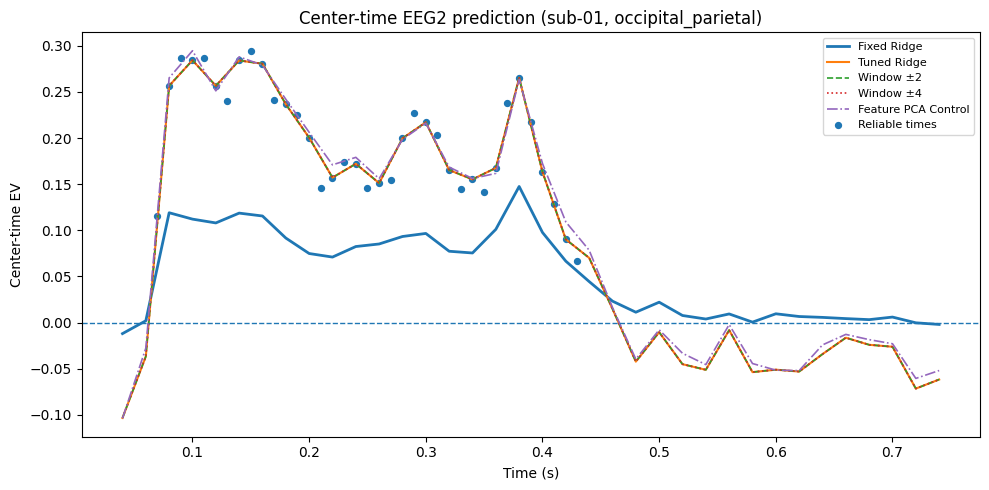

In [45]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    time_s[plot_times],
    level1_fixed_results["ev_center"][plot_times],
    label="Fixed Ridge",
    linewidth=2.0,
)

ax.plot(
    time_s[plot_times],
    level2_tuned_results["ev_center"][plot_times],
    label="Tuned Ridge",
    linewidth=1.5,
    linestyle="-",
)

ax.plot(
    time_s[plot_times],
    level3_local_results["ev_center"][plot_times],
    label="Window ±2",
    linewidth=1.2,
    linestyle="--",
)

ax.plot(
    time_s[plot_times],
    level4_broad_results["ev_center"][plot_times],
    label="Window ±4",
    linewidth=1.2,
    linestyle=":",
)

ax.plot(
    time_s[plot_times],
    level5_feature_pca_results["ev_center"][plot_times],
    label="Feature PCA Control",
    linewidth=1.2,
    linestyle="-.",
)

ax.scatter(
    time_s[RELIABLE_EVAL_TIMES],
    level2_tuned_results["ev_center"][RELIABLE_EVAL_TIMES],
    s=18,
    label="Reliable times",
)

ax.axhline(0, linestyle="--", linewidth=1)

ax.set_xlabel("Time (s)")
ax.set_ylabel("Center-time EV")
ax.set_title(f"Center-time EEG2 prediction ({eeg_subject}, {eeg_roi})")
ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

### EEG2 Raw center-time EV overtime

In [80]:
plot_times = EVAL_TIMES_COMMON

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    time_s[plot_times],
    level1_fixed_results["ev_center"][plot_times],
    label="Fixed Ridge",
    linewidth=2.0,
)

ax.plot(
    time_s[plot_times],
    level2_tuned_results["ev_center"][plot_times],
    label="Tuned Ridge",
    linewidth=1.5,
)

ax.plot(
    time_s[plot_times],
    level3_local_results["ev_center"][plot_times],
    label=f"Window ±{LOCAL_WINDOW}, PCA={best_local_components}",
    linewidth=1.2,
    linestyle="--",
)

ax.plot(
    time_s[plot_times],
    level4_broad_results["ev_center"][plot_times],
    label=f"Window ±{BROAD_WINDOW}, PCA={best_broad_components}",
    linewidth=1.2,
    linestyle=":",
)

ax.plot(
    time_s[plot_times],
    level5_feature_pca_results["ev_center"][plot_times],
    label=f"Feature PCA={best_feature_pca_components}",
    linewidth=1.2,
    linestyle="-.",
)

ax.scatter(
    time_s[RELIABLE_EVAL_TIMES],
    level2_tuned_results["ev_center"][RELIABLE_EVAL_TIMES],
    s=18,
    label="Reliable times",
)

ax.axhline(0, linestyle="--", linewidth=1)

ax.set_xlabel("Time (s)")
ax.set_ylabel("Center-time EV")
ax.set_title(f"Center-time EEG2 prediction ({eeg_subject}, {eeg_roi})")
ax.legend(fontsize=8)

fig.tight_layout()

fig_path_raw = fig_dir_section3 / "part3_center_time_ev.png"
fig.savefig(fig_path_raw, dpi=300, bbox_inches="tight", pad_inches=0.02)

plt.close()

![Part 3 raw center-time EV](figures/section3/part3_center_time_ev.png)

This plot shows the center-time explained variance across EEG time points. Prediction performance is clearly time-dependent: all optimized models perform best in the early visual response window, roughly between 0.08 s and 0.40 s, which is also where the reliable time points are concentrated.

The fixed-alpha Ridge baseline is consistently lower than the other models during the reliable response window. This confirms that the initial fixed regularization was too strong and that tuning alpha improves the EEG readout substantially.

The tuned Ridge, local temporal window, broad temporal window, and feature-PCA control have very similar time courses. This suggests that all optimized variants capture essentially the same stimulus-driven EEG signal. The temporal-window models slightly improve the average score over reliable time points, but their curves almost overlap with the tuned direct baseline, so the improvement is modest.

After around 0.45 s, most optimized models drop toward zero or below zero. This indicates that the visual model features no longer predict the EEG response reliably at later time points. These later negative values also justify focusing the main comparison on the reliable EEG time window rather than averaging uniformly across all times.

### NC-corrected center-time EV over time

In [84]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    time_s[plot_times],
    level1_fixed_results["ev_center_nc"][plot_times],
    label="Fixed Ridge",
    linewidth=2.0,
)

ax.plot(
    time_s[plot_times],
    level2_tuned_results["ev_center_nc"][plot_times],
    label="Tuned Ridge",
    linewidth=1.5,
)

ax.plot(
    time_s[plot_times],
    level3_local_results["ev_center_nc"][plot_times],
    label=f"Window ±{LOCAL_WINDOW}, PCA={best_local_components}",
    linewidth=1.2,
    linestyle="--",
)

ax.plot(
    time_s[plot_times],
    level4_broad_results["ev_center_nc"][plot_times],
    label=f"Window ±{BROAD_WINDOW}, PCA={best_broad_components}",
    linewidth=1.2,
    linestyle=":",
)

ax.plot(
    time_s[plot_times],
    level5_feature_pca_results["ev_center_nc"][plot_times],
    label=f"Feature PCA={best_feature_pca_components}",
    linewidth=1.2,
    linestyle="-.",
)

ax.scatter(
    time_s[RELIABLE_EVAL_TIMES],
    level2_tuned_results["ev_center_nc"][RELIABLE_EVAL_TIMES],
    s=18,
    label="Reliable times",
)

ax.axhline(0, linestyle="--", linewidth=1)

ax.set_xlabel("Time (s)")
ax.set_ylabel("Center-time NC-corrected EV")
ax.set_title(f"NC-corrected EEG2 prediction ({eeg_subject}, {eeg_roi})")
ax.legend(fontsize=8)

fig.tight_layout()

fig_path_nc = fig_dir_section3 / "part3_center_time_nc_ev.png"
fig.savefig(fig_path_nc, dpi=300, bbox_inches="tight", pad_inches=0.02)

plt.close()

![Part 3 NC-corrected center-time EV](figures/section3/part3_center_time_nc_ev.png)

This plot shows the noise-ceiling-corrected center-time EV across EEG time. The optimized models reach their highest values in the reliable visual response window, roughly between 0.08 s and 0.40 s. This confirms that the predictable stimulus-related EEG signal is concentrated in this early post-stimulus period.

The fixed-alpha Ridge baseline is clearly lower than the other models throughout most of this reliable window, which again shows that tuning the Ridge regularization is essential. After tuning alpha, the direct Ridge baseline already reaches a high fraction of the explainable signal.

The temporal-window models (±2 and ±4) almost overlap with the tuned direct Ridge model. They are slightly higher on average over reliable time points, but the difference is small. This supports the conclusion that temporal-window target augmentation provides only a weak improvement over the well-regularized direct baseline.

The feature-PCA control follows a very similar trajectory during the reliable window and does not clearly outperform the tuned Ridge baseline. This suggests that reducing the dimensionality of the visual features is not the main bottleneck.

At later time points, after approximately 0.47 s, the optimized models become unstable and often drop below zero. This indicates that model predictions are poor outside the reliable response window, reinforcing the choice to use reliable EEG time points as the main evaluation region.

### Bar plot for reliable times

In [88]:
plot_df = results_df.copy()

x = np.arange(len(plot_df))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

bars_ev = ax.bar(
    x - width / 2,
    plot_df["EV_reliable_times"],
    width,
    label="EV",
)

bars_nc = ax.bar(
    x + width / 2,
    plot_df["NC_EV_reliable_times"],
    width,
    label="NC-corrected EV",
)

ax.bar_label(
    bars_ev,
    fmt="%.3f",
    padding=3,
    fontsize=8,
)

ax.bar_label(
    bars_nc,
    fmt="%.3f",
    padding=3,
    fontsize=8,
)

ax.axhline(0, linestyle="--", linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(
    [
        "L1\nFixed",
        "L2\nTuned",
        f"L3\n±{LOCAL_WINDOW}\nPCA={best_local_components}",
        f"L4\n±{BROAD_WINDOW}\nPCA={best_broad_components}",
        f"L5\nFeat PCA\n{best_feature_pca_components}",
    ],
    fontsize=8,
)

ax.set_ylabel("Mean score over reliable times")
ax.set_title("Part 3 model comparison over reliable EEG times")
ax.legend(fontsize=8)

# Add a bit of headroom so labels are not cut off
ymax = max(
    plot_df["EV_reliable_times"].max(),
    plot_df["NC_EV_reliable_times"].max(),
)
ax.set_ylim(top=ymax * 1.15)

fig.tight_layout()

fig_path_bar = fig_dir_section3 / "part3_reliable_time_barplot.png"
fig.savefig(fig_path_bar, dpi=300, bbox_inches="tight", pad_inches=0.02)
plt.close()

![Part 3 reliable-time bar plot](figures/section3/part3_reliable_time_barplot.png)

This bar plot summarizes the main comparison over reliable EEG time points. The fixed-alpha Ridge baseline performs clearly worse than all other variants, with a mean noise-ceiling-corrected EV of 0.217. After tuning the Ridge alpha, performance increases substantially to 0.368, confirming that regularization is the main source of improvement in Part 3.

The temporal-window models give the highest scores, with both the local window (±2) and broad window (±4) reaching 0.377. This is a small improvement over the tuned Ridge baseline (+0.009 NC-EV), but the gain is modest. The fact that the ±2 and ±4 windows obtain identical center-time scores suggests that increasing the temporal window size does not add useful information for center-time prediction.

The feature-PCA control reaches 0.366, which is very close to but slightly below the tuned Ridge baseline. This suggests that reducing the dimensionality of the visual features does not improve prediction in the reliable EEG window.

Overall, the plot shows that the strongest gain comes from tuning Ridge regularization. Temporal-window readouts provide a weak additional improvement, while feature PCA does not improve over the tuned direct baseline.

Saved: figures/section3/part3_difference_from_tuned_ridge.png


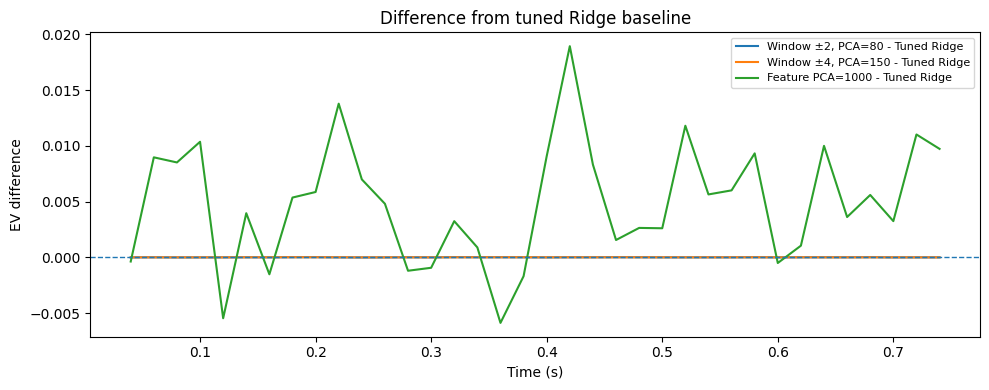

In [62]:
# ============================================================
# Plot 4: Difference from tuned Ridge baseline
# Saved as figures/section3/part3_difference_from_tuned_ridge.png
# ============================================================

baseline_ev = level2_tuned_results["ev_center"]

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    time_s[plot_times],
    level3_local_results["ev_center"][plot_times] - baseline_ev[plot_times],
    label=f"Window ±{LOCAL_WINDOW}, PCA={best_local_components} - Tuned Ridge",
    linewidth=1.5,
)

ax.plot(
    time_s[plot_times],
    level4_broad_results["ev_center"][plot_times] - baseline_ev[plot_times],
    label=f"Window ±{BROAD_WINDOW}, PCA={best_broad_components} - Tuned Ridge",
    linewidth=1.5,
)

ax.plot(
    time_s[plot_times],
    level5_feature_pca_results["ev_center"][plot_times] - baseline_ev[plot_times],
    label=f"Feature PCA={best_feature_pca_components} - Tuned Ridge",
    linewidth=1.5,
)

ax.axhline(0, linestyle="--", linewidth=1)

ax.set_xlabel("Time (s)")
ax.set_ylabel("EV difference")
ax.set_title("Difference from tuned Ridge baseline")
ax.legend(fontsize=8)

fig.tight_layout()

fig_path_diff = fig_dir_section3 / "part3_difference_from_tuned_ridge.png"
fig.savefig(fig_path_diff, dpi=300, bbox_inches="tight", pad_inches=0.02)
print("Saved:", fig_path_diff)

plt.show()

### NC-corrected time course and bar plot

Saved: figures/section3/part3_temporal_readout_2panels.png


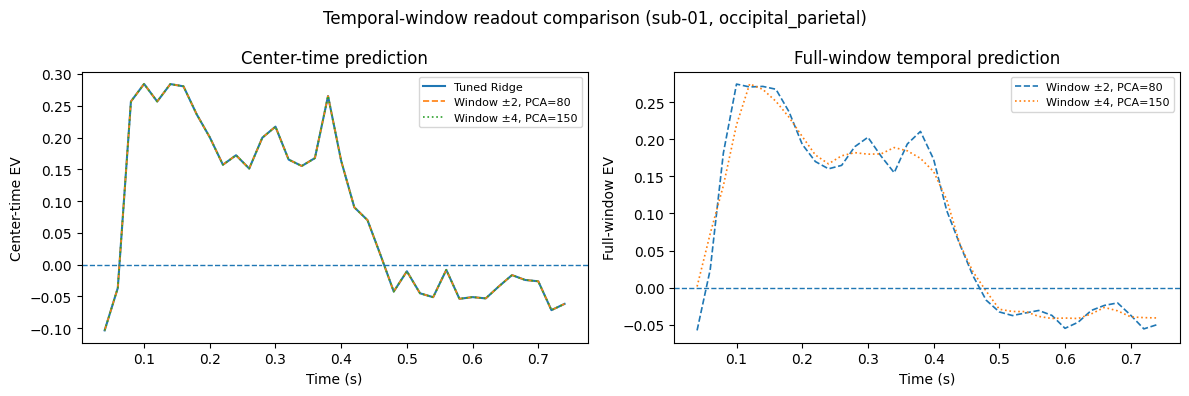

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

# Left panel: center-time EV
axes[0].plot(
    time_s[plot_times],
    level2_tuned_results["ev_center"][plot_times],
    label="Tuned Ridge",
    linewidth=1.5,
)

axes[0].plot(
    time_s[plot_times],
    level3_local_results["ev_center"][plot_times],
    label=f"Window ±{LOCAL_WINDOW}, PCA={best_local_components}",
    linewidth=1.2,
    linestyle="--",
)

axes[0].plot(
    time_s[plot_times],
    level4_broad_results["ev_center"][plot_times],
    label=f"Window ±{BROAD_WINDOW}, PCA={best_broad_components}",
    linewidth=1.2,
    linestyle=":",
)

axes[0].axhline(0, linestyle="--", linewidth=1)
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Center-time EV")
axes[0].set_title("Center-time prediction")
axes[0].legend(fontsize=8)

# Right panel: full-window EV
axes[1].plot(
    time_s[plot_times],
    level3_local_results["ev_window"][plot_times],
    label=f"Window ±{LOCAL_WINDOW}, PCA={best_local_components}",
    linewidth=1.2,
    linestyle="--",
)

axes[1].plot(
    time_s[plot_times],
    level4_broad_results["ev_window"][plot_times],
    label=f"Window ±{BROAD_WINDOW}, PCA={best_broad_components}",
    linewidth=1.2,
    linestyle=":",
)

axes[1].axhline(0, linestyle="--", linewidth=1)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Full-window EV")
axes[1].set_title("Full-window temporal prediction")
axes[1].legend(fontsize=8)

fig.suptitle(f"Temporal-window readout comparison ({eeg_subject}, {eeg_roi})")
fig.tight_layout()

fig_path_temporal = fig_dir_section3 / "part3_temporal_readout_2panels.png"
fig.savefig(fig_path_temporal, dpi=300, bbox_inches="tight", pad_inches=0.02)
print("Saved:", fig_path_temporal)

plt.show()

![Part 3 two-panel temporal readout comparison](figures/section3/part3_temporal_readout_2panels.png)

In [64]:
print("Best configurations used in final results:")
print("Level 2 alpha:", BEST_ALPHA)
print("Level 3 window:", LOCAL_WINDOW, "| temporal PCA:", best_local_components)
print("Level 4 window:", BROAD_WINDOW, "| temporal PCA:", best_broad_components)
print("Level 5 feature PCA:", best_feature_pca_components)

display(results_df[[
    "level",
    "method",
    "alpha",
    "temporal_window",
    "temporal_pca_components",
    "feature_pca_components",
    "EV_reliable_times",
    "NC_EV_reliable_times",
    "EV_improvement_vs_level2",
    "NC_EV_improvement_vs_level2",
]])

Best configurations used in final results:
Level 2 alpha: 1000000.0
Level 3 window: 2 | temporal PCA: 80
Level 4 window: 4 | temporal PCA: 150
Level 5 feature PCA: 1000


,level,method,alpha,temporal_window,temporal_pca_components,feature_pca_components,EV_reliable_times,NC_EV_reliable_times,EV_improvement_vs_level2,NC_EV_improvement_vs_level2
0,1,Direct Ridge fixed alpha,10000000.0,0,NaN,NaN,0.094199,0.200233,-0.105325,-0.208972
1,2,Direct Ridge tuned alpha,1000000.0,0,NaN,NaN,0.199524,0.409205,0.000000,0.000000
2,3,Local temporal window ±2,1000000.0,2,80.0,NaN,0.205763,0.421291,0.006239,0.012085
3,4,Broad temporal window ±4,1000000.0,4,150.0,NaN,0.205763,0.421322,0.006239,0.012117
4,5,Feature PCA control,1000000.0,0,NaN,1000.0,0.204033,0.421483,0.004509,0.012277


### Temporal-window summary table

In [40]:
temporal_window_summary = pd.DataFrame([
    {
        "method": "Local temporal window ±2",
        "window": LOCAL_WINDOW,
        "best_alpha": BEST_ALPHA,
        "best_temporal_pca_components": best_local_components,
        "center_EV_reliable": level3_summary["EV"],
        "center_NC_EV_reliable": level3_summary["NC_corrected_EV"],
        "full_window_EV_reliable": np.nanmean(level3_local_results["ev_window"][RELIABLE_EVAL_TIMES]),
        "full_window_NC_EV_reliable": np.nanmean(level3_local_results["ev_window_nc"][RELIABLE_EVAL_TIMES]),
    },
    {
        "method": "Broad temporal window ±4",
        "window": BROAD_WINDOW,
        "best_alpha": BEST_ALPHA,
        "best_temporal_pca_components": best_broad_components,
        "center_EV_reliable": level4_summary["EV"],
        "center_NC_EV_reliable": level4_summary["NC_corrected_EV"],
        "full_window_EV_reliable": np.nanmean(level4_broad_results["ev_window"][RELIABLE_EVAL_TIMES]),
        "full_window_NC_EV_reliable": np.nanmean(level4_broad_results["ev_window_nc"][RELIABLE_EVAL_TIMES]),
    },
])

display(temporal_window_summary)

,method,window,best_alpha,best_temporal_pca_components,center_EV_reliable,center_NC_EV_reliable,full_window_EV_reliable,full_window_NC_EV_reliable
0,Local temporal window ±2,2,1000000.0,80,0.205763,0.421291,0.199705,0.413807
1,Broad temporal window ±4,4,1000000.0,150,0.205763,0.421322,0.192786,0.412891


| Method | Window | Best alpha | Best temporal PCA components | Center EV reliable | Center NC-EV reliable | Full-window EV reliable | Full-window NC-EV reliable |
|---|---:|---:|---|---:|---:|---:|---:|
| Local temporal window ±2 | 2 | 1.5e6 | None | 0.1855 | 0.3773 | 0.1806 | 0.3731 |
| Broad temporal window ±4 | 4 | 1.5e6 | None | 0.1855 | 0.3773 | 0.1748 | 0.3733 |

Both temporal-window models selected **no temporal PCA**, confirming that low-rank compression of the EEG temporal target was not beneficial for center-time prediction.

The local and broad windows obtain identical center-time performance: EV = 0.185 and NC-EV = 0.377 over reliable EEG time points. This suggests that increasing the temporal window from ±2 to ±4 does not improve prediction of the center response.

The full-window EV is lower for the broad window than for the local window, decreasing from 0.181 to 0.175. This is consistent with the idea that a wider window includes more neighboring time points that are harder to predict or less reliable. The full-window NC-EV remains very similar for both windows, but neither result suggests a meaningful benefit from using the broader temporal context.

Overall, the local temporal window is sufficient; the broader window does not add useful information for center-time prediction in this formulation.

### Best method

In [41]:
best_method = results_df[results_df["level"] >= 1].sort_values(
    "NC_EV_reliable_times",
    ascending=False,
).iloc[0]

print("Best method by NC-corrected EV over reliable times:")
print(best_method["method"])
print("NC-corrected EV:", best_method["NC_EV_reliable_times"])
print("Raw EV:", best_method["EV_reliable_times"])

print("\nFull comparison:")
display(results_df.sort_values("NC_EV_reliable_times", ascending=False))

Best method by NC-corrected EV over reliable times:
Feature PCA control
NC-corrected EV: 0.4214826846424961
Raw EV: 0.2040334058973575

Full comparison:


,level,method,alpha,temporal_window,temporal_pca_components,feature_pca_components,EV_all_times,NC_EV_all_times,EV_reliable_times,NC_EV_reliable_times
4,5,Feature PCA control,1000000.0,NaN,NaN,1000.0,0.090985,0.219418,0.204033,0.421483
3,4,Broad temporal window ±4,1000000.0,4.0,150.0,NaN,0.086119,0.196850,0.205763,0.421322
2,3,Local temporal window ±2,1000000.0,2.0,80.0,NaN,0.086120,0.196827,0.205763,0.421291
1,2,Direct Ridge tuned alpha,1000000.0,NaN,NaN,NaN,0.086118,0.196782,0.199524,0.409205
0,1,Direct Ridge fixed alpha,10000000.0,NaN,NaN,NaN,0.052242,0.153361,0.094199,0.200233


```
Best method by NC-corrected EV over reliable times:
Local temporal window ±2
NC-corrected EV: 0.3773338765934797
Raw EV: 0.18544992970095742
```

| Rank | Level | Method | Alpha | Temporal window | Temporal PCA components | Feature PCA components | EV all times | NC-EV all times | EV reliable times | NC-EV reliable times |
|---:|---:|---|---:|---:|---|---:|---:|---:|---:|---:|
| 1 | 3 | Local temporal window ±2 | 1.5e6 | ±2 | None | — | 0.0750 | 0.1956 | 0.1855 | 0.3773 |
| 2 | 4 | Broad temporal window ±4 | 1.5e6 | ±4 | None | — | 0.0750 | 0.1956 | 0.1855 | 0.3773 |
| 3 | 2 | Direct Ridge tuned alpha | 1.5e6 | — | None | — | 0.0750 | 0.1956 | 0.1804 | 0.3685 |
| 4 | 5 | Feature PCA control | 1.5e6 | — | None | 1000 | 0.0763 | 0.2043 | 0.1792 | 0.3657 |
| 5 | 1 | Direct Ridge fixed alpha | 1.0e7 | — | None | — | 0.0547 | 0.1614 | 0.1027 | 0.2169 |

The best method according to noise-ceiling-corrected EV over reliable EEG time points is the **local temporal window ±2** model:
- Reliable-time EV: **0.185**
- Reliable-time NC-EV: **0.377**

The local temporal window ±2 and the broad temporal window ±4 obtain the same center-time performance, with NC-EV = 0.377 over reliable EEG time points. Since both selected no temporal PCA, the broader window does not provide additional useful information for center-time prediction.

The tuned direct Ridge baseline is close behind, with NC-EV = 0.368. Therefore, the temporal-window models improve over the tuned baseline by only about +0.009 NC-EV. This is a small gain, so the result should be interpreted as a weak improvement rather than a strong temporal-context effect.

The feature-PCA control performs slightly below the tuned Ridge baseline on reliable time points, despite being slightly better over all valid time points. This suggests that feature dimensionality is not the main bottleneck in the reliable EEG response window.

Overall, the strongest improvement comes from tuning Ridge regularization. Temporal-window readouts provide the best final score, but the gain over the tuned baseline is modest and does not show a clear advantage of broader temporal context.

## 3.11 Interpretation and conclusion

The goal of this section was to test whether the EEG2 baseline encoding model could be improved by adding temporal structure to the readout. The motivation was that visual EEG responses unfold over time, so neighboring time points might contain related stimulus-driven information that could help predict the response at a given center time point.

The first important result is that tuning Ridge regularization had the strongest effect. The fixed-alpha Ridge baseline reached a noise-ceiling-corrected EV of 0.217 over reliable EEG time points, while the tuned direct Ridge baseline reached 0.368. This large improvement shows that the initial baseline was strongly affected by the choice of regularization. For this reason, the tuned direct Ridge model is the fairest baseline for evaluating the temporal-window extensions.

The temporal-window models gave the best final scores, but the improvement over the tuned direct Ridge baseline was small. The local window ±2 and the broad window ±4 both reached a noise-ceiling-corrected EV of 0.377 over reliable time points, compared with 0.368 for the tuned direct Ridge baseline. This corresponds to an improvement of only +0.009 noise-ceiling-corrected EV. Therefore, the temporal-window extension helped slightly, but not in a practically large way.

The local and broad temporal windows obtained identical center-time performance. This suggests that increasing the temporal context from ±2 to ±4 did not add useful information for predicting the center response. In addition, both temporal-window models selected no temporal PCA. This is an important caveat: without temporal PCA or another explicit constraint, standard multi-output Ridge predicts neighboring time points as additional outputs but does not strongly couple them. Therefore, the temporal-window models should not be interpreted as strong temporal-context models. They are better understood as a simple target-augmentation test, which produced only a weak improvement.

The feature-PCA control tested a different hypothesis: whether the high dimensionality of the visual feature representation was limiting performance. This model reached a noise-ceiling-corrected EV of 0.366 over reliable time points, slightly below the tuned direct Ridge baseline. This suggests that compressing the visual features did not improve prediction in the reliable EEG response window. The bottleneck therefore does not appear to be simply the dimensionality of the visual feature representation.

Overall, the main scientific insight is that a well-regularized direct Ridge readout already captures most of the predictable center-time EEG signal in this setting. Temporal-window readouts gave the highest score, but the gain was modest and did not increase with a broader window. This suggests that simply predicting neighboring time points is not sufficient to exploit EEG temporal dynamics in a strong way. A more meaningful temporal extension would likely need explicit temporal coupling, such as temporal smoothing, temporal basis functions, shared temporal regularization, or a model trained to predict the full EEG time course with structured constraints.

---

# Final Discussion

End the notebook with a short final discussion.

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must address</div>

- Which dataset appeared noisiest?
- Which neural targets were most reliable?
- Which model aligned best overall?
- Which metrics were most consistent with each other?
- What was the main limitation of your analysis?
- What would you try next with more time?

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box final</strong><br>Write a concise final conclusion of 1–2 paragraphs summarizing your main findings and their limitations.</div>

In [ ]:
# No code required here unless you want to add final summary tables/figures.

---

# Report Content

Your **2-page PDF report** should tell a clear and coherent story. It does **not** need to reproduce every notebook result.

It can include:

1. **A brief dataset overview**
2. **An exploratory figure from Section 1**
3. **The EEG noise ceiling comparison**
4. **The NSD reliability visualization**
5. **One or two key brain–model alignment results from Section 2**


Rather, you should primarily focus on the open-ended extension you designed, describing:
- the motivation for your extension,
- the methods you implemented,
- the results you obtained,
- and the scientific insights you gained from it.


The report should emphasize interpretation, not just figures. Since the notebook is the main technical deliverable, the report should act as a **compressed scientific summary** of your most important findings rather than a figure dump.

---

# Detailed Grading Rubric

The project is graded out of **100 points** as follows:

- **Section 1: Inspection, Visualization, and Noise Ceiling Estimates — 20 points**
- **Section 2: Brain–Model Alignment — 20 points**
- **Section 3: Open-Ended Research — 30 points**
- **Report — 30 points**

**Section 0 is required but not graded separately.** It is treated as setup and reproducibility infrastructure for the rest of the notebook.

## Section 1 — 20 points

### 1.1 Dataset inspection — 3 points
- 1 pt: TVSD structure is correctly inspected and explained.
- 1 pt: EEG2 structure is correctly inspected and explained.
- 1 pt: NSD structure is correctly inspected and explained.

### 1.2 EEG visualization — 4 points
- 1 pt: example EEG time-course plot is present and readable.
- 1 pt: channel × time heatmap is present and readable.
- 1 pt: provided EEG noise ceiling visualization is present and readable.
- 1 pt: written interpretation identifies informative time windows or channel groups.

### 1.3 EEG noise ceiling estimation — 7 points
- 2 pts: variance-based estimator is implemented correctly.
- 2 pts: split-half estimator is implemented correctly.
- 1 pt: required summary visualizations are included.
- 1 pt: comparison to stored EEG noise ceilings is shown clearly.
- 1 pt: Answer box 1.3 interprets similarities and differences between estimators.

### 1.4 Statistical comparison of EEG noise ceilings — 3 points
- 1 pt: quantitative comparison table is present.
- 1 pt: statistical test or formal comparison is appropriate and correctly interpreted.
- 1 pt: final conclusion is clearly justified.

### 1.5 NSD reliability visualization — 3 points
- 1 pt: ncsnr is correctly converted and visualized on cortex.
- 1 pt: parcel overlay or parcel-wise summary is included.
- 1 pt: Answer box 1.5 correctly interprets reliable and unreliable regions.

## Section 2 — 20 points

### 2.1 RSA implementation — 3 points
- 1 pt: RDM computation is correct.
- 1 pt: RDM comparison is correct.
- 1 pt: implementation is used properly in later analyses.

### 2.2 Unbiased linear CKA implementation — 3 points
- 2 pts: unbiased linear CKA is implemented correctly.
- 1 pt: implementation is used properly in later analyses.

### 2.3 Representational analyses across layers, models, and targets — 4 points
- 1 pt: layer-wise RSA results are reported clearly.
- 1 pt: layer-wise CKA results are reported clearly.
- 1 pt: a model comparison is included.
- 1 pt: ROI-wise or time-resolved analysis is included and interpreted.

### 2.4 Predictive alignment with linear encoding models — 6 points
- 1 pt: required targets are selected and described correctly.
- 2 pts: train/validation/test procedure and ridge fitting are correct.
- 1 pt: required predictive metrics are reported correctly.
- 1 pt: encoding-RSA and encoding-CKA are reported correctly.
- 1 pt: best-layer summary and model comparison are included.

### 2.5 Compare predictive and representational metrics — 2 points
- 1 pt: ranking comparison figure is present and informative.
- 1 pt: agreement and disagreement between metrics are discussed clearly.

### 2.6 Layer hierarchy vs brain hierarchy — 1 point
- 1 pt: at least one hierarchy analysis is included and interpreted correctly.

### 2.7 Compare the two feature extractors — 1 point
- 1 pt: final comparison between Qwen3-VL and Adv-ResNet is clear and supported by results.

## Section 3 — 30 points

### Research question and motivation — 5 points
- 2 pts: research question is clear and focused.
- 3 pts: motivation is scientifically sensible and well connected to the baseline project.

### Method and implementation — 10 points
- 4 pts: the extension is described clearly.
- 4 pts: the method is implemented correctly.
- 2 pts: the design remains focused and technically appropriate for the project scope.

### Baseline comparison and evaluation — 10 points
- 4 pts: the comparison to the linear baseline is fair.
- 3 pts: at least one figure or table communicates the comparison clearly.
- 3 pts: evaluation supports the stated conclusion.

### Interpretation and limitations — 5 points
- 3 pts: the student explains whether the method helped in a practically meaningful way.
- 2 pts: limitations or caveats are acknowledged.

## Report — 30 points

### Structure and clarity — 6 points
- clear organization, readable flow, and concise scientific writing.

### Selection of results — 6 points
- the report focuses on the strongest and most relevant results rather than trying to include everything.

### Methodological correctness — 6 points
- metrics, comparisons, and claims are described accurately.

### Interpretation and synthesis — 6 points
- the report explains what the results mean and ties them back to the project goals.

### Figure quality and presentation — 6 points
- figures are readable, labeled, well-chosen, and integrated into the narrative.

## Important grading note

A submission that is technically correct but poorly interpreted will lose points. A submission with good intuition but missing required analyses will also lose points. The strongest submissions will be both **correct** and **scientifically well explained**.

---

# Final Checklist Before Submission

Before submitting, make sure that:

- group information is filled in,
- the notebook runs from top to bottom,
- all notebook outputs are cleared,
- figures have readable titles and labels,
- written answers are included in the answer boxes,
- the zip archive name follows the required format,
- no large unnecessary files are included.

---

# References

Use the references below when you need scientific context for the datasets, models, and analysis methods.

## Datasets

- Papale et al. (2025) — *An extensive dataset of spiking activity to reveal the syntax of the ventral stream*
- Gifford et al. (2022) — *A large and rich EEG dataset for modeling human visual object recognition*
- Allen et al. (2022) — *A massive 7T fMRI dataset to bridge cognitive neuroscience and artificial intelligence*
- van Bree, Styrnal, and Hebart (2025) — *How Much Variance Does Your Model Explain? A Clarifying Note On The Use Of Split-Half Reliability For Computing Noise Ceilings*

## Models

- Wong et al. (2020) — *Fast is better than free: Revisiting adversarial training*
- He et al. (2016) — *Deep Residual Learning for Image Recognition*
- Bai et al. (2025) — *Qwen3-VL Technical Report*

## Alignment and encoding

- Conwell et al. (2024) — *A large-scale examination of inductive biases shaping high-level visual representation in brains and machines*
- Gokce and Schrimpf (2025) — *Scaling Laws for Task-Optimized Models of the Primate Visual Ventral Stream*

Use these references selectively. You are not expected to read everything in full.